# AgroHomeopathy Data Analysis and Visualization

## Setup and Configuration

----- To do ------

Tjek Parallel interventions applied ift hvis crop er N/A eller sat som en pest

If Controls only har "specifially..", then apply "unsuccused or N/A"

Extract "flagged as unclear statistics" and analysis of arguments

Effect size discussion

Outcome grouped list - update when Leo provides the new groupings ?? fully integrated yet??

Tables:
- Countries
- Hom intervention
- Production potency + material + controls
- All crops with list of remedies that ever were significant
- Stratify Growth infrastructure // Setting in which treated ... somehow

POSTPONED "Main Biological System" can be plotted with subplots showing the commonality of remedies/potency levels in each biological system

Make colorblind and print safe


----- After final data is available ----

Farmland + Blinded - subgroup analysis, is it overrepresented as "not mentioned"

Correct medicinal/aromatic --> medicinal plants, Legumes & Pulses —> Legumes

Production of potency graph, needs revamp.








In [306]:

import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import seaborn as sns
import scipy
from scipy.cluster.hierarchy import linkage


import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

## Utility Functions

In [307]:
# ============================================
# GLOBAL COLOR SCHEME CONFIGURATION
# ============================================

# Qualitative colors (for categorical data: pie charts, bar charts)
QUALITATIVE_COLORS = [
'#7CA8D4', '#F6CD66', '#DC66AE', '#B1A1DC', '#EEA67A',
 '#A6D87E', '#66D1CB', '#E07A82', '#9D9EA0'
]

# Original 12-color agronomy-themed palette
QUALITATIVE_COLORS_AGRO = [
    '#6CB86E', '#87D180', '#EF8A0C', '#FCC66D',
    '#3CA8BC', '#98D9E4', '#94A323', '#C3CE3D',
    '#A08400', '#F7D42A', '#26897E', '#8DBFA8'
]

QUALITATIVE_COLORS_AGRO_BROWN = [
    '#6CB86E', '#87D180', '#EF8A0C', '#6F5B34',
    '#3CA8BC', '#98D9E4', '#94A323', '#C3CE3D',
    '#A08400', '#F7D42A', '#26897E', '#8DBFA8'
]

# ============================================
# GLOBAL FONT SIZE CONFIGURATION
# ============================================
# One named constant per semantic role, all pointing at the same scale for
# now (validated by hand on the MIS-by-year bar chart). Kept as separate
# symbols so any one role can be dialed back independently later without
# touching the others or leaving old-size code lying around.
TITLE_FS = 18          # ax.set_title() / plotly figure titles
AXIS_LABEL_FS = 16     # ax.set_xlabel() / ax.set_ylabel()
TICK_FS = 14           # tick labels (x/y)
LEGEND_FS = 14         # ax.legend()
LEGEND_TITLE_FS = 14   # ax.legend(title=...)

# Dense/cramped elements: same scale as above for now, but each is its own
# constant so a specific chart type can be tuned independently if it turns
# out too crowded at this size.
DATA_LABEL_FS = TICK_FS          # ax.text() bar-value / %-label annotations
HMAP_ANNOT_FS = TICK_FS          # heatmap in-cell annotation text
HMAP_TICK_FS = TICK_FS           # heatmap row/col tick labels
PLOTLY_TEXT_FS = AXIS_LABEL_FS   # pie/treemap on-chart text
PLOTLY_TITLE_FS = TITLE_FS       # plotly figure titles

# Sequential colors (for heatmaps, gradients)
SEQUENTIAL_COLORS = [
    '#FFF3E0', '#FFE0B2', '#FFCC80', '#FFB74D',
    '#FFA726', '#FF9800', '#FB8C00', '#F57C00',
    '#EF6C00', '#E65100'
]

# ============================================
# PLOTLY CONFIGURATION
# ============================================
import plotly.io as pio

# Create custom Plotly template
pio.templates["custom"] = go.layout.Template(
    layout_colorway=QUALITATIVE_COLORS,
    layout_font=dict(size=PLOTLY_TEXT_FS),
    layout_title_font=dict(size=PLOTLY_TITLE_FS),
)

# Set as default template
pio.templates.default = "custom"

print("✓ Plotly configured with custom color scheme")

# ============================================
# MATPLOTLIB CONFIGURATION
# ============================================
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

# Set qualitative colors as default color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=QUALITATIVE_COLORS)

# Global text-size defaults, so any element without an explicit fontsize=
# override (bar charts with no per-element sizing, heatmap colorbars, etc.)
# still scales with the rest of the notebook.
plt.rcParams.update({
    'font.size': TICK_FS,
    'axes.titlesize': TITLE_FS,
    'axes.labelsize': AXIS_LABEL_FS,
    'xtick.labelsize': TICK_FS,
    'ytick.labelsize': TICK_FS,
    'legend.fontsize': LEGEND_FS,
    'legend.title_fontsize': LEGEND_TITLE_FS,
})

# Create custom sequential colormap for heatmaps (available as CUSTOM_SEQUENTIAL_CMAP)
CUSTOM_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list('custom_sequential', SEQUENTIAL_COLORS)

# Create custom qualitative colormap (available as CUSTOM_QUALITATIVE_CMAP)
CUSTOM_QUALITATIVE_CMAP = ListedColormap(QUALITATIVE_COLORS, name='custom_qualitative')


✓ Plotly configured with custom color scheme


### Label Formatting

In [308]:
# Title: Label Formatting Utility for Pie Charts
# Description: Helper function to insert HTML <br> line breaks into long labels to improve pie chart readability.
#              Offers three strategies: break at parentheses/commas, at midpoint between words, or by word count threshold.

def add_line_breaks_to_label(label, strategy='parentheses'):
    """
    Add <br> tags to long labels for better pie chart readability.
    
    Strategies:
    - 'parentheses': Break before opening parenthesis AND at commas
    - 'midpoint': Break at middle space
    - 'word_count': Break if more than 4 words (more aggressive)
    """
    if not isinstance(label, str):
        return label

    if strategy == 'parentheses':
        # Break before parenthesis
        if '(' in label:
            label = label.replace(' (', '<br>(')
        # Also break at commas inside parentheses if text is very long
        if len(label) > 35 and ',' in label:
            label = label.replace(', ', ',<br>')
        return label

    elif strategy == 'midpoint':
        words = label.split()
        if len(words) <= 2:  # More aggressive - break even short-ish labels
            return label
        mid = len(words) // 2
        return ' '.join(words[:mid]) + '<br>' + ' '.join(words[mid:])

    elif strategy == 'word_count':
        words = label.split()
        if len(words) > 4:  # Changed from 6 to 4 - more aggressive
            mid = len(words) // 2
            return ' '.join(words[:mid]) + '<br>' + ' '.join(words[mid:])
        return label

    return label


## Data Loading

In [309]:
# Data input

df_old = pd.read_excel('data_agrohom/150925_extraction_agrohom.xlsx')  # Not used anymore, kept for reference
df = pd.read_excel('data_agrohom/Leo all extractions.xlsx')
df_all = df.copy()  # preserve the full dataset for later filtering/use

### Layout Constants

In [310]:
# ── Horizontal bar chart layout constants ───────────────────────────────
# ROW_H and PAD are calibrated so the formula reproduces existing figsize
# values for 20-bar and 30-bar charts (10 and 14 inches respectively).
HBAR_ROW_H = 0.4    # figure-height inches per bar row
HBAR_PAD   = 2.0    # fixed padding for title + axis labels + margins
HBAR_W     = 12     # default figure width for horizontal bar charts
BAR_H      = 0.6    # barh() height in data units (gap = 0.4)

def hbar_figsize(n_bars, width=HBAR_W):
    """Return (width, height) figsize that keeps bar/font ratio constant."""
    return (width, n_bars * HBAR_ROW_H + HBAR_PAD)

# ── Heatmap layout constants ─────────────────────────────────────────────
HMAP_CELL     = 0.4   # inches per cell — adjust to taste
HMAP_H_PAD    = 4.0   # horizontal padding (colorbar + y-tick labels)
HMAP_V_PAD    = 2.5   # vertical padding (title + x-tick labels)
# HMAP_ANNOT_FS / HMAP_TICK_FS now defined in Cell 4 (Global Font Size
# Configuration) alongside the rest of the notebook's font-size constants.

def hmap_figsize(n_rows, n_cols):
    """Return figsize that gives each cell HMAP_CELL × HMAP_CELL inches."""
    return (n_cols * HMAP_CELL + HMAP_H_PAD, n_rows * HMAP_CELL + HMAP_V_PAD)

def fix_hmap_cbar(fig, ax):
    """Resize colorbar height to match the heatmap axes, and force its tick
    labels to whole numbers (call after tight_layout)."""
    cbar_ax = fig.axes[-1]
    hm_pos = ax.get_position()
    cb_pos = cbar_ax.get_position()
    cbar_ax.set_position([cb_pos.x0, hm_pos.y0, cb_pos.width, hm_pos.height])
    cbar_ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))


### Column Overview

In [311]:
print(df_all.columns)

Index(['Done', 'Study # within same publication', 'Covidence #',
       'Study ID (as in covidence)', 'Title (covidence)', 'MIS score',
       'Reviewer Name', 'Title', 'First author SURNAME only',
       'Year of publication', 'DOI', 'Country of corresponding author',
       'Language of full article', 'How many studies in this publictaion?',
       'Replication study', 'If replication, write here which publication',
       'Blinded', 'Physical allocation', 'Setting in which treated',
       'Growth infrastructure', 'Soil characteristics, if given (free text)',
       'Crop type studied', 'Species, variety/cultivar ',
       'Main biological system studied', 'Parallel interventions applied',
       'Homeopathic intervention', 'Remedy/remedies ', 'Potency levels',
       'Reason for choosing remedy & hypothesis for application of the remedy',
       'Reason for choosing remedy level(s)', 'Production of potency',
       'Materials for potentization', 'Controls',
       'Control for inte

# Descriptive Statistics and Quality Metrics

## MIS Score Distribution

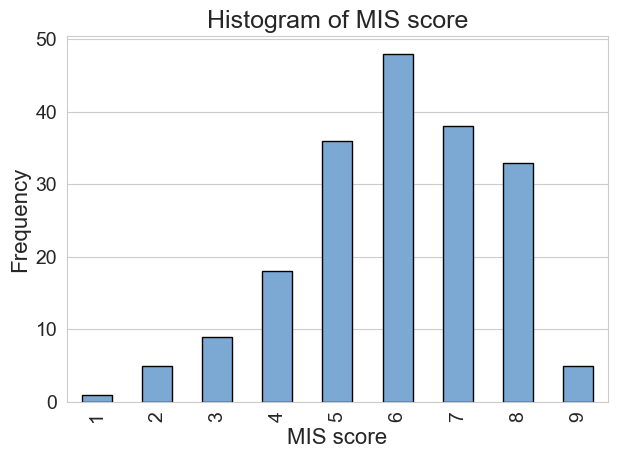

In [312]:
# Warn about empty MIS scores
for idx, row in df_all.iterrows():
    if pd.isna(row['MIS score']) or str(row['MIS score']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty MIS score")

# Compute distribution of MIS scores and sort by score
MIS_counts = df_all['MIS score'].dropna().value_counts().sort_index()

# Plot the bar chart of MIS score frequencies
MIS_his = MIS_counts.plot.bar(edgecolor='black')

# Label the axes and set the title
MIS_his.set_xlabel('MIS score')
MIS_his.set_ylabel('Frequency')
MIS_his.set_title('Histogram of MIS score')

# Save the histogram as a PNG file
MIS_his.xaxis.grid(False)
MIS_his.figure.tight_layout()
MIS_his.figure.savefig('mis_histogram.png', dpi=300, bbox_inches='tight')

## Publication Year Distribution

  RAWDATA CLEANUP NEEDED: Covidence #10694 has unparseable year: '1977 ?'


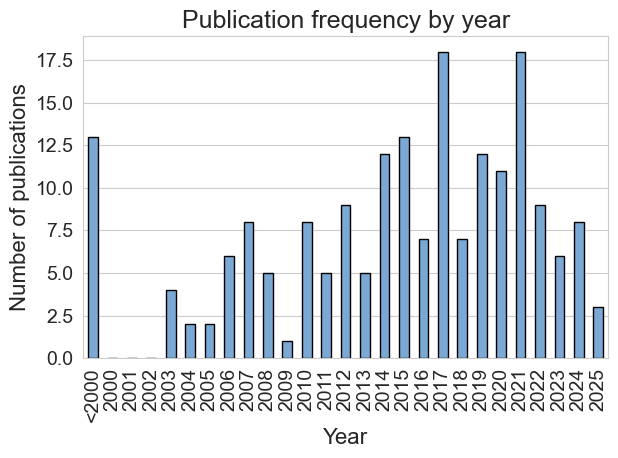

In [313]:
# Compute distribution of publication years with a "<2000" bin and ensure all years 2000-2025 are present
# Warn about missing or unparseable year values
for idx, row in df_all.iterrows():
    val = row['Year of publication']
    if pd.isna(val) or str(val).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty year field")
    elif pd.isna(pd.to_numeric(val, errors='coerce')):
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has unparseable year: '{val}'")

years_clean = pd.to_numeric(df_all['Year of publication'], errors='coerce').dropna().astype(int)
year_labels = years_clean.map(lambda y: '<2000' if y < 2000 else str(y))
year_counts = year_labels.value_counts()

# Ensure all desired categories are present (fill missing with 0)
categories = ['<2000'] + [str(y) for y in range(2000, 2026)]
year_counts = year_counts.reindex(categories, fill_value=0)

# Plot the bar chart of year frequencies
year_hist = year_counts.loc[categories].plot.bar(edgecolor='black')

# Label the axes and set the title
year_hist.set_xlabel('Year')
year_hist.set_ylabel('Number of publications')
year_hist.set_title('Publication frequency by year')

# Save the histogram as a PNG file
year_hist.xaxis.grid(False)
year_hist.figure.tight_layout()
year_hist.figure.savefig('year_histogram.png', dpi=300, bbox_inches='tight')


## Year × MIS Score

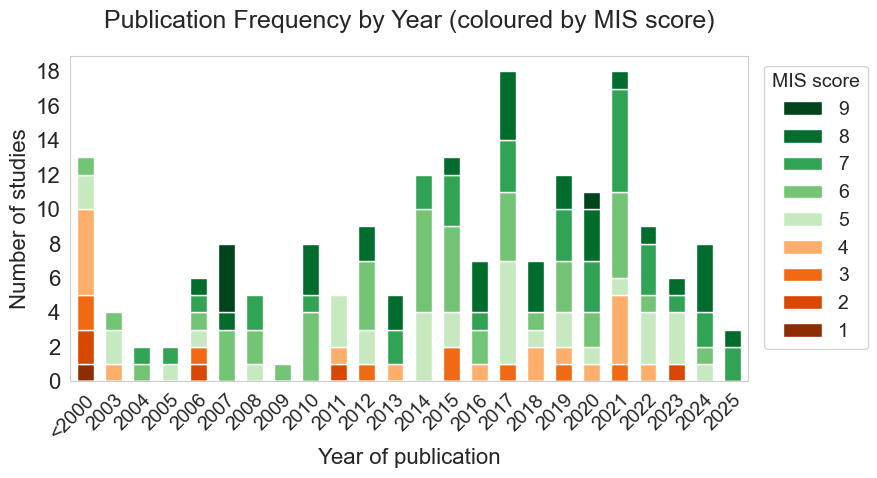

In [314]:
# Stacked bar chart: publication count by year, coloured by MIS score

# Data prep (same logic as area chart above)
# Warnings for missing/unparseable years printed in the year histogram cell above
years_mis_bar = pd.to_numeric(df_all['Year of publication'], errors='coerce').dropna().astype(int)
mis_year_labels_bar = years_mis_bar.map(lambda y: '<2000' if y < 2000 else str(y))
mis_scores_bar = pd.to_numeric(df_all.loc[years_mis_bar.index, 'MIS score'], errors='coerce')
mis_year_df_bar = pd.DataFrame({'Year': mis_year_labels_bar, 'MIS': mis_scores_bar}).dropna()
mis_year_df_bar['MIS'] = mis_year_df_bar['MIS'].astype(int)
crosstab_bar = pd.crosstab(mis_year_df_bar['Year'], mis_year_df_bar['MIS'])
for score in range(1, 10):
    if score not in crosstab_bar.columns:
        crosstab_bar[score] = 0
crosstab_bar = crosstab_bar[list(range(1, 10))]
categories_bar = ['<2000'] + [str(y) for y in range(2000, 2026)]
crosstab_bar = crosstab_bar.reindex([c for c in categories_bar if c in crosstab_bar.index], fill_value=0)

colors_mis_bar = [
    '#8c2d04', '#d94801', '#f16913', '#fdae6b',
    '#c7e9c0', '#74c476', '#31a354', '#006d2c', '#00441b',
]

fig_mis_bar, ax_mis_bar = plt.subplots(figsize=(9, 5))
crosstab_bar.plot(kind='bar', stacked=True, color=colors_mis_bar, ax=ax_mis_bar, width=0.6)

ax_mis_bar.tick_params(axis='y', labelsize=16)
ax_mis_bar.set_xlabel('Year of publication', fontsize=16)
ax_mis_bar.set_ylabel('Number of studies', fontsize=16)
ax_mis_bar.set_title('Publication Frequency by Year (coloured by MIS score)', fontsize=18, pad=20)
ax_mis_bar.set_xticklabels(
    crosstab_bar.index,
    rotation=45,
    ha='right',
    rotation_mode='anchor',
    fontsize=14
)
ax_mis_bar.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Reverse legend to match area chart (9 on top)
handles_bar, labels_bar = ax_mis_bar.get_legend_handles_labels()
ax_mis_bar.legend(
    handles_bar[::-1], labels_bar[::-1],
    title='MIS score',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=14
)

ax_mis_bar.xaxis.grid(False)
ax_mis_bar.yaxis.grid(False)
plt.tight_layout()
fig_mis_bar.savefig('mis_score_by_year_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Year × Country of Corresponding Author

  RAWDATA CLEANUP NEEDED: Covidence #4326 has empty country field
  RAWDATA CLEANUP NEEDED: Covidence #4397 has empty country field
  RAWDATA CLEANUP NEEDED: Covidence #4665 has empty country field


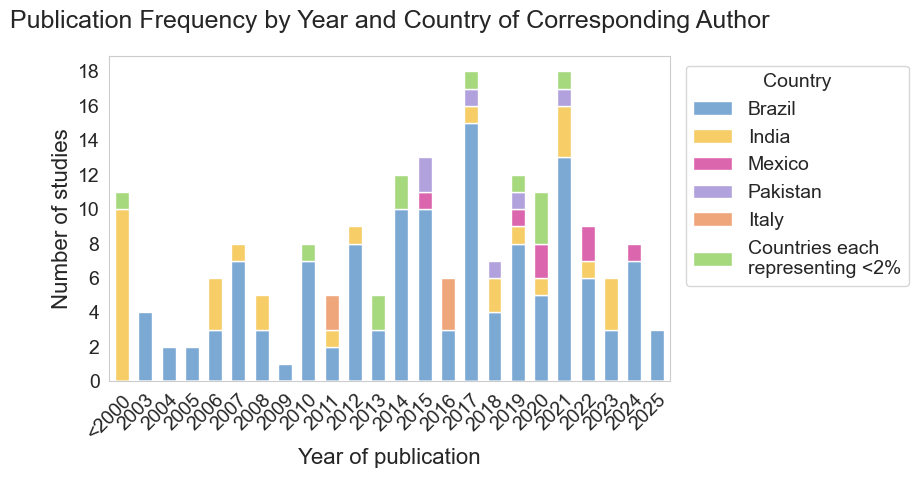

In [315]:
# Publication frequency by year, stacked by country of corresponding author

# Year binning — identical logic to year histogram
years_ctry = pd.to_numeric(df_all['Year of publication'], errors='coerce').dropna().astype(int)
year_labels_ctry = years_ctry.map(lambda y: '<2000' if y < 2000 else str(y))

# Country grouping — identical <2% logic to country pie chart
# TODO-RAWDATA: 'Parkistan' typo and 'Great Britain ' trailing space will be fixed in final data
for idx, row in df_all.iterrows():
    if pd.isna(row['Country of corresponding author']) or str(row['Country of corresponding author']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty country field")
country_series_yr = (
    df_all['Country of corresponding author']
    .dropna()
    .astype(str)
    .str.strip()
    .replace({'N/A': 'Unknown', 'Parkistan': 'Pakistan'})
)
init_counts_yr = country_series_yr.value_counts()
init_total_yr = int(init_counts_yr.sum())
to_other_yr = init_counts_yr[(init_counts_yr / init_total_yr) * 100 < 2.0].index
country_grouped_yr = country_series_yr.replace(
    {k: 'Countries each\nrepresenting <2%' for k in to_other_yr}
)

# Align year labels and country to rows that have both valid year AND valid country
valid_idx_yr = years_ctry.index.intersection(country_grouped_yr.index)
year_labels_ctry = year_labels_ctry.loc[valid_idx_yr]
country_yr_clean = country_grouped_yr.loc[valid_idx_yr]

# Crosstab: Year bin (rows) × Country (columns)
ctab_yr_country = pd.crosstab(year_labels_ctry, country_yr_clean)

# Order rows by year bin
categories_yr = ['<2000'] + [str(y) for y in range(2000, 2026)]
ctab_yr_country = ctab_yr_country.reindex(
    [c for c in categories_yr if c in ctab_yr_country.index], fill_value=0
)

# Order columns: major countries by frequency, <2% group last
major_countries_yr = [c for c in init_counts_yr.index if c not in to_other_yr]
col_order_yr = [c for c in major_countries_yr if c in ctab_yr_country.columns]
if 'Countries each\nrepresenting <2%' in ctab_yr_country.columns:
    col_order_yr.append('Countries each\nrepresenting <2%')
ctab_yr_country = ctab_yr_country[col_order_yr]

# Colors
colors_yr_country = QUALITATIVE_COLORS[:len(col_order_yr)]

fig_yr_ctry, ax_yr_ctry = plt.subplots(figsize=(9, 5))
ctab_yr_country.plot(kind='bar', stacked=True, color=colors_yr_country, ax=ax_yr_ctry, width=0.6)

ax_yr_ctry.set_xlabel('Year of publication', fontsize=AXIS_LABEL_FS)
ax_yr_ctry.set_ylabel('Number of studies', fontsize=AXIS_LABEL_FS)
ax_yr_ctry.set_title('Publication Frequency by Year and Country of Corresponding Author', fontsize=TITLE_FS, pad=20)
ax_yr_ctry.set_xticklabels(ctab_yr_country.index, rotation=45, ha='right', rotation_mode='anchor', fontsize=TICK_FS)
ax_yr_ctry.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax_yr_ctry.legend(
    title='Country',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=LEGEND_FS
)

ax_yr_ctry.xaxis.grid(False)
ax_yr_ctry.yaxis.grid(False)
plt.tight_layout()
fig_yr_ctry.savefig('year_country_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Country of Corresponding Author

In [316]:
# Title: Corresponding Author Country Distribution (Pie Chart)
# Description: Cleans and standardizes country names, groups countries contributing <2% of studies into a single "Countries representing <2% each" category, 
#              calculates percentages, renders a Plotly pie chart with adaptive label placement (inside/outside), and saves the figure as 'country_pie.png'.

# Warn about empty country fields (NaN or empty string = data issue)
for idx, row in df_all.iterrows():
    if pd.isna(row['Country of corresponding author']) or str(row['Country of corresponding author']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty country field")

# Prepare and normalize data
# TODO-RAWDATA: 'Parkistan' typo and 'Great Britain ' trailing space will be fixed in final data
country_series = (
    df_all['Country of corresponding author']
    .dropna()
    .astype(str)
    .str.strip()
    .replace({'N/A': 'Unknown', 'Parkistan': 'Pakistan'})
)

# Initial counts to determine <2% threshold
initial_counts = country_series.value_counts()
initial_total = int(initial_counts.sum())

# Group all countries contributing <2% into "Other"
threshold_pct = 2.0
to_other = initial_counts[(initial_counts / initial_total) * 100 < threshold_pct].index
country_series_grouped = country_series.replace({k: 'Countries representing <2% each' for k in to_other})

# Final counts/labels/values after grouping
country_counts = country_series_grouped.value_counts()
labels = country_counts.index.tolist()
values = country_counts.values.tolist()

# Compute percentages and set label positions
total = int(sum(values))
percentages = [(v / total) * 100 if total else 0 for v in values]
percentages_cutoff = 10
text_positions = ['outside' if p < percentages_cutoff else 'inside' for p in percentages]
custom_text = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(labels, percentages, text_positions)
]

# Build pie chart (Plotly shows leader lines automatically for outside labels)
country_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels,
            values=values,
            text=custom_text,
            textinfo='text',
            textposition=text_positions,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

country_pie.update_traces(
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=PLOTLY_TEXT_FS, color='black'),
country_pie.update_layout(
    title='Country of corresponding author',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

country_pie.show()  #Plotly figures are data objects when created, call .show() to display them

#Save the figure as a PNG file. Note: matplotlib uses .figure.savefig(), plotly uses .write_image().
country_pie.write_image('country_pie.png', width=800, height=600, scale=2)


  RAWDATA CLEANUP NEEDED: Covidence #4326 has empty country field
  RAWDATA CLEANUP NEEDED: Covidence #4397 has empty country field
  RAWDATA CLEANUP NEEDED: Covidence #4665 has empty country field


### Country Distribution Validation

In [317]:
# --- VALIDATION: Country Pie Chart summary stats ---
# Shows per-country absolute counts and percentages from the pie chart data
# Uses: df_all, country_series (before grouping), country_series_grouped (after grouping)

print("=" * 60)
print("PIE CHART DATA VALIDATION")
print(f"Dataframe used: df_all  (total rows: {len(df_all)})")
print("=" * 60)

# Raw counts before <2% grouping
raw_counts = country_series.value_counts()
raw_total = int(raw_counts.sum())
print(f"\nBEFORE <2% grouping ({raw_total} studies total):")
print(f"{'Country':<35} {'Count':>6} {'Pct':>7}")
print("-" * 50)
for country, count in raw_counts.items():
    pct = count / raw_total * 100
    marker = " *" if pct < 2.0 else ""
    print(f"{country:<35} {count:>6} {pct:>6.1f}%{marker}")

# After <2% grouping
grouped_counts = country_series_grouped.value_counts()
grouped_total = int(grouped_counts.sum())
print(f"\nAFTER <2% grouping ({grouped_total} studies total):")
print(f"{'Country':<40} {'Count':>6} {'Pct':>7}")
print("-" * 55)
for country, count in grouped_counts.items():
    pct = count / grouped_total * 100
    print(f"{country:<40} {count:>6} {pct:>6.1f}%")

print(f"\nTotal studies in pie chart: {grouped_total}")
print("(* = grouped into '<2% each' category)")

PIE CHART DATA VALIDATION
Dataframe used: df_all  (total rows: 193)

BEFORE <2% grouping (190 studies total):
Country                              Count     Pct
--------------------------------------------------
Brazil                                 129   67.9%
India                                   30   15.8%
Mexico                                   7    3.7%
Pakistan                                 6    3.2%
Italy                                    5    2.6%
Ecuador                                  3    1.6% *
Great Britain                            2    1.1% *
Serbia                                   2    1.1% *
Colombia                                 2    1.1% *
Switzerland                              1    0.5% *
Romania                                  1    0.5% *
Bangladesh                               1    0.5% *
Iran                                     1    0.5% *

AFTER <2% grouping (190 studies total):
Country                                   Count     Pct
------------

## MIS Score × Country

  RAWDATA CLEANUP NEEDED: Covidence #4326 has empty country field
  RAWDATA CLEANUP NEEDED: Covidence #4397 has empty country field
  RAWDATA CLEANUP NEEDED: Covidence #4665 has empty country field


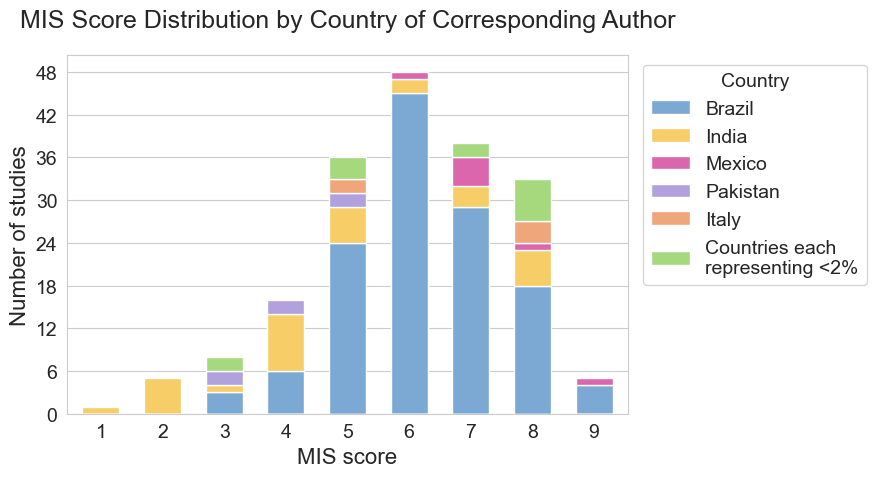

In [318]:
# MIS score distribution stacked by country (same <2% grouping as pie chart above)

# Country grouping — identical logic to the pie chart
# TODO-RAWDATA: 'Parkistan' typo and 'Great Britain ' trailing space will be fixed in final data
for idx, row in df_all.iterrows():
    if pd.isna(row['Country of corresponding author']) or str(row['Country of corresponding author']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty country field")
country_series_mis = (
    df_all['Country of corresponding author']
    .dropna()
    .astype(str)
    .str.strip()
    .replace({'N/A': 'Unknown', 'Parkistan': 'Pakistan'})
)
init_counts_mis = country_series_mis.value_counts()
init_total_mis = int(init_counts_mis.sum())
to_other_mis = init_counts_mis[(init_counts_mis / init_total_mis) * 100 < 2.0].index
country_grouped_mis = country_series_mis.replace(
    {k: 'Countries each\nrepresenting <2%' for k in to_other_mis}
)

# MIS scores aligned to rows that have both valid MIS AND valid country
mis_for_country = pd.to_numeric(df_all['MIS score'], errors='coerce')
valid_idx = mis_for_country.dropna().index.intersection(country_grouped_mis.index)
mis_clean = mis_for_country.loc[valid_idx].astype(int)
country_clean = country_grouped_mis.loc[valid_idx]

# Crosstab: MIS score (x-axis) × Country (stacked)
ctab_mis_country = pd.crosstab(mis_clean, country_clean)

# Order columns: countries by overall frequency, <2% group last
major_countries = [c for c in init_counts_mis.index if c not in to_other_mis]
col_order = [c for c in major_countries if c in ctab_mis_country.columns]
if 'Countries each\nrepresenting <2%' in ctab_mis_country.columns:
    col_order.append('Countries each\nrepresenting <2%')
ctab_mis_country = ctab_mis_country[col_order]

# Colors matching qualitative palette (same order as pie chart)

colors_country = QUALITATIVE_COLORS[:len(col_order)]

fig_mis_ctry, ax_mis_ctry = plt.subplots(figsize=(9, 5))
ctab_mis_country.plot(kind='bar', stacked=True, color=colors_country, ax=ax_mis_ctry, width=0.6)

ax_mis_ctry.set_xlabel('MIS score', fontsize=AXIS_LABEL_FS)
ax_mis_ctry.set_ylabel('Number of studies', fontsize=AXIS_LABEL_FS)
ax_mis_ctry.set_title('MIS Score Distribution by Country of Corresponding Author', fontsize=TITLE_FS, pad=20)
ax_mis_ctry.set_xticklabels(ctab_mis_country.index, rotation=0, fontsize=TICK_FS)
ax_mis_ctry.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax_mis_ctry.legend(
    title='Country',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=LEGEND_FS
)

ax_mis_ctry.xaxis.grid(False)
plt.tight_layout()
fig_mis_ctry.savefig('mis_country_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Language of Full Article

In [319]:
# Title: Language of Full Article Distribution (Pie Chart)
# Description: Normalizes language labels (handles '&' vs '+', trims, canonicalizes multi-language order),
#              aggregates counts, computes percentages with adaptive label placement, and renders/saves a Plotly pie chart.

# --- RAWDATA warnings for empty fields ---
for idx, row in df_all.iterrows():
    if pd.isna(row['Language of full article']) or str(row['Language of full article']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty Language of full article field")

# Prepare data — drop NaN/empty
language_series = (
    df_all['Language of full article']
    .dropna()
    .astype(str)
    .str.strip()
)
language_series = language_series[language_series != '']


# SPECIAL CASE re-labeling/normalization:
# - This is a dataset-specific cleanup to standardize mixed-language entries.
# - We treat '&' as equivalent to '+' and canonicalize the order of languages
#   so that permutations like "English+Spanish" and "Spanish+English" map to the same label.
def _normalize_language_label(s: str) -> str:
    if not s or s.lower() == 'unknown':
        return 'Unknown'
    # SPECIAL CASE: normalize separator
    s = s.replace('&', '+')
    parts = [p.strip().title() for p in s.split('+') if p.strip()]
    if not parts:
        return 'Unknown'
    # SPECIAL CASE: sort to combine permutations like "English+Spanish" and "Spanish+English"
    parts = sorted(dict.fromkeys(parts))  # remove duplicates and sort
    return '+'.join(parts) if len(parts) > 1 else parts[0]


# Apply the special-case normalization to the language labels
language_series = language_series.apply(_normalize_language_label)

language_counts = language_series.value_counts()
lang_labels = language_counts.index.tolist()
lang_values = language_counts.values.tolist()

# Compute percentages and set label positions
lang_total = sum(lang_values)
lang_percentages = [(v / lang_total) * 100 if lang_total else 0 for v in lang_values]
percentages_cutoff = 10
lang_text_positions = ['outside' if p < percentages_cutoff else 'inside' for p in lang_percentages]
lang_custom_text = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(lang_labels, lang_percentages, lang_text_positions)
]

# Build pie chart with style similar to the country chart
language_pie = go.Figure(
    data=[
        go.Pie(
            labels=lang_labels,
            values=lang_values,
            text=lang_custom_text,
            textinfo='text',
            textposition=lang_text_positions,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

language_pie.update_traces(
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=PLOTLY_TEXT_FS, color='black'),
language_pie.update_layout(
    title='Language of full article',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

language_pie.show()
language_pie.write_image('language_pie.png', width=800, height=600, scale=2)


  RAWDATA CLEANUP NEEDED: Covidence #4326 has empty Language of full article field
  RAWDATA CLEANUP NEEDED: Covidence #4665 has empty Language of full article field
  RAWDATA CLEANUP NEEDED: Covidence #6168 has empty Language of full article field


# Study Characteristics (MIS ≥ 5)

## MIS ≥ 5 Data Filter

In [320]:
# Here starts plottings that are only relevant for MIS score > 5
# ===============================================================

# Rebind df to the subset with MIS >= 5 for all plots below
df = df_all[df_all['MIS score'] >= 5].copy()
print(f'Using N={len(df)} studies with MIS score >= 5 for subsequent plots. Full number of studies is N={len(df_all)}')



Using N=160 studies with MIS score >= 5 for subsequent plots. Full number of studies is N=193


## Replication Status

In [321]:
# Title: Replication Landscape Among Included Studies (Pie Chart)
# Description:
# - Visualizes the distribution of studies by replication status: single studies, direct (actual) replications,
#   and studies replicating the same drug on a different plant system.
# - Labels are positioned adaptively for readability, and a small slice is slightly separated to draw attention.
# - NOTE: Values are placeholder (MADE UP DATA). Replace with dynamic counts once replication metadata are available.

ironic_replications = go.Figure(data=[go.Pie(
    labels=['Single studies', 'Actual replications', 'Studies replicating a same drug<br>on other plant system'],
    values=[148, 0, 1],  # MADE UP DATA: replace with computed values from dataset
    textinfo='label+percent',
    textposition=['inside', 'none', 'outside'],
    insidetextorientation='horizontal',
    pull=[0, 0, 0.08],  # separate the tiny slice
    hovertemplate='%{label}: %{value} studies<extra></extra>'
)])

ironic_replications.update_traces(
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    insidetextfont=dict(color='black'),
)


textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
ironic_replications.update_layout(
    margin=dict(t=120, b=20, l=20, r=20)
)

ironic_replications.show()
ironic_replications.write_image('replications.png', width=800, height=600, scale=2)


## Blinding Status

In [322]:
# Title: Blinding Status Distribution (Pie Chart)
# Description: Visualizes the distribution of blinding status among included studies (current MIS ≥ 5 subset).
#              Cleans labels, aggregates counts, computes percentages with adaptive label placement for readability,
#              renders an interactive Plotly pie chart, and saves it as 'blinded_pie.png'.

# Warn about empty blinding fields (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Blinded']) or str(row['Blinded']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty blinding field")

# Prepare data — drop NaN, rename literal 'N/A' text to 'Unknown' for display
blinded_series = (
    df['Blinded']
    .dropna()
    .astype(str)
    .str.strip()
    .replace({'N/A': 'Unknown'})
)

blinded_counts = blinded_series.value_counts()
blinded_labels = blinded_counts.index.tolist()
blinded_values = blinded_counts.values.tolist()

# Compute percentages and set label positions
blinded_total = sum(blinded_values)
blinded_percentages = [(v / blinded_total) * 100 if blinded_total else 0 for v in blinded_values]
percentages_cutoff = 10
blinded_text_positions = ['outside' if p < percentages_cutoff else 'inside' for p in blinded_percentages]
blinded_custom_text = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(blinded_labels, blinded_percentages, blinded_text_positions)
]

# Build pie chart with style similar to the language chart
blinded_pie = go.Figure(
    data=[
        go.Pie(
            labels=blinded_labels,
            values=blinded_values,
            text=blinded_custom_text,
            textinfo='text',
            textposition=blinded_text_positions,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

blinded_pie.update_traces(
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=PLOTLY_TEXT_FS, color='black'),
blinded_pie.update_layout(
    title='Blinded',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

# Display chart and save
blinded_pie.show()
blinded_pie.write_image('blinded_pie.png', width=800, height=600)

  RAWDATA CLEANUP NEEDED: Covidence #2001 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #2036 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #2230 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #7204 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #10492 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #10584 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #10593 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #4230 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #4230 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #4734 has empty blinding field
  RAWDATA CLEANUP NEEDED: Covidence #4734 has empty blinding field


## Experimental Settings

In [323]:
# Warn about empty setting fields (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Setting in which treated']) or str(row['Setting in which treated']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty setting field")

df['Setting in which treated'].dropna().value_counts().sort_index()



Setting in which treated
Farm / open fields                                                            37
Farm / open fields, Greenhouse open                                            1
Farm / open fields, Indoor unspecific                                          1
Greenhouse clima controlled                                                    8
Greenhouse clima controlled, Microbiological experiment                        1
Greenhouse open                                                               35
Greenhouse open, Indoor unspecific                                             1
Greenhouse open, Microbiological experiment                                    1
Greenhouse unspecific                                                         24
Greenhouse unspecific, Farm / open fields                                      1
Greenhouse unspecific, Greenhouse clima controlled                             1
Greenhouse unspecific, Microbiological experiment                              1
Gre

### Experimental Setting Bar Chart

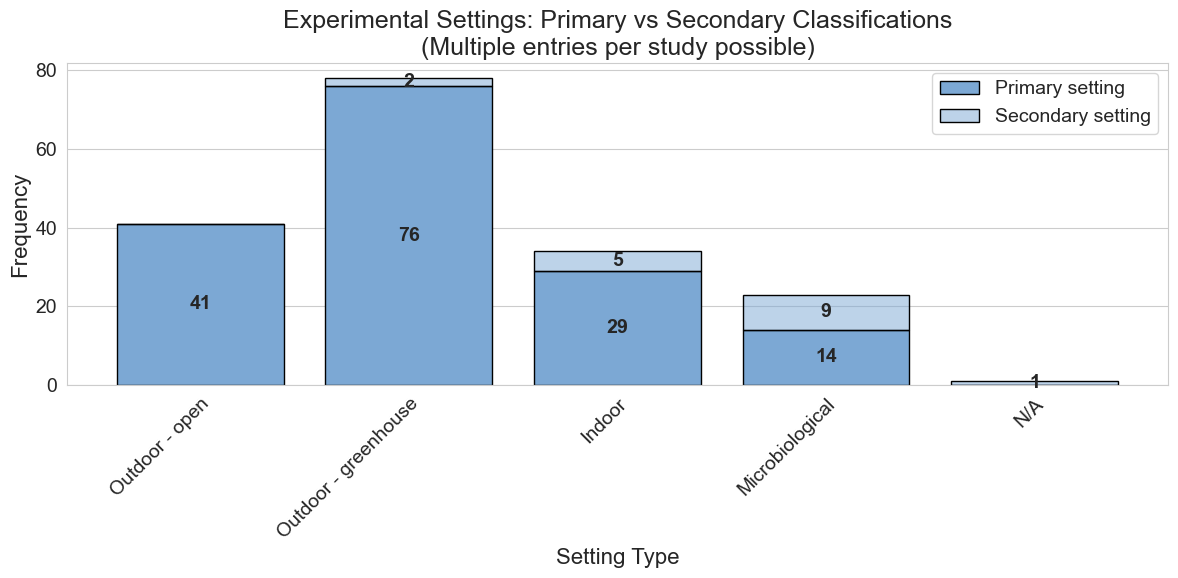

In [324]:
# Setting in which treated bar chart. Makes a chart with the first bar being Outdoor - open (most open) and so forth (less open, more controlled). If a study has multiple settings, it counts in multiple bars, but any secondary (or third...) settings are counted in the secondary bars on top. This primary/secondary is prioritized according to the same order from most open to least open.

# Create mapping dictionary
mapping = {
    'Farm / open fields': 'Outdoor - open',
    'Greenhouse clima controlled': 'Outdoor - greenhouse',
    'Greenhouse open': 'Outdoor - greenhouse',
    'Greenhouse unspecific': 'Outdoor - greenhouse',
    'Indoor clima controlled': 'Indoor',
    'Indoor unspecific': 'Indoor',
    'Microbiological experiment': 'Microbiological',
    'N/A or not relevant': 'N/A'
}

# Define categories in order of importance
categories = ['Outdoor - open', 'Outdoor - greenhouse', 'Indoor', 'Microbiological', 'N/A']

# Initialize counters
primary_counts = {cat: 0 for cat in categories}
secondary_counts = {cat: 0 for cat in categories}

# Process each entry
# Warnings for empty setting fields printed in the cell above
for entry in df['Setting in which treated'].dropna():
    # Split by comma and strip whitespace
    settings = [s.strip() for s in entry.split(',')]

    # Map each setting to category
    mapped_settings = []
    for setting in settings:
        if setting in mapping:
            mapped_settings.append(mapping[setting])

    if mapped_settings:
        # First category (highest priority) goes to primary
        primary_category = None
        for cat in categories:  # Check in order of importance
            if cat in mapped_settings:
                primary_category = cat
                break

        if primary_category:
            primary_counts[primary_category] += 1

            # Remaining categories go to secondary
            remaining = [cat for cat in mapped_settings if cat != primary_category]
            for cat in remaining:
                secondary_counts[cat] += 1

# Create the plot
settings_bar, ax = plt.subplots(figsize=(12, 6))

# Use standard colors from global settings:
# - All primary bars use the first green from the global palette
# - "Light" bars remain defined via transparency (same hue with alpha)
try:
    base_color = QUALITATIVE_COLORS[0]  # first green from global palette
except NameError:
    base_color = '#6CB86E'  # fallback to the known first green used globally

colors = {cat: base_color for cat in categories}
light_colors = {cat: base_color + '80' for cat in categories}  # 50% transparency (RGBA hex)

x_pos = np.arange(len(categories))

# Plot primary bars
primary_values = [primary_counts[cat] for cat in categories]
bars1 = ax.bar(x_pos, primary_values, color=[colors[cat] for cat in categories],
               label='Primary setting', edgecolor='black')

# Plot secondary bars on top
secondary_values = [secondary_counts[cat] for cat in categories]
bars2 = ax.bar(x_pos, secondary_values, bottom=primary_values,
               color=[light_colors[cat] for cat in categories],
               label='Secondary setting', edgecolor='black')

# Customize the plot
ax.set_xlabel('Setting Type')
ax.set_ylabel('Frequency')
ax.set_title('Experimental Settings: Primary vs Secondary Classifications\n(Multiple entries per study possible)')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, rotation=45, ha='right', rotation_mode='anchor')
ax.legend()

# Add value labels on bars
for i, (p, s) in enumerate(zip(primary_values, secondary_values)):
    if p > 0:
        ax.text(i, p / 2, str(p), ha='center', va='center', fontweight='bold')
    if s > 0:
        ax.text(i, p + s / 2, str(s), ha='center', va='center', fontweight='bold')

ax.xaxis.grid(False)
plt.tight_layout()
settings_bar.savefig('settings_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Crop Types Studied

### Crop Type Frequencies

In [325]:
# Load hand-curated cluster mappings from 260505_Outcome and crop clusters.csv.
# This CSV holds three lookups in one file:
#   - col A "Outcome measures (specific)"   -> col B "Cluster general "    (general outcome cluster)
#   - col C "Mapping Cluster general"       -> col D "Mapping Agronomy cluster"  (second-level agronomy grouping)
#   - col E "Crop type studied"             -> col F "Cluster"             (crop-type cluster)
# Note the trailing space in the column header "Cluster general " — preserved as written in the source CSV.

cluster_csv = pd.read_csv('260505_Outcome and crop clusters.csv')

# Outcome -> general cluster (lowercased + stripped key for case-insensitive match)
lookup_outcome_general = {
    str(r['Outcome measures (specific)']).lower().strip(): str(r['Cluster general ']).strip()
    for _, r in cluster_csv.iterrows()
    if pd.notna(r['Outcome measures (specific)']) and pd.notna(r['Cluster general '])
}

# General cluster -> agronomy cluster (small mapping table; only ~7 rows populated)
lookup_general_agronomy = {
    str(r['Mapping Cluster general']).strip(): str(r['Mapping Agronomy cluster']).strip()
    for _, r in cluster_csv.iterrows()
    if pd.notna(r['Mapping Cluster general']) and pd.notna(r['Mapping Agronomy cluster'])
}

# Crop name -> crop cluster (Horticulture, Cereal and Grains, Pulses, …)
lookup_crop_cluster = {
    str(r['Crop type studied']).lower().strip(): str(r['Cluster']).strip()
    for _, r in cluster_csv.iterrows()
    if pd.notna(r['Crop type studied']) and pd.notna(r['Cluster'])
}

print(f"lookup_outcome_general: {len(lookup_outcome_general)} entries")
print(f"lookup_general_agronomy: {len(lookup_general_agronomy)} entries -> {lookup_general_agronomy}")
print(f"lookup_crop_cluster: {len(lookup_crop_cluster)} entries")


lookup_outcome_general: 377 entries
lookup_general_agronomy: 7 entries -> {'Morphometrics': 'Plant morphology & Crop development', 'Physiology': 'Plant physiology & Metabolism', 'Metabolism': 'Plant physiology & Metabolism', 'Disease incidence & severity': 'Agricultural phytopathology', 'Entomology': 'Agricultural entomology', 'Pest incidence & severity': 'Agricultural entomology', 'Soil fertility': 'Soil Science'}
lookup_crop_cluster: 72 entries


### Crop freqencies 1

  RAWDATA CLEANUP NEEDED: Covidence #5109 has empty crop type field
  RAWDATA CLEANUP NEEDED: Covidence #11703 has empty crop type field
  RAWDATA CLEANUP NEEDED: Covidence #11860 has empty crop type field


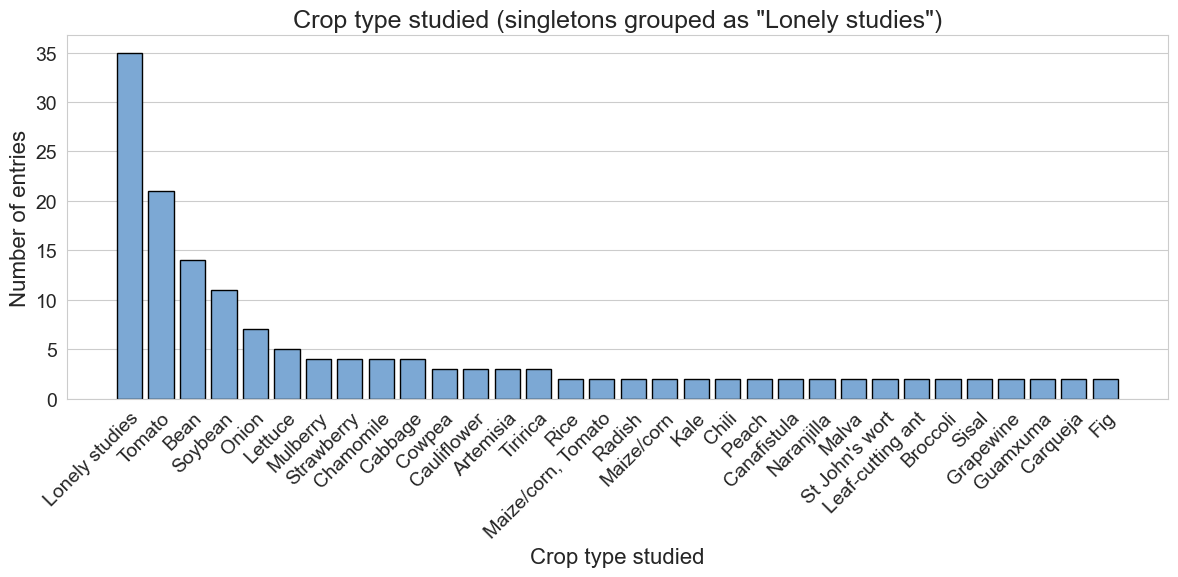

In [326]:
# Analyze and visualize the distribution of "Crop type studied" with all singletons grouped as "Lonely studies".
# Steps:
# 1) Clean the "Crop type studied" column (drop missing, ensure strings, trim spaces).
# 2) Count occurrences of each unique crop type.
# 3) Group all categories that appear only once (singletons) under a single label "Lonely studies".
# 4) Sort by frequency (descending) and plot a bar chart.
# 5) Save the figure as a PNG and display it.

# 1) Clean the source series
# Warn about empty crop fields (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Crop type studied']) or str(row['Crop type studied']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty crop type field")

crop_series = df['Crop type studied'].dropna().astype(str).str.strip()

# 2) Raw counts by crop type
crop_counts = crop_series.value_counts()

# 3) Group all singletons under "Lonely studies"
lonely_mask = crop_counts == 1  # True for categories that appear exactly once
lonely_count = int(crop_counts[lonely_mask].sum())  # Total number of singleton entries (studies)
grouped_counts = crop_counts[~lonely_mask].copy()  # Keep non-singletons as-is
if lonely_count > 0:
    grouped_counts.loc['Lonely studies'] = lonely_count

# 4) Sort for plotting
grouped_counts = grouped_counts.sort_values(ascending=False)

# 5) Plot bar chart
# Use matplotlib directly
fig, crop_bar = plt.subplots(figsize=(12, 6))
bars = crop_bar.bar(range(len(grouped_counts)), grouped_counts.values, edgecolor='black')
crop_bar.set_xticks(range(len(grouped_counts)))
crop_bar.set_xticklabels(grouped_counts.index, rotation=45, ha='right', rotation_mode='anchor', fontsize=TICK_FS)
crop_bar.set_xlabel('Crop type studied', fontsize=AXIS_LABEL_FS)
crop_bar.set_ylabel('Number of entries', fontsize=AXIS_LABEL_FS)
crop_bar.set_title('Crop type studied (singletons grouped as "Lonely studies")', fontsize=TITLE_FS)

# Save and show
crop_bar.xaxis.grid(False)
crop_bar.figure.tight_layout()
crop_bar.figure.savefig('crop_type_bar.png', dpi=300, bbox_inches='tight')
plt.show()


### Crop freqencies 2

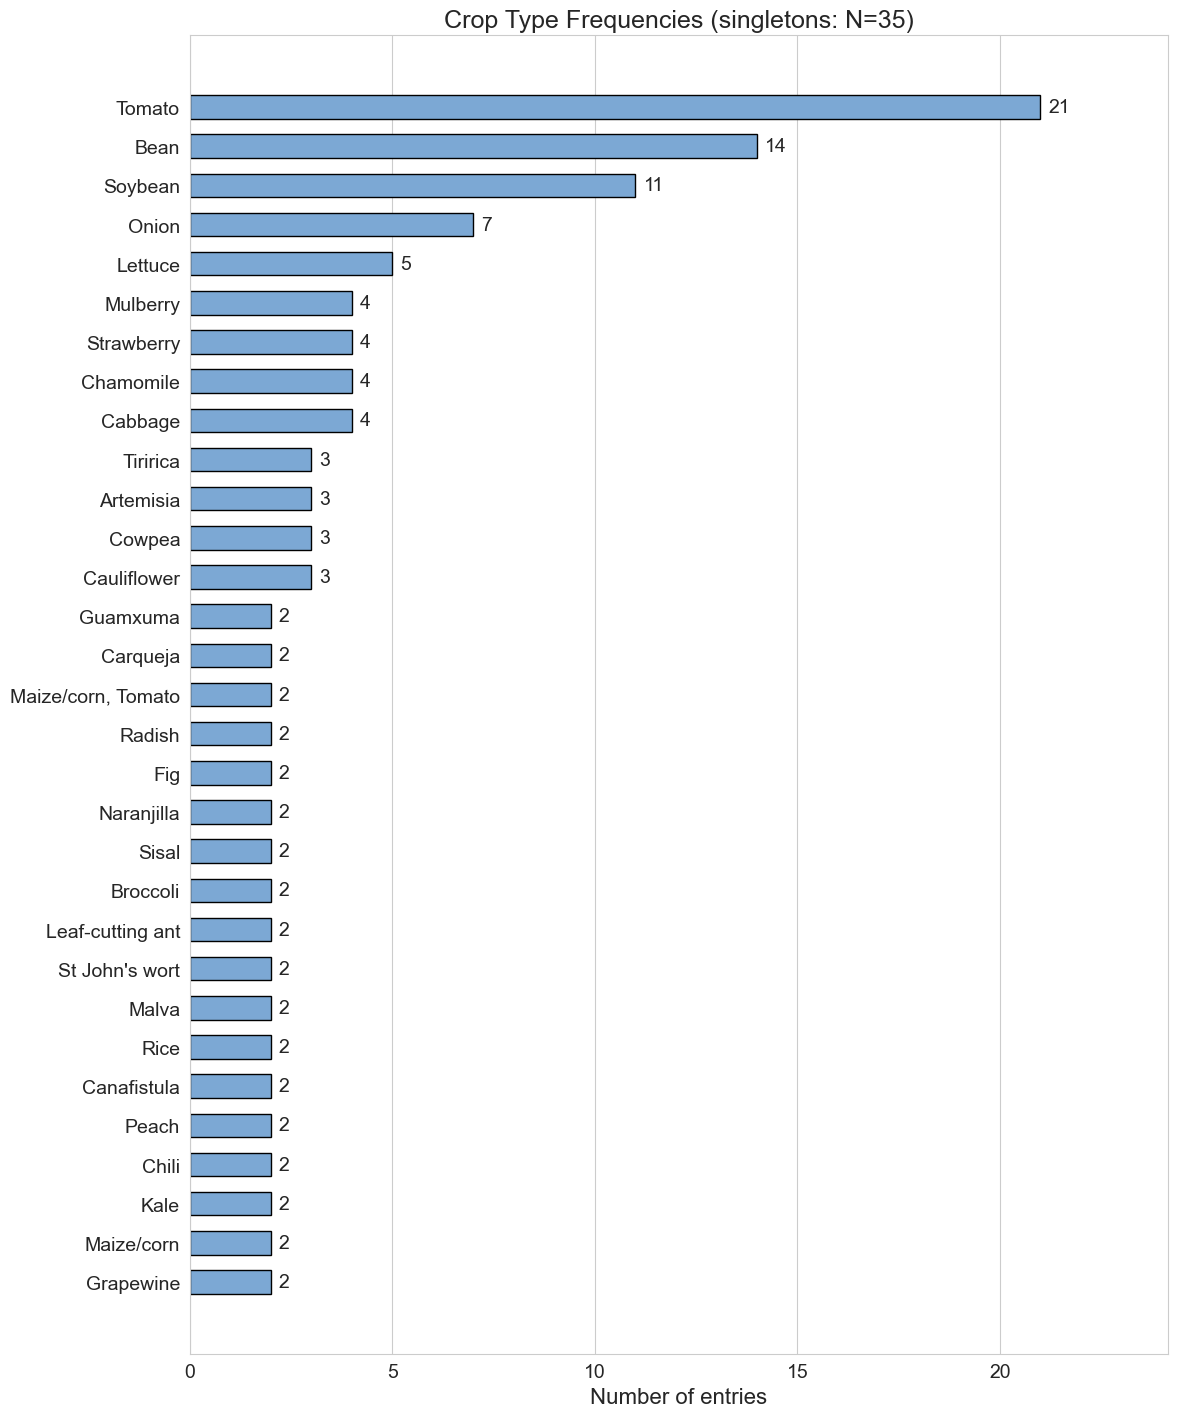

In [327]:
# Horizontal bar chart of crop type frequencies (no singletons)
# Reuses crop_counts from the cell above.
# Singletons are removed and their count noted in the title.

# Filter out singletons
crop_counts_no_singles = crop_counts[crop_counts > 1].sort_values(ascending=True)
n_singletons = int((crop_counts == 1).sum())

n_crops_h = len(crop_counts_no_singles)
fig_crop_h, ax_crop_h = plt.subplots(figsize=hbar_figsize(n_crops_h))

ax_crop_h.barh(range(n_crops_h), crop_counts_no_singles.values, edgecolor='black', height=BAR_H)
ax_crop_h.set_yticks(range(n_crops_h))
ax_crop_h.set_yticklabels(crop_counts_no_singles.index, fontsize=TICK_FS)
ax_crop_h.set_xlabel('Number of entries', fontsize=AXIS_LABEL_FS)
ax_crop_h.set_title(f'Crop Type Frequencies (singletons: N={n_singletons})')

# Value labels at end of each bar
for i, v in enumerate(crop_counts_no_singles.values):
    ax_crop_h.text(v + 0.2, i, str(v), va='center', fontsize=DATA_LABEL_FS)

max_val = crop_counts_no_singles.values.max()
ax_crop_h.set_xlim(0, max_val * 1.15)
ax_crop_h.yaxis.grid(False)

plt.tight_layout()
plt.savefig('crop_type_bar_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()


### Crop Cluster Frequencies

Crop clusters found: 9
  Horticulture: 61
  Pulses: 34
  Medicinal/aromatic: 22
  Fruticulture: 17
  Other: 13
  Medicinal Plants: 10
  Cereal and Grains: 9
  Weeds: 6
  Silviculture: 1

Unmatched crops grouped into 'Other' (11 unique):
  'leaf-cutting ant': 2
  'grapewine': 2
  'cucumber - (cucumis sativus)': 1
  'alfavaca_basil-clover': 1
  'lady's finger': 1
  'st. john’s wort': 1
  'white afelandra': 1
  'moss rose (flower)': 1
  'brown betty (flower)': 1
  'madagaskar periwinkle (flower)': 1
  'scalion': 1


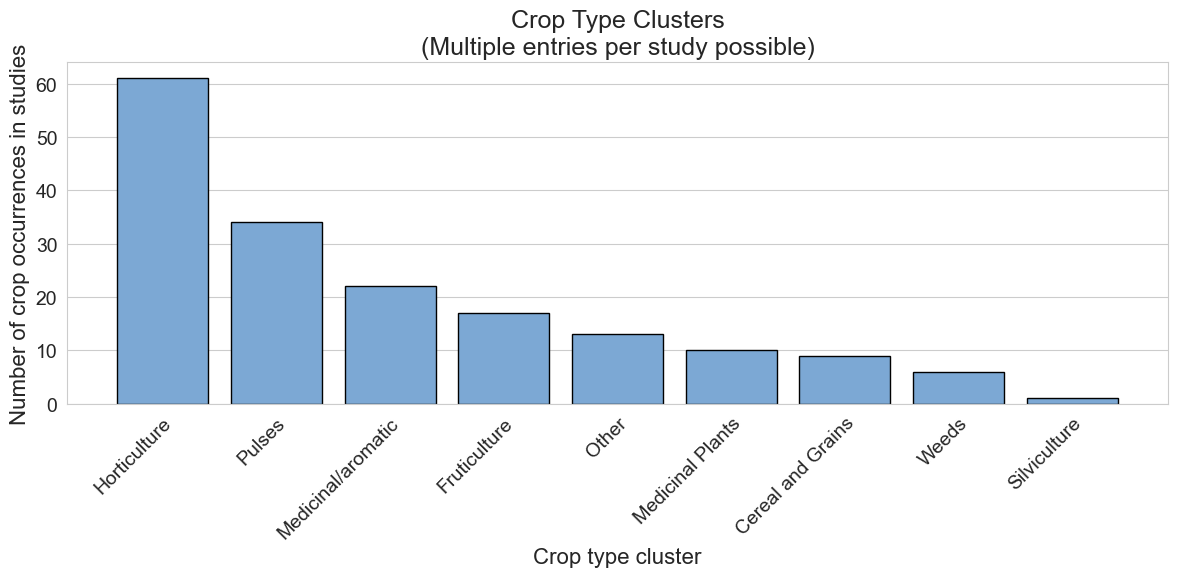

Chart saved: crop_cluster_bar.png


In [328]:
# Bar chart: studies grouped by crop-type cluster (col F of 260505 CSV)
# Mirrors the original crop_type_bar.png cell, but rolls every individual crop up
# to its higher-level cluster (Horticulture, Cereal and Grains, Pulses, Fruticulture,
# Legume, Medicinal Plants, Medicinal/aromatic, Floriculture, Silviculture, Weeds).
# Multi-crop studies: comma-split and count each crop occurrence in its respective cluster.
# No "Lonely studies" bucket — clustering already absorbs the long tail of single-crop entries.

from collections import Counter

crop_cluster_counts = Counter()
unmatched_crops = Counter()

# Warnings for empty crop fields printed in the cell above
for raw in df['Crop type studied'].dropna().astype(str):
    # Each study can list multiple crops separated by commas.
    for token in raw.split(','):
        crop = token.strip().lower()
        if crop == '':
            continue
        cluster = lookup_crop_cluster.get(crop)
        if cluster is None or cluster == '':
            crop_cluster_counts['Other'] += 1
            unmatched_crops[crop] += 1
        else:
            crop_cluster_counts[cluster] += 1

# Sort descending for the bar chart
crop_cluster_series = pd.Series(crop_cluster_counts).sort_values(ascending=False)

print(f"Crop clusters found: {len(crop_cluster_series)}")
for cluster, n in crop_cluster_series.items():
    print(f"  {cluster}: {n}")
if unmatched_crops:
    print(f"\nUnmatched crops grouped into 'Other' ({len(unmatched_crops)} unique):")
    for crop, n in sorted(unmatched_crops.items(), key=lambda x: -x[1]):
        print(f"  '{crop}': {n}")

fig, crop_cluster_bar = plt.subplots(figsize=(12, 6))
bars = crop_cluster_bar.bar(range(len(crop_cluster_series)), crop_cluster_series.values, edgecolor='black')
crop_cluster_bar.set_xticks(range(len(crop_cluster_series)))
crop_cluster_bar.set_xticklabels(crop_cluster_series.index, rotation=45, ha='right', rotation_mode='anchor', fontsize=TICK_FS)
crop_cluster_bar.set_xlabel('Crop type cluster', fontsize=AXIS_LABEL_FS)
crop_cluster_bar.set_ylabel('Number of crop occurrences in studies', fontsize=AXIS_LABEL_FS)
crop_cluster_bar.set_title('Crop Type Clusters\n(Multiple entries per study possible)', fontsize=TITLE_FS)
crop_cluster_bar.xaxis.grid(False)

crop_cluster_bar.figure.tight_layout()
crop_cluster_bar.figure.savefig('crop_cluster_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: crop_cluster_bar.png")


### Crop Cluster Treemap

In [329]:
# Treemap of crops grouped by crop-type cluster (col F of 260505 CSV).
# Two-level hierarchy: cluster (parent rectangle) -> crop (child rectangle).
# Crops with >=MIN_STUDIES studies are shown individually; the long tail of
# crops below that is rolled up into one "Other (k crops)" leaf *per cluster*,
# so each cluster's total area still reflects all of its crops.
# Uses QUALITATIVE_COLORS so each cluster gets a distinct color shared by all
# its crop children — visual cohesion within a cluster, white borders separate crops.

from collections import Counter, defaultdict
import plotly.express as px

# Step 1: count each crop occurrence (comma-split — same convention as crop_cluster_bar)
crop_counter = Counter()
# Warnings for empty crop fields printed in the crop bar chart cell above
for raw in df['Crop type studied'].dropna().astype(str):
    for token in raw.split(','):
        crop = token.strip().lower()
        if crop == '':
            continue
        crop_counter[crop] += 1

# Step 2: resolve each crop to its cluster, then fold entire clusters that are
# too small to read on their own into the catch-all "Other" cluster. This is a
# different merge from the per-crop "tail" rollup below: it operates on whole
# clusters (e.g. a cluster like Silviculture with only 1 total occurrence),
# not on individual crops within an otherwise well-populated cluster.
MIN_STUDIES = 4
# Clusters with fewer than this many total occurrences merge into "Other".
MIN_CLUSTER_TOTAL = 3

crop_cluster_map = {}
cluster_totals = defaultdict(int)
for crop, n in crop_counter.items():
    cluster = lookup_crop_cluster.get(crop)
    if not cluster or pd.isna(cluster):
        cluster = 'Other'
    crop_cluster_map[crop] = cluster
    cluster_totals[cluster] += n

small_clusters = {
    c for c, total in cluster_totals.items() if c != 'Other' and total < MIN_CLUSTER_TOTAL
}
if small_clusters:
    print(f"Clusters merged into 'Other' (total < {MIN_CLUSTER_TOTAL}): {sorted(small_clusters)}")
for crop, cluster in crop_cluster_map.items():
    if cluster in small_clusters:
        crop_cluster_map[crop] = 'Other'

# Step 3: split crops into "named" (>=MIN_STUDIES, shown individually) and
# "tail" (rolled up into a per-cluster "Other" leaf).
# Buckets keyed by cluster:
#   tail_counts[cluster] = total occurrences of below-threshold crops in that cluster
#   tail_n_crops[cluster] = how many distinct crops were rolled up
tail_counts = defaultdict(int)
tail_n_crops = defaultdict(int)
treemap_rows = []

for crop, n in crop_counter.items():
    cluster = crop_cluster_map[crop]
    if n >= MIN_STUDIES:
        treemap_rows.append({'crop': crop.title(), 'cluster': cluster, 'count': n})
    else:
        tail_counts[cluster] += n
        tail_n_crops[cluster] += 1

# Append one synthetic "Other (k crops)" leaf per cluster with a non-empty tail.
# The label includes the count of rolled-up crops so the reader knows what's hidden.
for cluster, total in tail_counts.items():
    treemap_rows.append({
        'crop': 'Other',
        'cluster': cluster,
        'count': total,
    })

treemap_df = pd.DataFrame(treemap_rows)
print(f"Named crops (>={MIN_STUDIES} studies): {sum(1 for r in treemap_rows if r['crop'] != 'Other')}")
print(f"Tail buckets ('Other' leaves): {len(tail_counts)}")
print(f"Tail crops rolled up: {sum(tail_n_crops.values())}")
print(f"Total crop occurrences in treemap: {treemap_df['count'].sum()}")
print(f"Clusters represented: {treemap_df['cluster'].nunique()}")

# Step 4: build treemap. path=[Constant root, cluster, crop] gives 2 nesting levels.
# color='cluster' maps each cluster to a QUALITATIVE_COLORS slot; crop leaves inherit
# their parent cluster's color, so visual grouping is automatic.
fig_crop_tree = px.treemap(
    treemap_df,
    path=[px.Constant('Crop clusters'), 'cluster', 'crop'],
    values='count',
    color='cluster',
    color_discrete_sequence=QUALITATIVE_COLORS_AGRO_BROWN,
)
fig_crop_tree.update_traces(
    marker=dict(line=dict(color='white', width=2)),
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    textinfo='label+value',
    textposition='middle center',
)
fig_crop_tree.update_layout(
    title=f'Crop Type Clusters - Treemap (crops with <{MIN_STUDIES} labled "Other"; N={treemap_df["count"].sum()})<br><sup>(Multiple entries per study possible)</sup>',
    margin=dict(t=60, b=20, l=20, r=20),
)

fig_crop_tree.show()
fig_crop_tree.write_image('crop_cluster_treemap.png', width=1000, height=700, scale=2)
print("Chart saved: crop_cluster_treemap.png")


Clusters merged into 'Other' (total < 3): ['Silviculture']
Named crops (>=4 studies): 10
Tail buckets ('Other' leaves): 8
Tail crops rolled up: 57
Total crop occurrences in treemap: 173
Clusters represented: 8


Chart saved: crop_cluster_treemap.png


## Main Biological Systems

In [330]:
# Data preparation for the "Main Biological Systems" treemap (see cell below).
# Column: "Main biological system studied". Multiple systems are separated by
# commas and counted individually, except "Harvest (fruit, grains, tubers)",
# which is kept as a single, unsplit category.

# 1) Warn about empty fields, then clean
for idx, row in df.iterrows():
    if pd.isna(row['Main biological system studied']) or str(row['Main biological system studied']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty biological system field")

bio_series = (
    df['Main biological system studied']
    .dropna()
    .astype(str)
    .str.strip()
    .replace({'N/A': 'Unknown'})
)

# 2) Protect the multi-word phrase so it doesn't get split by commas
protected_phrase = 'Harvest (fruit, grains, tubers)'
protected_placeholder = 'Harvest (fruit-grains-tubers)'  # temporary replacement (semicolons)

# Replace the protected phrase with a placeholder before splitting
bio_series = bio_series.str.replace(protected_phrase, protected_placeholder, regex=False)

# 3) Split by comma, explode into one value per row, and clean up
bio_exploded = (
    bio_series
    .str.split(',')  # split comma-separated values
    .explode()  # one value per row
    .astype(str)
    .str.strip()
)

# Restore the protected phrase and handle any remaining empties
bio_exploded = bio_exploded.replace({protected_placeholder: protected_phrase})
bio_exploded = bio_exploded[bio_exploded != '']

# 4) Consolidate raw category variants and simplify long names *before* counting,
# so entries that should become one slice are actually merged — not just
# relabeled into two same-named slices with separate counts.
# - 'Animal (eg. insect)' and the quoted Harvest variant are pure spelling/
#   formatting cleanup: same real category, different raw text, no meaning lost.
# - 'Run-overs' -> 'Cutlings' and 'Cell culture' -> 'Fungus' are coarser,
#   judgment-call merges (not spelling variants) to shrink the long tail of
#   tiny categories. FLAG: this is a slightly inconsistent clustering choice —
#   'Run-overs' and 'Cell culture' aren't obviously the same biological system
#   as 'Cutlings'/'Fungus', just the closest existing bucket. Worth revisiting
#   if a more precise category is ever warranted.
# TODO-RAWDATA: 'Cutlings' should be spelled 'Cuttlings' (double t) in the
# source data — kept as-is here to match current raw values; fix at the
# source and update this map (and color_map below) once corrected.
display_rename = {
    'Animal (eg. insect)': 'Animal',
    'Harvest (fruit, grains, tubers)': 'Harvest',
    '"Harvest (fruit-grains-tubers)"': 'Harvest',  # quoted variant seen in raw data
    'Run-overs': 'Cutlings',
    'Cell culture': 'Fungus',
}
bio_exploded = bio_exploded.replace(display_rename)

# 5) Aggregate counts and prepare labels/values (now properly merged, not just
# relabeled — see step 4)
bio_counts = bio_exploded.value_counts()
bio_labels = bio_counts.index.tolist()
bio_values = bio_counts.values.tolist()

# 6) Define intuitive colors matching labels
color_map = {
    'Adult plants': '#1b7837',  # dark green (mature plants)
    'Seedling': '#5aae61',  # medium green (young plants)
    'Seed': '#8c510a',  # brown (seeds)
    'Cutlings': '#ccebc5',  # pale green (cuttings; also absorbs 'Run-overs')
    'Harvest': '#faa945',  # harvest -> golden/orange
    'Fungus': '#7c6a7c',  # purple (fungi; also absorbs 'Cell culture')
    'Bacteria': '#2b8cbe',  # blue (bacteria)
    'Animal': '#d95f02',  # orange (insects/animals)
    'Soil': '#664012',  # sark brown (soil)
    'Unknown': '#bdbdbd'  # light gray (unknown)
}
bio_colors = [color_map.get(lbl, '#cccccc') for lbl in bio_labels]
bio_labels = [add_line_breaks_to_label(lbl, strategy='parentheses') for lbl in bio_labels]

# 7) Custom text for the treemap: label + percentage, percentage on its own line
bio_total = int(sum(bio_values))
bio_custom_text = []
for label, value in zip(bio_labels, bio_values):
    percent = (value / bio_total) * 100
    bio_custom_text.append(f'{label}<br>{percent:.1f}%')


  RAWDATA CLEANUP NEEDED: Covidence #5117 has empty biological system field


In [331]:
# Create treemap chart for Main Biological System

bio_treemap = go.Figure(
    data=[
        go.Treemap(
            labels=bio_labels,
            values=bio_values,
            parents=[''] * len(bio_labels),  # all at root level
            text=bio_custom_text,
            textinfo='text',
            textposition='middle center',
            marker=dict(
                colors=bio_colors,
                line=dict(color='white', width=2)
            ),
            textfont=dict(size=PLOTLY_TEXT_FS, color='black')
        )
    ]
)

bio_treemap.update_layout(
    title=f'Biological Systems Studied - Treemap (N={bio_total})',
    margin=dict(t=60, b=20, l=20, r=20)
)

bio_treemap.show()
bio_treemap.write_image('main_bio_system_treemap.png', width=800, height=600, scale=2)


## Intervention Types

### Intervention Type Frequencies

  RAWDATA CLEANUP NEEDED: Covidence #10695 has empty Homeopathic intervention field
Homeopathic interventions — summary
-----------------------------------
Kept in table but excluded from chart (non-route modifier): "Additional: Dilution in water before application"

Number of interventions per study (count of studies having 0, 1, 2, ... interventions):
                          Number of studies
Homeopathic intervention                   
1                                       147
2                                        10
3                                         2


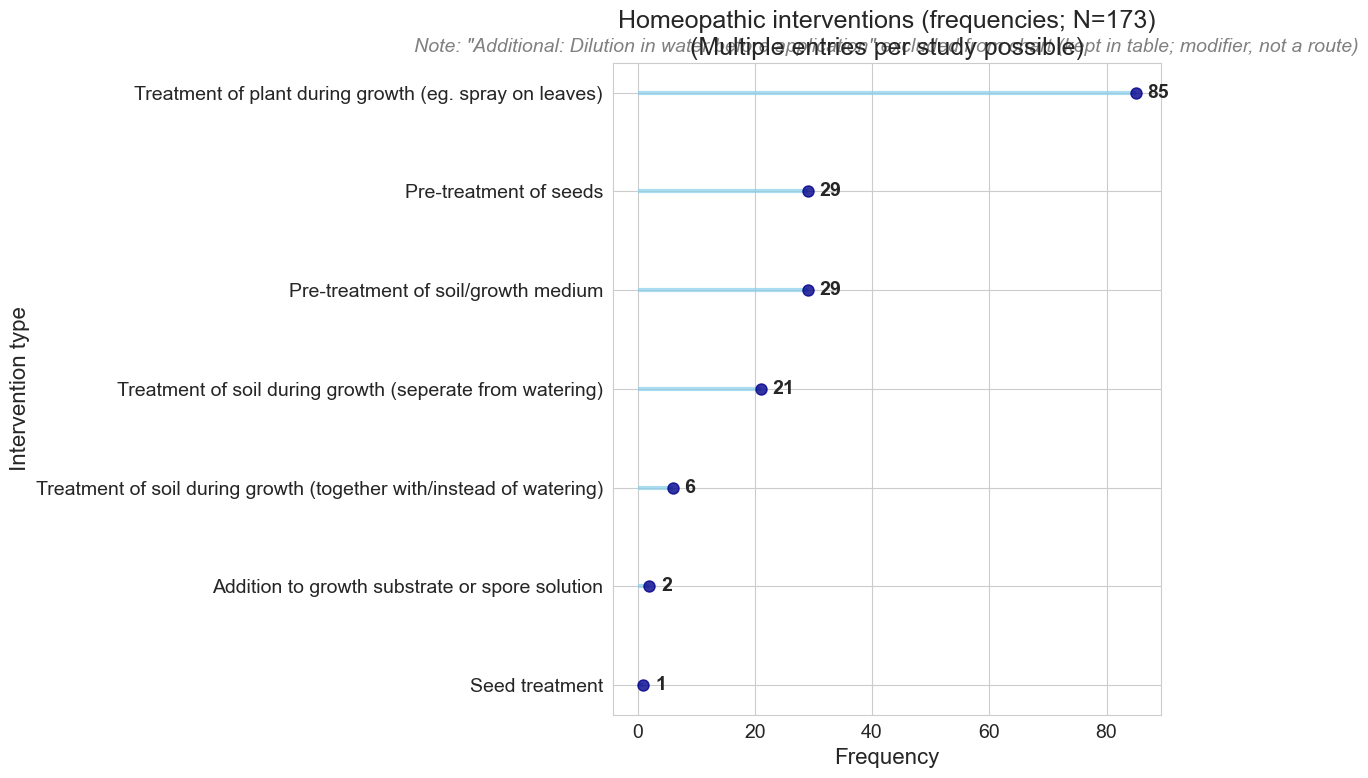

  RAWDATA CLEANUP NEEDED: Covidence #4315 has empty Materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #4845 has empty Materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #5111 has empty Materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty Materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #10537 has empty Materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty Materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #11735 has empty Materials for potentization field

ETHANOL vs WATER AT APPLICATION (per study)
Ethanol                            87  ( 56.1% of classified)
Water                              29  ( 18.7% of classified)
Water (diluted at application)     15  (  9.7% of classified)
Unknown                            24  ( 15.5% of classified)
No info                             5
-----------------------------------------------------------------

In [332]:
# Analysis: Homeopathic intervention types (lollipop chart)
# What this cell does:
# 1) Cleans and splits the "Homeopathic intervention" column on commas to get individual interventions.
# 2) Keeps "Additional: Dilution in water before application" in the frequency
#    table but excludes it from the chart bars — it is a modifier, not an
#    application route (its water/ethanol meaning is handled separately).
# 3) Computes:
#    - A frequency table of intervention types.
#    - The distribution of how many interventions are listed per study.
# 4) Visualizes the intervention frequencies as a lollipop chart with data labels.

# --- RAWDATA warnings for empty fields ---
for idx, row in df.iterrows():
    if pd.isna(row['Homeopathic intervention']) or str(row['Homeopathic intervention']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty Homeopathic intervention field")

# Clean and split the entries — drop NaN/empty
homeopathic_series_hom_interven = (
    df['Homeopathic intervention']
    .dropna()
    .astype(str)
    .str.strip()
)
homeopathic_series_hom_interven = homeopathic_series_hom_interven[homeopathic_series_hom_interven != '']

exploded_interventions_hom_interven = (
    homeopathic_series_hom_interven
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
exploded_interventions_hom_interven = exploded_interventions_hom_interven[exploded_interventions_hom_interven != '']

# "Additional: Dilution in water before application" is a modifier (it describes
# the water/ethanol nature of the prep, handled separately), not an application
# route. We KEEP it in the frequency table below, but exclude it from the chart.
dilution_label = "Additional: Dilution in water before application"

# Frequency table
homeopathic_intervention_freq_hom_interven = (
    exploded_interventions_hom_interven
    .value_counts()
    .to_frame(name='Frequency')
)


# Compute per-study counts of interventions (excluding 'Unknown')
def _count_interventions_hom_interven(cell: str) -> int:
    parts = [p.strip() for p in str(cell).split(',')]
    parts = [p for p in parts if p and p not in ('N/A', dilution_label)]
    return len(parts)


per_study_counts_hom_interven = homeopathic_series_hom_interven.apply(_count_interventions_hom_interven)
interventions_per_study_counts_hom_interven = (
    per_study_counts_hom_interven.value_counts().sort_index().to_frame(name='Number of studies')
)

# Intro/summary prints
print('Homeopathic interventions — summary')
print('-----------------------------------')
print(f'Kept in table but excluded from chart (non-route modifier): "{dilution_label}"')
print('\nNumber of interventions per study (count of studies having 0, 1, 2, ... interventions):')
print(interventions_per_study_counts_hom_interven)

# Show the frequency table
homeopathic_intervention_freq_hom_interven

# Build lollipop chart
fig_hom_interven, ax_hom_interven = plt.subplots(figsize=(12, 8))

# Sort data ascending for a clean lollipop layout. Exclude the dilution modifier
# from the chart only (it remains in the frequency table above).
sorted_data_hom_interven = (
    homeopathic_intervention_freq_hom_interven
    .drop(index=dilution_label, errors='ignore')
    .sort_values('Frequency', ascending=True)
)
y_pos_hom_interven = np.arange(len(sorted_data_hom_interven))

# Create lollipop stems and markers
ax_hom_interven.hlines(
    y=y_pos_hom_interven, xmin=0, xmax=sorted_data_hom_interven['Frequency'],
    color='skyblue', alpha=0.7, linewidth=3
)
ax_hom_interven.plot(
    sorted_data_hom_interven['Frequency'], y_pos_hom_interven, "o",
    markersize=8, color='darkblue', alpha=0.8
)

# Add numeric labels to the right of each marker
for i, v in enumerate(sorted_data_hom_interven['Frequency']):
    ax_hom_interven.text(v + 2, i, str(v), va='center', fontweight='bold')

# Axes and title
ax_hom_interven.set_yticks(y_pos_hom_interven)
ax_hom_interven.set_yticklabels(sorted_data_hom_interven.index)
ax_hom_interven.set_xlabel('Frequency')
ax_hom_interven.set_ylabel('Intervention type')

final_total = int(sorted_data_hom_interven['Frequency'].sum())
ax_hom_interven.set_title(
    f'Homeopathic interventions (frequencies; N={final_total})\n(Multiple entries per study possible)'
)

# Note under the title about the excluded modifier
ax_hom_interven.text(
    0.5, 1.01,
    'Note: "Additional: Dilution in water before application" excluded from chart (kept in table; modifier, not a route)',
    transform=ax_hom_interven.transAxes, ha='center', va='bottom', fontsize=DATA_LABEL_FS, fontstyle='italic', color='gray'
)

plt.tight_layout()
fig_hom_interven.savefig('homeopathic_interventions_lollipop.png', dpi=300, bbox_inches='tight')
plt.show()


#===== Ethanol vs water at application — classification (console output) =====

# Goal: estimate what the PLANT actually receives — an ethanol-based or a
# water-based preparation — by combining two columns:
#   - "Materials for potentization"  (the solvent the remedy was succussed in)
#   - "Homeopathic intervention"     ("Additional: Dilution in water before
#                                      application" = watered down at spray time)
# Ethanol is phytotoxic, so water-based / water-diluted preparations sit at the
# "plant-friendly" end of the spectrum.
#
# Classification precedence (highest first) — REVIEW: this encodes the agreed
# interpretation choices for the ambiguous combinations:
#   1. Dilution in water before application -> "Water (diluted at application)"
#      (the dilution is the final step before the plant, so it overrides the
#       potentization medium).
#   2. An explicit FINAL succussion step: last-in-water -> Water,
#      last-in-ethanol -> Ethanol, both present -> Unknown.
#   3. Plain succussion solvent: water only -> Water, ethanol only -> Ethanol,
#      both present -> Unknown.
#   4. Only generic "According to Homeopathic Pharmacopoeia" (or trituration /
#      maceration, no explicit solvent) -> Unknown (solvent not specified).
#   5. No potentization info and no water dilution -> "No info" (dropped + warned).

def classify_application_medium(materials_cell, intervention_cell):
    interv = "" if pd.isna(intervention_cell) else str(intervention_cell)
    has_dilution = "additional: dilution in water before application" in interv.lower()

    # No materials recorded: only the dilution flag can still tell us anything.
    if pd.isna(materials_cell) or str(materials_cell).strip() == "":
        return "Water (diluted at application)" if has_dilution else "No info"

    # Exact comma-token matching avoids the "last succussion in water" vs
    # "succussion in water" substring overlap.
    tokens = [t.strip().lower() for t in str(materials_cell).split(",") if t.strip()]
    has_succ_water = "succussion in water" in tokens
    has_succ_ethanol = "succussion in ethanol" in tokens
    has_last_water = any("last succussion in water" in t for t in tokens)
    has_last_ethanol = any("last succussion in ethanol" in t for t in tokens)

    if has_dilution:                                  # rule 1
        return "Water (diluted at application)"
    if has_last_water and has_last_ethanol:           # rule 2 (conflict)
        return "Unknown"
    if has_last_water:
        return "Water"
    if has_last_ethanol:
        return "Ethanol"
    if has_succ_water and has_succ_ethanol:           # rule 3 (conflict)
        return "Unknown"
    if has_succ_water:
        return "Water"
    if has_succ_ethanol:
        return "Ethanol"
    return "Unknown"                                  # rule 4


# Warn about studies with no potentization material recorded (data gap).
for idx, row in df.iterrows():
    if pd.isna(row["Materials for potentization"]) or str(row["Materials for potentization"]).strip() == "":
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty Materials for potentization field")

application_medium = df.apply(
    lambda r: classify_application_medium(
        r["Materials for potentization"], r["Homeopathic intervention"]
    ),
    axis=1,
)
medium_counts = application_medium.value_counts()

# Console summary
category_order = ["Ethanol", "Water", "Water (diluted at application)", "Unknown", "No info"]
classified_total = int(medium_counts.drop("No info", errors="ignore").sum())

print("\n" + "=" * 70)
print("ETHANOL vs WATER AT APPLICATION (per study)")
print("=" * 70)
for category in category_order:
    count = int(medium_counts.get(category, 0))
    if category == "No info":
        print(f"{category:<32} {count:>4}")
    else:
        pct = (count / classified_total * 100) if classified_total else 0
        print(f"{category:<32} {count:>4}  ({pct:5.1f}% of classified)")
print("-" * 70)
print(f"{'Classified studies':<32} {classified_total:>4}")
print(f"{'Total rows (df)':<32} {len(df):>4}")

# Headline answer: how many end up applying an ethanol-based preparation?
ethanol_n = int(medium_counts.get("Ethanol", 0))
if classified_total:
    print(
        f"\n-> {ethanol_n} of {classified_total} classified studies "
        f"({ethanol_n / classified_total * 100:.1f}%) apply an ethanol-based preparation."
    )


### Parallel Interventions

In [333]:
# Title: Parallel Interventions Applied (Grouped Pie Chart)
# Description: Cleans and standardizes the "Parallel interventions applied" column, maps granular entries to broader categories, splits comma-separated selections to count each individually, computes frequencies and adaptive label placement, and renders/saves a Plotly pie chart with N in the subtitle.

# - Map granular entries to broader, report-friendly categories
# - Split multi-valued cells and count each intervention individually
# - Visualize the grouped distribution with clear labeling and a descriptive title

# 1) Warn about empty fields and erroneous N/A usage
for idx, row in df.iterrows():
    val = row['Parallel interventions applied']
    if pd.isna(val) or str(val).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty parallel interventions field")
    elif 'N/A' in str(val):
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} — sort out erroneous use of N/A in parallel interventions")

parallel_series = (
    df['Parallel interventions applied']
    .dropna()
    .astype(str)
    .str.strip()
)

# 2) Mapping from raw entries to grouped categories
mapping = {
    'Chemical fertilizers': 'Chemical (fertilizers, pesticides)',
    'Chemical pest control or antibiotics': 'Chemical (fertilizers, pesticides)',
    'Seed sanitazion with chlorine/HgCl2/alcohol or similar': 'Chemical (fertilizers, pesticides)',
    'Manure or organic fertilizers': 'Organic (manure, organic fertilizers)',
    'Active inoculation with microbiotic pathogen': 'Biological (inoculation, insects)',
    'Active application of insects/nymphs': 'Biological (inoculation, insects)',
    'Active inoculation with microbiotic pathogen as part of factorial design': 'Biological (inoculation, insects)',
    'Catch crop': 'Biological (inoculation, insects)',
    'Salt-stress': 'Stress treatment',
    'Heat-stress': 'Stress treatment',
    'Water-stress': 'Stress treatment',
    'Salt-stress as part of factorial design': 'Stress treatment',
    'Aluminium-stress': 'Stress treatment',
    'Heavy metal-stress': 'Stress treatment',
    'None': 'None',
    'N/A': 'N/A',
}

# 3) Split cells on comma, explode to rows, trim, drop empty strings
entries = (
    parallel_series
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
entries = entries[entries != '']

# 4) Apply grouping (keep any unmapped entries as-is to surface unexpected values)
grouped = entries.map(lambda x: mapping.get(x, x))

# 5) Count and keep the natural order of most prevalent (value_counts is descending by default)
grouped_counts = grouped.value_counts()

# 7) Prepare data for the pie chart
labels = grouped_counts.index.tolist()
labels = [add_line_breaks_to_label(lbl, strategy='parentheses') for lbl in labels]
values = grouped_counts.values.tolist()
total = int(sum(values)) if len(values) else 0

# Place labels outside if the slice is small to improve readability (threshold: 11%)
percentages = [(v / total) * 100 if total else 0 for v in values]
percentages_cutoff = 11
text_positions = ['outside' if p < percentages_cutoff else 'inside' for p in percentages]
custom_text = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(labels, percentages, text_positions)
]

# 8) Build the pie chart (styled consistently with the "Country of corresponding author" chart)
parallel_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels,
            values=values,
            text=custom_text,
            textinfo='text',
            textposition=text_positions,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=70,
        )
    ]
)

parallel_pie.update_traces(
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    insidetextfont=dict(color='black'),
)

# 9) Styling and a descriptive title including N and methodological notes
textfont = dict(size=PLOTLY_TEXT_FS, color='black'),
parallel_pie.update_layout(
    title=f'Parallel interventions applied'
          f'<br><sup>Grouped categories; multi-selections counted individually; N={total}; (Multiple entries per study possible)</sup>',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

# 10) Display and export
parallel_pie.show()
parallel_pie.write_image('parallel_interventions_applied_pie.png', width=800, height=600, scale=2)


  RAWDATA CLEANUP NEEDED: Covidence #1379 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2011 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2153 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2230 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2281 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2401 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2443 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2459 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2541 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2599 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2603 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Covidence #2759 has empty parallel interventions field
  RAWDATA CLEANUP NEEDED: Co

### Interference Control

In [334]:
# Title: Interference Control During Application — Grouping, Summary Table, and Pie Chart Data
# Content note: Processes 'Control for interference between group (during application)': trims/cleans text, groups mixed None/N/A entries as "Inconsistent across study", merges "Spacing"+"Shielding" as "Both", prints the original (unsplit) frequency table, prepares grouped labels and percentages, renders and saves the pie chart, and prints a grouped breakdown.

# Warn about empty fields (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Control for interference between group (during application)']) or str(row['Control for interference between group (during application)']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty interference control field")

interference_series_grouped = (
    df['Control for interference between group (during application)']
    .dropna()
    .astype(str)
    .str.strip()
)

# Function to group interference control entries
def group_interference_entries(entry):
    entry_lower = entry.lower()

    # Check for combinations of None/N/A with something else
    if ('none' in entry_lower or 'n/a' in entry_lower) and ',' in entry:
        return 'Inconsistent across study'

    # Check for Spacing and Shielding combinations (order independent)
    if ('spacing' in entry_lower and 'shielding' in entry_lower):
        return 'Both'

    # Return original entry for all other cases
    return entry

# Apply grouping to each study
interference_grouped = interference_series_grouped.apply(group_interference_entries)

# Get frequency counts for pie chart
interference_grouped_counts = interference_grouped.value_counts()

# Display original unsplit frequency table first
interference_counts_unsplit = interference_series_grouped.value_counts()
interference_freq_table_unsplit = interference_counts_unsplit.to_frame(name='Frequency')
interference_freq_table_unsplit['Percentage'] = (interference_freq_table_unsplit['Frequency'] / interference_freq_table_unsplit['Frequency'].sum() * 100).round(2)

print("ORIGINAL UNSPLIT DATA - FREQUENCY TABLE:")
print("=" * 80)
print(f"{'Complete Entry':<60} {'Frequency':<10} {'Percentage':<10}")
print("-" * 80)

for entry, row in interference_freq_table_unsplit.iterrows():
    freq = row['Frequency']
    pct = row['Percentage']
    display_entry = entry[:57] + "..." if len(entry) > 60 else entry
    print(f"{display_entry:<60} {freq:<10} {pct:<10.1f}%")

print(
    f"\nOriginal data summary: {len(interference_freq_table_unsplit)} unique entries, {interference_freq_table_unsplit['Frequency'].sum()} total studies")

# Prepare data for pie chart
labels_interference_grouped = interference_grouped_counts.index.tolist()
labels_interference_grouped = [add_line_breaks_to_label(lbl, strategy='word_count') for lbl in
                               labels_interference_grouped]
values_interference_grouped = interference_grouped_counts.values.tolist()

# Compute percentages and set label positions
total_interference_grouped = sum(values_interference_grouped)
percentages_interference_grouped = [(v / total_interference_grouped) * 100 if total_interference_grouped else 0 for v in values_interference_grouped]
percentages_cutoff = 10
text_positions_interference_grouped = ['outside' if p < percentages_cutoff else 'inside' for p in
                                       percentages_interference_grouped]
custom_text_interference_grouped = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
      for label, percent, position in zip(labels_interference_grouped, percentages_interference_grouped, text_positions_interference_grouped)
]

# Build pie chart (styled like the "Country of corresponding author" chart)
interference_grouped_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels_interference_grouped,
            values=values_interference_grouped,
            text=custom_text_interference_grouped,
            textinfo='text',
            textposition=text_positions_interference_grouped,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

interference_grouped_pie.update_traces(
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    insidetextfont=dict(color='black'),
)


textfont = dict(size=PLOTLY_TEXT_FS, color='black'),
interference_grouped_pie.update_layout(
    title='Control for Interference Between Groups (Grouped)',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

interference_grouped_pie.show()
interference_grouped_pie.write_image('interference_control_grouped_pie.png', width=800, height=600, scale=2)

# Print grouped data summary
print(f"\nGROUPED DATA FOR PIE CHART:")
print(f"- Total studies in pie chart: {total_interference_grouped}")
# (NaN entries were dropped with RAWDATA warnings above)
print(f"- Grouped categories: {len(interference_grouped_counts)}")

print(f"\nGrouped breakdown:")
for category, count in interference_grouped_counts.items():
    percentage = (count / total_interference_grouped * 100) if total_interference_grouped else 0
    print(f"- {category}: {count} studies ({percentage:.1f}%)")


  RAWDATA CLEANUP NEEDED: Covidence #10666 has empty interference control field
ORIGINAL UNSPLIT DATA - FREQUENCY TABLE:
Complete Entry                                               Frequency  Percentage
--------------------------------------------------------------------------------
Spacing                                                      133.0      83.7      %
None or N/A                                                  16.0       10.1      %
Spacing, Shielding                                           3.0        1.9       %
None or N/A, Spacing                                         2.0        1.3       %
Shielding, Spacing                                           2.0        1.3       %
Spacing, None or N/A                                         2.0        1.3       %
None or N/A, Shielding                                       1.0        0.6       %

Original data summary: 7 unique entries, 159 total studies



GROUPED DATA FOR PIE CHART:
- Total studies in pie chart: 159
- Grouped categories: 4

Grouped breakdown:
- Spacing: 133 studies (83.6%)
- None or N/A: 16 studies (10.1%)
- Both: 5 studies (3.1%)
- Inconsistent across study: 5 studies (3.1%)


## Remedy Analysis

### Remedy Data Warnings

In [335]:
# Warn about empty remedy fields (all rows here are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Remedy/remedies ']) or str(row['Remedy/remedies ']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty remedy field")

df[('Remedy/remedies ')].dropna().value_counts()


Remedy/remedies 
Natrum Muriaticum                                                                                                                                                   7
Phosphorus                                                                                                                                                          5
Sulphur                                                                                                                                                             5
Cina                                                                                                                                                                4
Staphysagria, Apis melifica, Arnica Montana, Sulphur, Natrum Muriaticum, Phosphorus, Silicea terra, Nux vomica                                                      4
                                                                                                                                                         

### Individual Remedy Frequencies

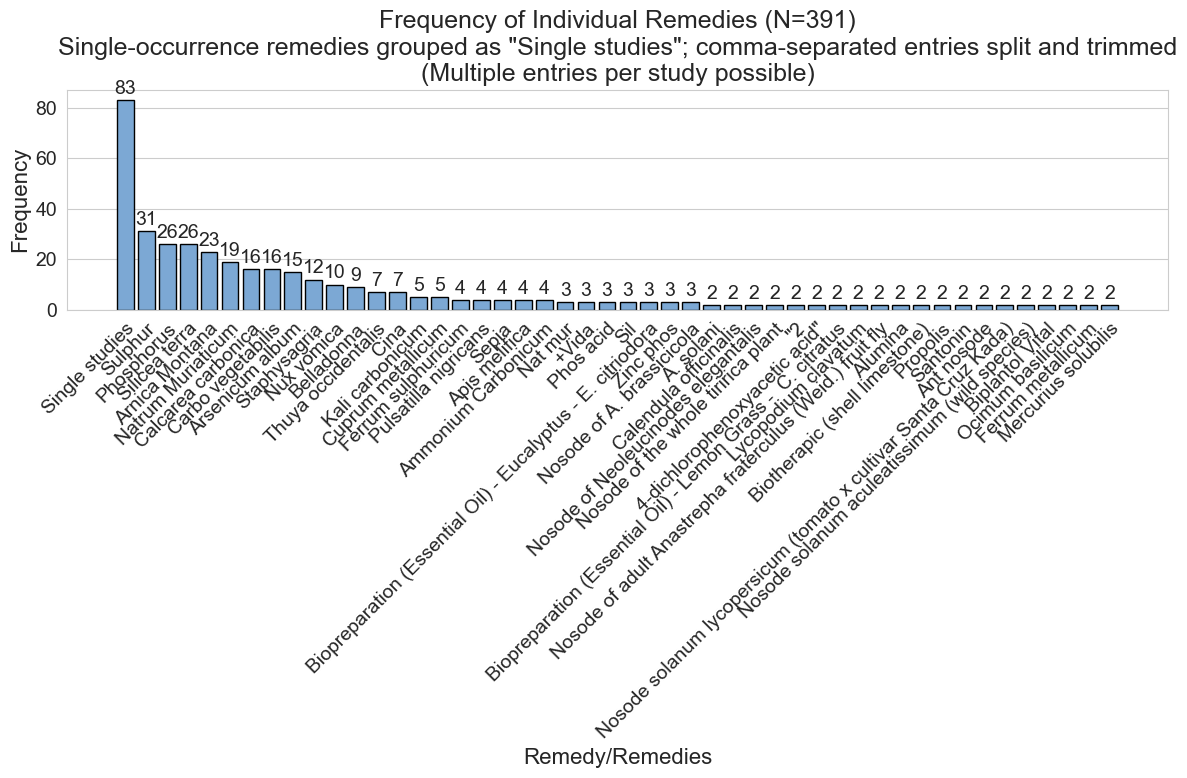

In [336]:
# Title: Frequency of Individual Remedies (with singletons grouped)
# Explanation:
# - This cell analyzes the 'Remedy/remedies ' column where multiple remedies may be listed per study, separated by commas.
# - It splits multi-valued cells, trims whitespace, and replaces empty tokens with 'Blank'.
# - Remedies that occur only once are grouped under a single category called 'Single studies' to simplify the chart.
# - The result is a bar chart showing remedy frequencies, saved as 'remedies_bar.png'.

# 1) Warn about empty remedy fields, then clean (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Remedy/remedies ']) or str(row['Remedy/remedies ']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty remedy field")

remedy_series_remedies = (
    df['Remedy/remedies ']
    .dropna()
    .astype(str)
    .str.strip()
)

# 2) Split comma-separated remedies, explode to one remedy per row, drop empty strings
remedy_exploded_remedies = (
    remedy_series_remedies
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
remedy_exploded_remedies = remedy_exploded_remedies[remedy_exploded_remedies != '']

# 3) Frequency counts by remedy
remedy_counts_remedies = remedy_exploded_remedies.value_counts()

# 4) Group singletons under "Single studies" to avoid a very long tail
lonely_mask_remedies = remedy_counts_remedies == 1
lonely_count_remedies = int(remedy_counts_remedies[lonely_mask_remedies].sum())
grouped_counts_remedies = remedy_counts_remedies[~lonely_mask_remedies].copy()
if lonely_count_remedies > 0:
    grouped_counts_remedies.loc['Single studies'] = lonely_count_remedies

# 5) Sort categories for plotting (descending by frequency)
grouped_counts_remedies = grouped_counts_remedies.sort_values(ascending=False)
total_n_remedies = int(grouped_counts_remedies.sum())  # total number of counted remedy entries

# 6) Create bar plot
fig_remedies, ax_remedies = plt.subplots(figsize=(12, 8))
bars = ax_remedies.bar(
    range(len(grouped_counts_remedies)),
    grouped_counts_remedies.values,
    edgecolor='black'
)

# 7) Axes labels and an informative, two-line title
ax_remedies.set_xticks(range(len(grouped_counts_remedies)))
ax_remedies.set_xticklabels(grouped_counts_remedies.index, rotation=45, ha='right', rotation_mode='anchor')
ax_remedies.set_xlabel('Remedy/Remedies')
ax_remedies.set_ylabel('Frequency')
ax_remedies.set_title(
    f'Frequency of Individual Remedies (N={total_n_remedies})\n'
    f'Single-occurrence remedies grouped as "Single studies"; '
    f'comma-separated entries split and trimmed\n(Multiple entries per study possible)',
    fontsize=TITLE_FS
)

# 8) Optional: annotate bars with their counts for readability
for i, v in enumerate(grouped_counts_remedies.values):
    if v > 0:
        ax_remedies.text(i, v + max(grouped_counts_remedies.values) * 0.01, str(v),
                         ha='center', va='bottom', fontsize=DATA_LABEL_FS)

# 9) Save and show
ax_remedies.xaxis.grid(False)
plt.tight_layout()
fig_remedies.savefig('remedies_bar.png', dpi=300, bbox_inches='tight')
plt.show()


### Remedies per Study

In [337]:
# - This cell analyzes how many distinct remedies are listed per study in the column 'Remedy/remedies '.
# - Each row is a study; entries may contain multiple remedies separated by commas.
# - We count remedies per study (0, 1, 2, ...) and visualize the distribution as a pie chart.
# - Labels are shown inside for larger slices and outside (with leader lines) for smaller slices for readability.
# - The chart title includes the total number of studies (N) considered.

def _count_remedies_per_study(cell: str) -> int:
    """
    Count the number of comma-separated remedies in a cell.
    Empty, NaN, or 'N/A' are treated as 0 remedies.
    """
    if pd.isna(cell) or str(cell).strip() in ['', 'N/A']:
        return 0
    parts = [p.strip() for p in str(cell).split(',') if p.strip()]
    return len(parts)


# 1) Compute number of remedies per study and their frequency distribution
remedies_per_study_counts = df['Remedy/remedies '].apply(_count_remedies_per_study)
remedies_per_study_freq = remedies_per_study_counts.value_counts().sort_index()

# 2) Prepare labels and values (grammatically correct singular/plural)
labels_remedies_per_study = [
    f'{count} remedies' if count != 1 else '1 remedy'
    for count in remedies_per_study_freq.index
]
values_remedies_per_study = remedies_per_study_freq.values.tolist()

# 3) Compute percentages and decide label position:
#    - outside for small slices (<9%), inside otherwise
total_remedies_per_study = sum(values_remedies_per_study)  # equals number of studies (N)
percentages_remedies_per_study = [
    (v / total_remedies_per_study) * 100 if total_remedies_per_study else 0
    for v in values_remedies_per_study
]
percentages_cutoff = 9
text_positions_remedies_per_study = [
    'outside' if p < percentages_cutoff else 'inside' for p in percentages_remedies_per_study
]
custom_text_remedies_per_study = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(labels_remedies_per_study, percentages_remedies_per_study, text_positions_remedies_per_study)
]

# 4) Build the pie chart
remedies_per_study_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels_remedies_per_study,
            values=values_remedies_per_study,
            text=custom_text_remedies_per_study,
            textinfo='text',
            textposition=text_positions_remedies_per_study,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

remedies_per_study_pie.update_traces(
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    insidetextfont=dict(color='black'),
)
 

# 5) Style and title (include N)
remedies_per_study_pie.update_layout(
    title=f'Number of Remedies per Study (N={total_remedies_per_study})',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

# 6) Display and export
remedies_per_study_pie.show()
remedies_per_study_pie.write_image('remedies_per_study_pie.png', width=800, height=600, scale=2)


### Country-Remedy Heatmap

Top 20 remedies: ['Sulphur', 'Silicea terra', 'Phosphorus', 'Arnica Montana', 'Natrum Muriaticum', 'Calcarea carbonica', 'Carbo vegetabilis', 'Arsenicum album', 'Staphysagria', 'Nux vomica', 'Belladonna', 'Cina', 'Thuya occidentalis', 'Cuprum metallicum', 'Kali carbonicum', 'Ferrum sulphuricum', 'Pulsatilla nigricans', 'Sepia', 'Apis melifica', 'Ammonium Carbonicum']
Created 247 country-remedy combinations


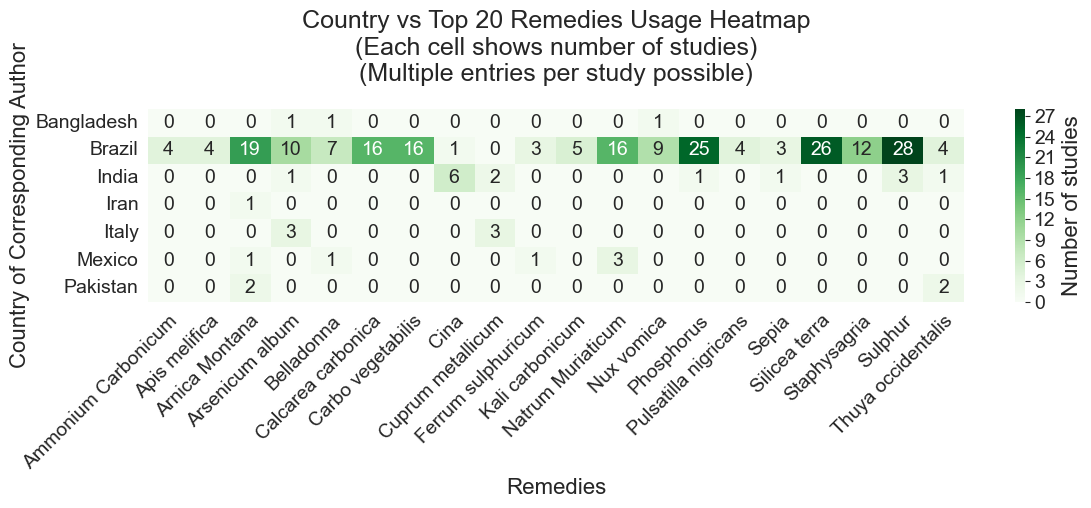

Heatmap includes:
- 7 countries
- 20 remedies (top 20)
- 247 total country-remedy combinations


In [338]:
# Country-remedy cross-tabulation heatmap — relationship between corresponding author country and remedy usage

# Warn about empty fields (all rows here are MIS >= 5, so NaN is a data issue)
for idx, row in df.iterrows():
    if pd.isna(row['Country of corresponding author']) or str(row['Country of corresponding author']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty country field")
    if pd.isna(row['Remedy/remedies ']) or str(row['Remedy/remedies ']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty remedy field")

# Clean country data (drop NaN, strip whitespace)
# TODO-RAWDATA: 'Parkistan' typo and 'Great Britain ' trailing space will be fixed in final data
country_series_heatmap = (
  df['Country of corresponding author']
  .dropna()
  .astype(str)
  .str.strip()
  .replace({'N/A': 'Unknown', 'Parkistan': 'Pakistan'})
)

# Clean remedy data (drop NaN, strip whitespace)
remedy_series_heatmap = (
  df['Remedy/remedies ']
  .dropna()
  .astype(str)
  .str.strip()
)

# Split comma-separated remedies into individual entries, drop empty strings from splitting
remedy_exploded_heatmap = (
  remedy_series_heatmap
  .str.split(',')
  .explode()
  .astype(str)
  .str.strip()
)
remedy_exploded_heatmap = remedy_exploded_heatmap[remedy_exploded_heatmap != '']

# Top 20 most frequent remedies
top_remedies = remedy_exploded_heatmap.value_counts().head(20).index.tolist()
print(f"Top 20 remedies: {top_remedies}")

# Build cross-tabulation: each row = one country-remedy pair from a study
# Only studies that have BOTH a country and remedy data contribute
valid_idx = country_series_heatmap.index.intersection(remedy_series_heatmap.index)
expanded_data = []
for idx in valid_idx:
    country = country_series_heatmap.loc[idx]
    remedy_cell = remedy_series_heatmap.loc[idx]
    remedies = [r.strip() for r in str(remedy_cell).split(',') if r.strip()]
    for remedy in remedies:
        if remedy in top_remedies:
            expanded_data.append({'Country': country, 'Remedy': remedy})

print(f"Created {len(expanded_data)} country-remedy combinations")

if len(expanded_data) == 0:
  print("No data found! Check if remedies match top_remedies list.")
else:
  expanded_df = pd.DataFrame(expanded_data)

  # Create cross-tabulation matrix
  heatmap_matrix = pd.crosstab(expanded_df['Country'], expanded_df['Remedy'])

  # Create heatmap visualization
  fig_heatmap, ax_heatmap = plt.subplots(figsize=hmap_figsize(*heatmap_matrix.shape))

  import seaborn as sns
  sns.heatmap(
      heatmap_matrix,
      annot=True,
      fmt='d',
      cmap='Greens',
      ax=ax_heatmap,
      annot_kws={'size': HMAP_ANNOT_FS},
      cbar_kws={'label': 'Number of studies'}
  )

  ax_heatmap.set_title('Country vs Top 20 Remedies Usage Heatmap\n(Each cell shows number of studies)\n(Multiple entries per study possible)', fontsize=TITLE_FS, pad=20)
  ax_heatmap.tick_params(axis='both', labelsize=HMAP_TICK_FS)
  ax_heatmap.set_xlabel('Remedies', fontsize=AXIS_LABEL_FS)
  ax_heatmap.set_ylabel('Country of Corresponding Author', fontsize=AXIS_LABEL_FS)

  ax_heatmap.set_xticks([i + 0.5 for i in range(len(heatmap_matrix.columns))])
  ax_heatmap.set_xticklabels(heatmap_matrix.columns, rotation=45, ha='right', rotation_mode='anchor')
  ax_heatmap.set_yticks([i + 0.5 for i in range(len(heatmap_matrix.index))])
  ax_heatmap.set_yticklabels(heatmap_matrix.index, rotation=0)

  plt.tight_layout()
  fix_hmap_cbar(fig_heatmap, ax_heatmap)
  fig_heatmap.savefig('country_remedy_heatmap.png', dpi=300, bbox_inches='tight')
  plt.show()

  print(f"Heatmap includes:")
  print(f"- {len(heatmap_matrix.index)} countries")
  print(f"- {len(heatmap_matrix.columns)} remedies (top 20)")
  print(f"- {heatmap_matrix.values.sum()} total country-remedy combinations")

### Country-Remedy Clustered Heatmap (disabled)

In [339]:
# # Create hierarchical clustered heatmap with country normalization
# # Normalize each country (row) so values represent proportion of that country's total remedy usage
#
# # Normalize the heatmap matrix by row (each country's values sum to 1)
# heatmap_normalized = heatmap_matrix.div(heatmap_matrix.sum(axis=1), axis=0)
#
# # Replace any NaN values (from countries with no remedies) with 0
# heatmap_normalized = heatmap_normalized.fillna(0)
#
# # Create clustered heatmap with hierarchical clustering on both axes
#
# # Create the clustermap (hierarchical clustering on both rows and columns)
# clustered_fig = sns.clustermap(
#     heatmap_normalized,
#     cmap='Greens',
#     annot=True,  # Show values in cells
#     fmt='.2f',   # Format as proportion with 2 decimal places
#     figsize=(16, 10),
#     cbar_kws={'label': 'Proportion of country total'},
#     linewidths=0.5,
#     linecolor='white',
#     method='average',  # Linkage method for hierarchical clustering
#     metric='euclidean'  # Distance metric
# )
#
# # Customize the plot title
# clustered_fig.fig.suptitle(
#     'Country vs Top 20 Remedies - Hierarchical Clustering (Normalized by Country)\n(Each cell shows proportion of that country\'s total remedy usage)',
#     fontsize=14,
#     y=0.98
# )
#
# # Adjust layout and save
# plt.tight_layout()
# clustered_fig.savefig('country_remedy_heatmap_clustered_normalized.png', dpi=300, bbox_inches='tight')
# plt.show()
#
# # Print summary
# print(f"\nClustered heatmap created:")
# print(f"- Hierarchical clustering applied to both countries and remedies")
# print(f"- Each row normalized to show proportion of that country's total")
# print(f"- Values range from 0.00 to 1.00 (0% to 100%)")


### Remedy Co-occurrence Heatmap

Found 94 studies with multiple remedies
Top 15 remedies in multi-remedy studies: ['Sulphur', 'Silicea terra', 'Phosphorus', 'Arnica Montana', 'Carbo vegetabilis', 'Calcarea carbonica', 'Arsenicum album', 'Natrum Muriaticum', 'Staphysagria', 'Belladonna', 'Nux vomica', 'Thuya occidentalis', 'Cuprum metallicum', 'Apis melifica', 'Kali carbonicum']


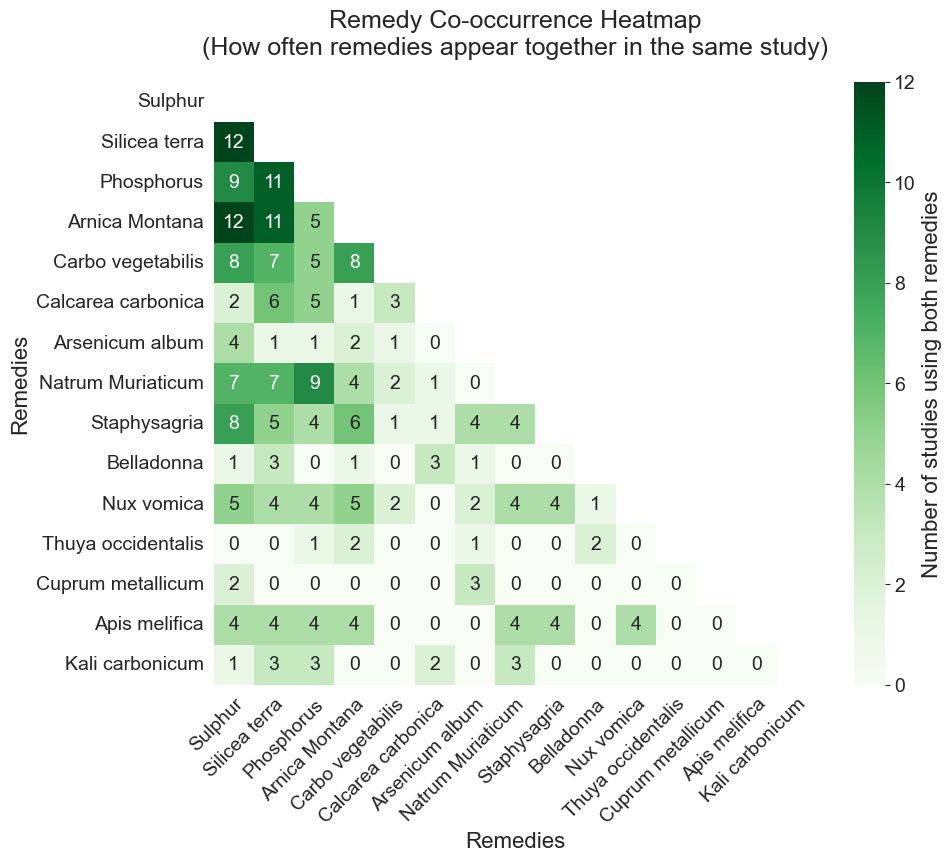

Co-occurrence heatmap includes:
- 15 top remedies from multi-remedy studies
- 94 studies with multiple remedies
- 268 total remedy pair co-occurrences

Top 10 remedy co-occurrences:
- Sulphur + Silicea terra: 12 studies
- Sulphur + Arnica Montana: 12 studies
- Silicea terra + Phosphorus: 11 studies
- Silicea terra + Arnica Montana: 11 studies
- Sulphur + Phosphorus: 9 studies
- Phosphorus + Natrum Muriaticum: 9 studies
- Sulphur + Carbo vegetabilis: 8 studies
- Sulphur + Staphysagria: 8 studies
- Arnica Montana + Carbo vegetabilis: 8 studies
- Sulphur + Natrum Muriaticum: 7 studies


In [340]:
  # Create remedy co-occurrence heatmap analysis - this shows which remedies are frequently used together in the same studies

  # Warn about empty remedy fields, then clean
  for idx, row in df.iterrows():
      if pd.isna(row['Remedy/remedies ']) or str(row['Remedy/remedies ']).strip() == '':
          print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty remedy field")

  remedy_series_cooccur = (
      df['Remedy/remedies ']
      .dropna()
      .astype(str)
      .str.strip()
  )

  # Get studies with multiple remedies only
  multi_remedy_studies = []
  for idx in remedy_series_cooccur.index:
      remedy_cell = remedy_series_cooccur.loc[idx]

      # Split remedies and clean them
      remedies = [r.strip() for r in str(remedy_cell).split(',') if r.strip()]

      # Only include studies with 2 or more remedies
      if len(remedies) > 1:
          multi_remedy_studies.append(remedies)

  print(f"Found {len(multi_remedy_studies)} studies with multiple remedies")

  # Get top remedies from multi-remedy studies to focus the heatmap
  all_remedies_multi = []
  for study_remedies in multi_remedy_studies:
      all_remedies_multi.extend(study_remedies)

  # Get top 15 most frequent remedies in multi-remedy studies (smaller number for readability)
  top_remedies_cooccur = pd.Series(all_remedies_multi).value_counts().head(15).index.tolist()
  print(f"Top 15 remedies in multi-remedy studies: {top_remedies_cooccur}")

  # Create co-occurrence matrix - count how often each pair appears together
  import numpy as np
  cooccur_matrix = pd.DataFrame(0, index=top_remedies_cooccur, columns=top_remedies_cooccur)

  # Fill the co-occurrence matrix
  for study_remedies in multi_remedy_studies:
      # Filter to only include top remedies
      study_top_remedies = [r for r in study_remedies if r in top_remedies_cooccur]

      # For each pair of remedies in this study, increment the count
      for i, remedy1 in enumerate(study_top_remedies):
          for j, remedy2 in enumerate(study_top_remedies):
              if i != j:  # Don't count a remedy with itself
                  cooccur_matrix.loc[remedy1, remedy2] += 1

  # Make the matrix symmetric (if A appears with B, then B appears with A)
  cooccur_matrix = (cooccur_matrix + cooccur_matrix.T) // 2

  # Column order matches row order (most frequent remedy at top-left)

  # Mask the upper triangle (including the diagonal, which is always 0 since a
  # remedy is never counted as co-occurring with itself). The matrix was just
  # forced symmetric above, so the lower and upper triangles are identical —
  # showing both is pure redundancy. np.triu with the default k=0 flags the
  # diagonal too, so it gets hidden along with the upper triangle.
  cooccur_mask = np.triu(np.ones_like(cooccur_matrix, dtype=bool))

  # Create heatmap visualization
  fig_cooccur, ax_cooccur = plt.subplots(figsize=hmap_figsize(*cooccur_matrix.shape))

  # Use seaborn for professional heatmap
  import seaborn as sns
  sns.heatmap(
      cooccur_matrix,
      mask=cooccur_mask,  # Hide the redundant upper triangle + diagonal
      annot=True,  # Show numbers in cells
      fmt='d',     # Integer format
      cmap='Greens',  # Blue color scheme for co-occurrence
      ax=ax_cooccur,
      annot_kws={'size': HMAP_ANNOT_FS},
      cbar_kws={'label': 'Number of studies using both remedies'},
      square=True  # Make cells square for better symmetry visualization
  )

  # Center ticks and labels in the middle of each cell
  ax_cooccur.set_xticks([i + 0.5 for i in range(len(cooccur_matrix.columns))])
  ax_cooccur.set_xticklabels(cooccur_matrix.columns, rotation=45, ha='right', rotation_mode='anchor')
  ax_cooccur.set_yticks([i + 0.5 for i in range(len(cooccur_matrix.index))])
  ax_cooccur.set_yticklabels(cooccur_matrix.index, rotation=0)

  # Customize the plot
  # (No invert_yaxis() here — the default row-0-at-top orientation is what
  # puts the visible lower triangle in the lower-left, matching every other
  # heatmap in this notebook.)
  ax_cooccur.set_title('Remedy Co-occurrence Heatmap\n(How often remedies appear together in the same study)', fontsize=TITLE_FS, pad=20)
  ax_cooccur.tick_params(axis='both', labelsize=HMAP_TICK_FS)
  ax_cooccur.set_xlabel('Remedies', fontsize=AXIS_LABEL_FS)
  ax_cooccur.set_ylabel('Remedies', fontsize=AXIS_LABEL_FS)
  ax_cooccur.xaxis.grid(False)
  ax_cooccur.yaxis.grid(False)

  # Save and display
  plt.tight_layout()
  fix_hmap_cbar(fig_cooccur, ax_cooccur)
  fig_cooccur.savefig('remedy_cooccurrence_heatmap.png', dpi=300, bbox_inches='tight')
  plt.show()

  # Print summary statistics
  total_cooccurrences = cooccur_matrix.values.sum() // 2  # Divide by 2 since matrix is symmetric
  print(f"Co-occurrence heatmap includes:")
  print(f"- {len(cooccur_matrix.index)} top remedies from multi-remedy studies")
  print(f"- {len(multi_remedy_studies)} studies with multiple remedies")
  print(f"- {total_cooccurrences} total remedy pair co-occurrences")

  # Show top co-occurring pairs
  cooccur_pairs = []
  for i in range(len(cooccur_matrix)):
      for j in range(i+1, len(cooccur_matrix)):  # Only upper triangle to avoid duplicates
          remedy1 = cooccur_matrix.index[i]
          remedy2 = cooccur_matrix.columns[j]
          count = cooccur_matrix.iloc[i, j]
          if count > 0:
              cooccur_pairs.append((remedy1, remedy2, count))

  cooccur_pairs.sort(key=lambda x: x[2], reverse=True)
  print(f"\nTop 10 remedy co-occurrences:")
  for remedy1, remedy2, count in cooccur_pairs[:10]:
      print(f"- {remedy1} + {remedy2}: {count} studies")



### Remedy-Crop Heatmap

  RAWDATA CLEANUP NEEDED: Covidence #5109 has empty crop field
  RAWDATA CLEANUP NEEDED: Covidence #11703 has empty crop field
  RAWDATA CLEANUP NEEDED: Covidence #11860 has empty crop field
Top 20 remedies: ['Sulphur', 'Silicea terra', 'Phosphorus', 'Arnica Montana', 'Natrum Muriaticum', 'Calcarea carbonica', 'Carbo vegetabilis', 'Arsenicum album', 'Staphysagria', 'Nux vomica', 'Belladonna', 'Cina', 'Thuya occidentalis', 'Cuprum metallicum', 'Kali carbonicum', 'Ferrum sulphuricum', 'Pulsatilla nigricans', 'Sepia', 'Apis melifica', 'Ammonium Carbonicum']
Top 20 crops: ['Tomato', 'Bean', 'Soybean', 'Onion', 'Lettuce', 'Mulberry', 'Strawberry', 'Chamomile', 'Cabbage', 'Tiririca', 'Artemisia', 'Cowpea', 'Cauliflower', 'Carqueja', 'Guamxuma', 'Grapewine', 'Fig', 'Naranjilla', 'Sisal', 'Broccoli']
Created 145 remedy-crop combinations


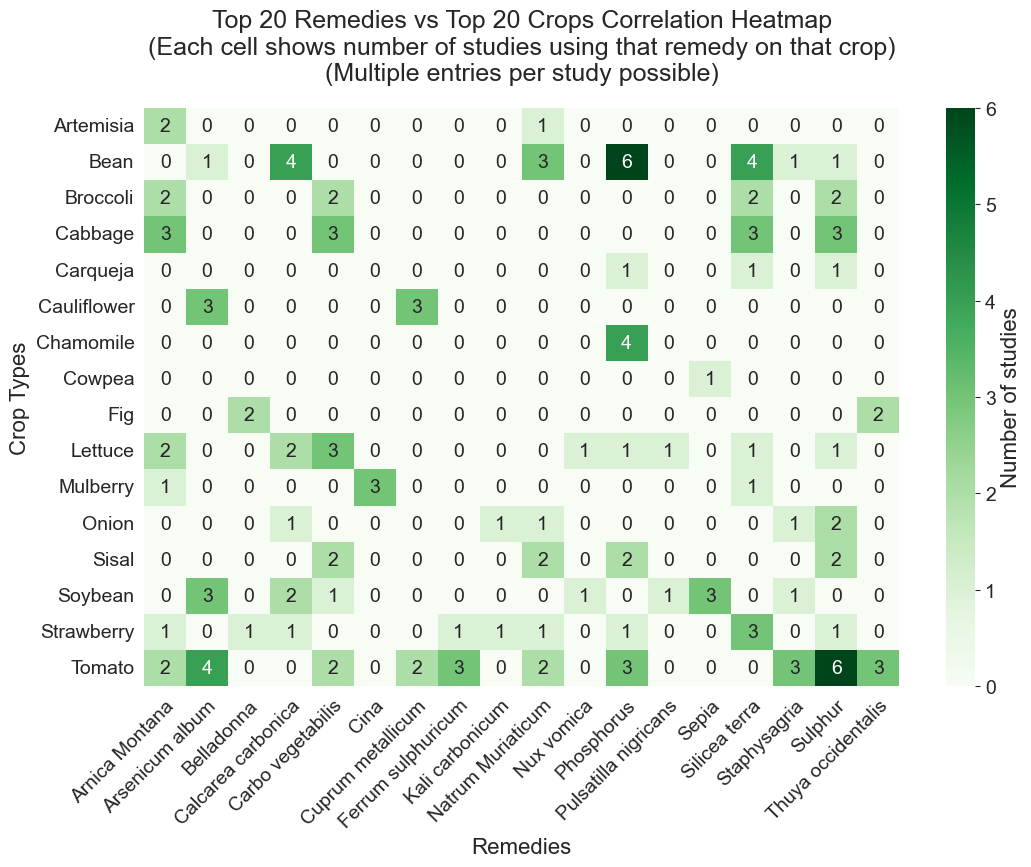

Remedy-crop correlation heatmap includes:
- 16 crop types (top 20)
- 18 remedies (top 20)
- 145 total remedy-crop study combinations

Top 10 remedy-crop combinations:
- Phosphorus on Bean: 6 studies
- Sulphur on Tomato: 6 studies
- Calcarea carbonica on Bean: 4 studies
- Silicea terra on Bean: 4 studies
- Phosphorus on Chamomile: 4 studies
- Arsenicum album on Tomato: 4 studies
- Natrum Muriaticum on Bean: 3 studies
- Arnica Montana on Cabbage: 3 studies
- Carbo vegetabilis on Cabbage: 3 studies
- Silicea terra on Cabbage: 3 studies


In [341]:
  # Cross-Category Heatmap: Top 20 Remedies vs Top 20 Crops
  # This code creates a heatmap showing which remedies are used on which crop types. We'll focus on the top 20 most frequent remedies and top 20 most frequent crops to identify patterns in remedy-crop combinations.

  # Create remedy-crop cross-correlation heatmap analysis - this shows which remedies are used on which crop types

  # Warn about empty fields (all rows are MIS >= 5)
  for idx, row in df.iterrows():
      if pd.isna(row['Remedy/remedies ']) or str(row['Remedy/remedies ']).strip() == '':
          print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty remedy field")
      if pd.isna(row['Crop type studied']) or str(row['Crop type studied']).strip() == '':
          print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty crop field")

  # Clean remedy data
  remedy_series_crop = (
      df['Remedy/remedies ']
      .dropna()
      .astype(str)
      .str.strip()
  )

  # Split comma-separated remedies, drop empty strings
  remedy_exploded_crop = (
      remedy_series_crop
      .str.split(',')
      .explode()
      .astype(str)
      .str.strip()
  )
  remedy_exploded_crop = remedy_exploded_crop[remedy_exploded_crop != '']

  # Clean crop data
  crop_series_remedy = (
      df['Crop type studied']
      .dropna()
      .astype(str)
      .str.strip()
  )

  # Top 20 of each
  top_20_remedies = remedy_exploded_crop.value_counts().head(20).index.tolist()
  top_20_crops = crop_series_remedy.value_counts().head(20).index.tolist()

  print(f"Top 20 remedies: {top_20_remedies}")
  print(f"Top 20 crops: {top_20_crops}")

  # Create expanded dataframe for cross-tabulation — only rows with both valid crop and remedy
  valid_idx_rc = crop_series_remedy.index.intersection(remedy_series_crop.index)
  expanded_remedy_crop = []
  for idx in valid_idx_rc:
      crop = crop_series_remedy.loc[idx]
      remedy_cell = remedy_series_crop.loc[idx]

      # Skip if crop is not in top 20
      if crop not in top_20_crops:
          continue

      remedies = str(remedy_cell).split(',')

      # Add each remedy from this study as a separate entry
      for remedy in remedies:
          remedy_clean = remedy.strip()
          if remedy_clean and remedy_clean in top_20_remedies:
              expanded_remedy_crop.append({'Crop': crop, 'Remedy': remedy_clean})

  print(f"Created {len(expanded_remedy_crop)} remedy-crop combinations")

  # Check if we have data before proceeding
  if len(expanded_remedy_crop) == 0:
      print("No data found! Check if remedies and crops match top lists.")
  else:
      expanded_remedy_crop_df = pd.DataFrame(expanded_remedy_crop)

      # Create cross-tabulation matrix (crops as rows, remedies as columns)
      remedy_crop_matrix = pd.crosstab(expanded_remedy_crop_df['Crop'], expanded_remedy_crop_df['Remedy'])

      # Create heatmap visualization
      fig_remedy_crop, ax_remedy_crop = plt.subplots(figsize=hmap_figsize(*remedy_crop_matrix.shape))

      # Use seaborn for professional heatmap
      import seaborn as sns
      sns.heatmap(
          remedy_crop_matrix,
          annot=True,  # Show numbers in cells
          fmt='d',     # Integer format
          cmap='Greens',  # Green color scheme for crop-remedy correlation
          ax=ax_remedy_crop,
          cbar_kws={'label': 'Number of studies'},
          annot_kws={'size': HMAP_ANNOT_FS}  # Smaller annotation text due to large matrix
      )

      # Center ticks and labels in the middle of each cell
      ax_remedy_crop.set_xticks([i + 0.5 for i in range(len(remedy_crop_matrix.columns))])
      ax_remedy_crop.set_xticklabels(remedy_crop_matrix.columns, rotation=45, ha='right', rotation_mode='anchor')
      ax_remedy_crop.set_yticks([i + 0.5 for i in range(len(remedy_crop_matrix.index))])
      ax_remedy_crop.set_yticklabels(remedy_crop_matrix.index, rotation=0)

      # Customize the plot
      ax_remedy_crop.set_title('Top 20 Remedies vs Top 20 Crops Correlation Heatmap\n(Each cell shows number of studies using that remedy on that crop)\n(Multiple entries per study possible)', fontsize=TITLE_FS, pad=20)
      ax_remedy_crop.tick_params(axis='both', labelsize=HMAP_TICK_FS)
      ax_remedy_crop.set_xlabel('Remedies', fontsize=AXIS_LABEL_FS)
      ax_remedy_crop.set_ylabel('Crop Types', fontsize=AXIS_LABEL_FS)

      # Save and display
      plt.tight_layout()
      fix_hmap_cbar(fig_remedy_crop, ax_remedy_crop)
      fig_remedy_crop.savefig('remedy_crop_correlation_heatmap.png', dpi=300, bbox_inches='tight')
      plt.show()

      # Print summary statistics
      total_combinations = remedy_crop_matrix.values.sum()
      print(f"Remedy-crop correlation heatmap includes:")
      print(f"- {len(remedy_crop_matrix.index)} crop types (top 20)")
      print(f"- {len(remedy_crop_matrix.columns)} remedies (top 20)")
      print(f"- {total_combinations} total remedy-crop study combinations")

      # Extract and rank all remedy-crop combinations from the matrix for summary analysis
      remedy_crop_pairs = []
      # Loop through each row (crop) in the matrix
      for i in range(len(remedy_crop_matrix)):
          # Loop through each column (remedy) in the matrix
          for j in range(len(remedy_crop_matrix.columns)):
              crop = remedy_crop_matrix.index[i]  # Get crop name from row index
              remedy = remedy_crop_matrix.columns[j]  # Get remedy name from column index
              count = remedy_crop_matrix.iloc[i, j]  # Get the count value from this cell
              if count > 0:  # Only include combinations that actually occurred
                  remedy_crop_pairs.append((crop, remedy, count))

      # Sort by count (highest first) to show most frequent combinations
      remedy_crop_pairs.sort(key=lambda x: x[2], reverse=True)
      print(f"\nTop 10 remedy-crop combinations:")
      for crop, remedy, count in remedy_crop_pairs[:10]:
          print(f"- {remedy} on {crop}: {count} studies")



### Remedy-Crop Heatmap (frequency-sorted)

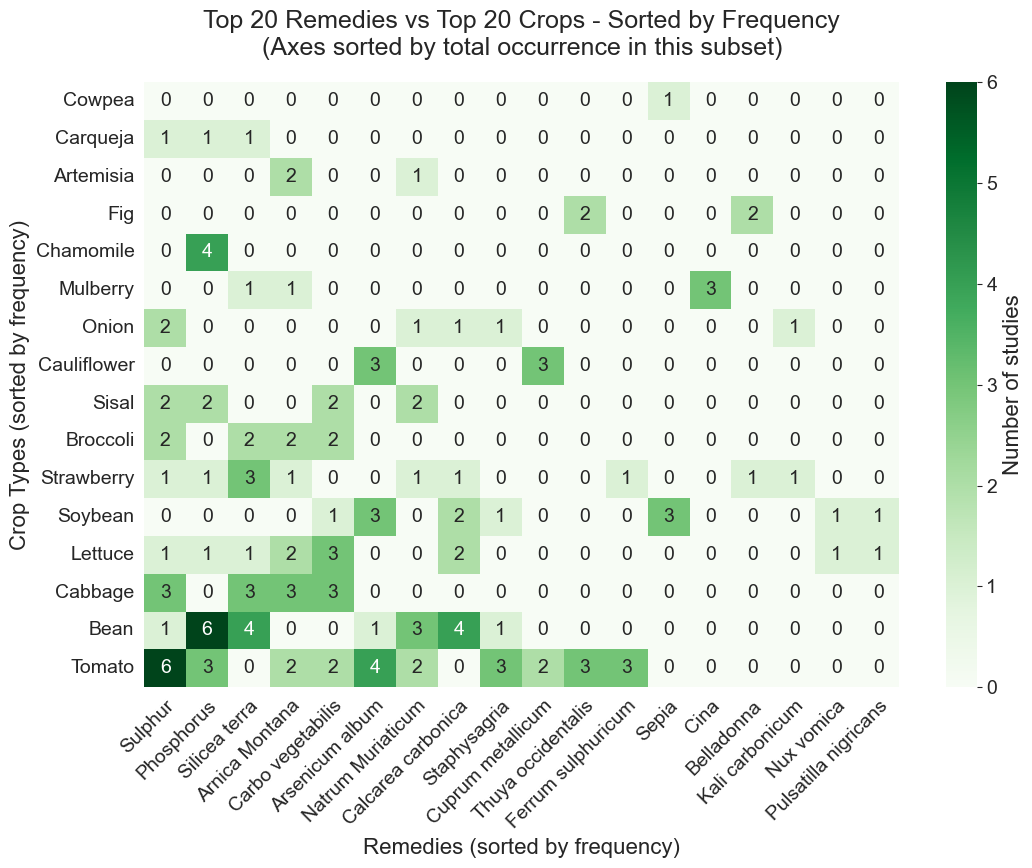


Crop frequency ranking (in top 20 subset):
1. Tomato: 30 studies
2. Bean: 20 studies
3. Cabbage: 12 studies
4. Lettuce: 12 studies
5. Soybean: 12 studies
6. Strawberry: 11 studies
7. Broccoli: 8 studies
8. Sisal: 8 studies
9. Cauliflower: 6 studies
10. Onion: 6 studies
11. Mulberry: 5 studies
12. Chamomile: 4 studies
13. Fig: 4 studies
14. Artemisia: 3 studies
15. Carqueja: 3 studies
16. Cowpea: 1 studies

Remedy frequency ranking (in top 20 subset):
1. Sulphur: 19 studies
2. Phosphorus: 18 studies
3. Silicea terra: 15 studies
4. Arnica Montana: 13 studies
5. Carbo vegetabilis: 13 studies
6. Arsenicum album: 11 studies
7. Natrum Muriaticum: 10 studies
8. Calcarea carbonica: 10 studies
9. Staphysagria: 6 studies
10. Cuprum metallicum: 5 studies
11. Thuya occidentalis: 5 studies
12. Ferrum sulphuricum: 4 studies
13. Sepia: 4 studies
14. Cina: 3 studies
15. Belladonna: 3 studies
16. Kali carbonicum: 2 studies
17. Nux vomica: 2 studies
18. Pulsatilla nigricans: 2 studies


In [342]:
# Create frequency-sorted version of remedy-crop heatmap
# Both axes sorted by total occurrence in the top 20 subset

# Sort crops (rows) by total frequency across all remedies
crop_totals = remedy_crop_matrix.sum(axis=1).sort_values(ascending=False)
sorted_crops = crop_totals.index.tolist()[::-1]  # reverse: most common at bottom

# Sort remedies (columns) by total frequency across all crops
remedy_totals = remedy_crop_matrix.sum(axis=0).sort_values(ascending=False)
sorted_remedies = remedy_totals.index.tolist()

# Reindex the matrix with sorted axes
remedy_crop_sorted = remedy_crop_matrix.loc[sorted_crops, sorted_remedies]

# Create heatmap visualization
fig_sorted, ax_sorted = plt.subplots(figsize=hmap_figsize(*remedy_crop_sorted.shape))

sns.heatmap(
    remedy_crop_sorted,
    annot=True,  # Show numbers in cells
    fmt='d',     # Integer format
    cmap='Greens',  # Green color scheme
    ax=ax_sorted,
    cbar_kws={'label': 'Number of studies'},
    annot_kws={'size': HMAP_ANNOT_FS}  # Smaller annotation text
)

# Center ticks and labels
ax_sorted.set_xticks([i + 0.5 for i in range(len(remedy_crop_sorted.columns))])
ax_sorted.set_xticklabels(remedy_crop_sorted.columns, rotation=45, ha='right', rotation_mode='anchor')
ax_sorted.set_yticks([i + 0.5 for i in range(len(remedy_crop_sorted.index))])
ax_sorted.set_yticklabels(remedy_crop_sorted.index, rotation=0)

# Customize the plot
ax_sorted.set_title(
    'Top 20 Remedies vs Top 20 Crops - Sorted by Frequency\n(Axes sorted by total occurrence in this subset)',
    fontsize=TITLE_FS,
    pad=20
)
ax_sorted.tick_params(axis='both', labelsize=HMAP_TICK_FS)
ax_sorted.set_xlabel('Remedies (sorted by frequency)', fontsize=AXIS_LABEL_FS)
ax_sorted.set_ylabel('Crop Types (sorted by frequency)', fontsize=AXIS_LABEL_FS)

# Save and display
plt.tight_layout()
fix_hmap_cbar(fig_sorted, ax_sorted)
fig_sorted.savefig('remedy_crop_correlation_heatmap_sorted.png', dpi=300, bbox_inches='tight')
plt.show()

# Print frequency rankings
print(f"\nCrop frequency ranking (in top 20 subset):")
for i, (crop, count) in enumerate(crop_totals.items(), 1):
    print(f"{i}. {crop}: {count} studies")

print(f"\nRemedy frequency ranking (in top 20 subset):")
for i, (remedy, count) in enumerate(remedy_totals.items(), 1):
    print(f"{i}. {remedy}: {count} studies")


## Potency Level Analysis

### Potency Level Distribution

  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty potency levels field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty potency levels field


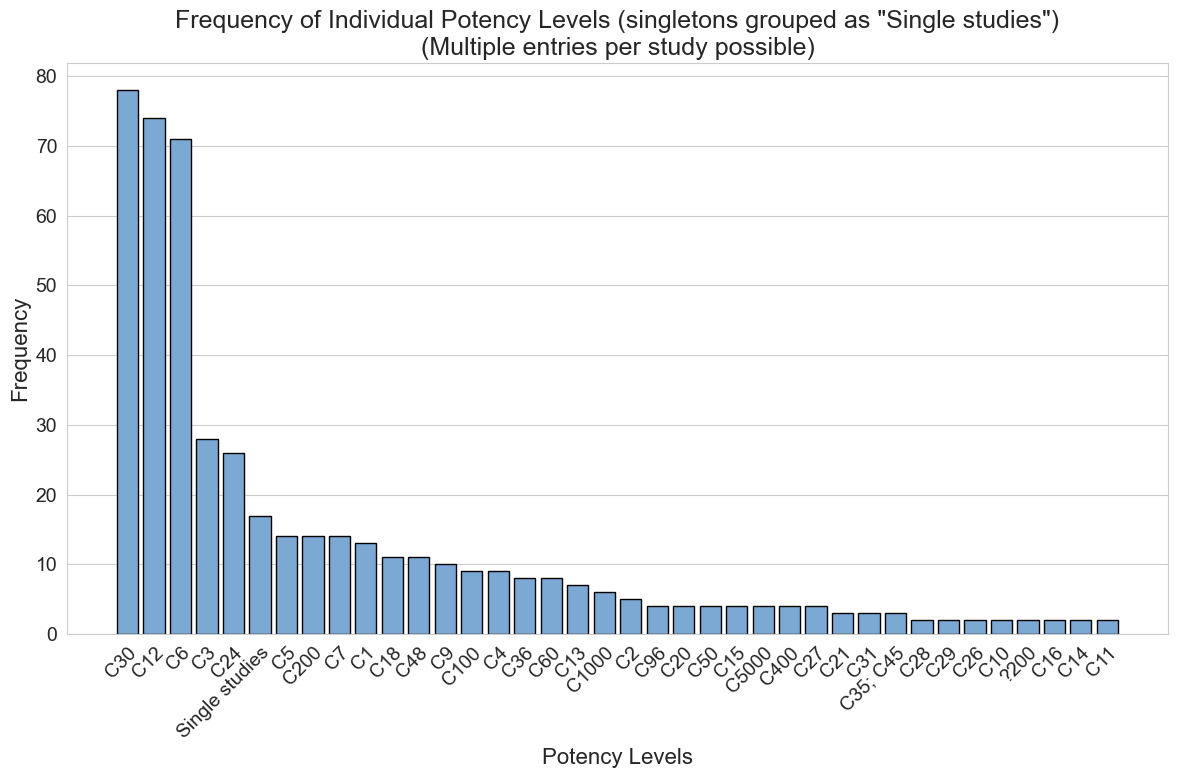

In [343]:
# Potency Levels Bar Chart Analysis

# This code analyzes the distribution of homeopathic potency levels used in studies. We'll split comma-separated entries, group singletons as "Single studies", and create a bar chart showing frequency of each potency level.

# Create potency levels frequency analysis with comma separation and singleton grouping - this shows which potency levels are most commonly used in studies

# Warn about empty potency fields (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Potency levels']) or str(row['Potency levels']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty potency levels field")
    elif 'N/A' in str(row['Potency levels']):
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has 'N/A' in potency levels — needs real label")

# Clean and split the 'Potency levels' column on commas
potency_series_levels = (
    df['Potency levels']
    .dropna()
    .astype(str)
    .str.strip()
)

# Split on comma, explode into individual entries, drop empty strings
potency_exploded_levels = (
    potency_series_levels
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
potency_exploded_levels = potency_exploded_levels[potency_exploded_levels != '']

# Get frequency counts
potency_counts_levels = potency_exploded_levels.value_counts()

# Group all singletons under "Single studies"
lonely_mask_levels = potency_counts_levels == 1
lonely_count_levels = int(potency_counts_levels[lonely_mask_levels].sum())
grouped_counts_levels = potency_counts_levels[~lonely_mask_levels].copy()

if lonely_count_levels > 0:
    grouped_counts_levels.loc['Single studies'] = lonely_count_levels

# Sort for plotting
grouped_counts_levels = grouped_counts_levels.sort_values(ascending=False)

# Create bar plot using matplotlib directly for proper axis alignment
fig_levels, ax_levels = plt.subplots(figsize=(12, 8))
bars = ax_levels.bar(range(len(grouped_counts_levels)), grouped_counts_levels.values, edgecolor='black')
ax_levels.set_xticks(range(len(grouped_counts_levels)))
ax_levels.set_xticklabels(grouped_counts_levels.index, rotation=45, ha='right', rotation_mode='anchor', fontsize=TICK_FS)
ax_levels.set_xlabel('Potency Levels', fontsize=AXIS_LABEL_FS)
ax_levels.set_ylabel('Frequency', fontsize=AXIS_LABEL_FS)
ax_levels.set_title('Frequency of Individual Potency Levels (singletons grouped as "Single studies")\n(Multiple entries per study possible)', fontsize=TITLE_FS)

# Save and show
ax_levels.xaxis.grid(False)
plt.tight_layout()
fig_levels.savefig('potency_levels_bar.png', dpi=300, bbox_inches='tight')
plt.show()


### Potency Levels per Study

In [344]:

# Count how many potency levels each study (row) has before comma separation
def _count_potency_levels_per_study(cell: str) -> int:
    # NaN or empty = 0 potency levels (warnings printed in potency bar chart cell)
    if pd.isna(cell) or str(cell).strip() == '':
        return 0
    parts = [p.strip() for p in str(cell).split(',') if p.strip()]
    return len(parts)


potency_levels_per_study_counts = df['Potency levels'].apply(_count_potency_levels_per_study)
potency_levels_per_study_freq = potency_levels_per_study_counts.value_counts().sort_index()

# Prepare data for pie chart
labels_potency_levels_per_study = [f'{count} potency levels' if count != 1 else '1 potency level' for count in
                                   potency_levels_per_study_freq.index]
values_potency_levels_per_study = potency_levels_per_study_freq.values.tolist()

# Compute percentages and set label positions
total_potency_levels_per_study = sum(values_potency_levels_per_study)
percentages_potency_levels_per_study = [
    (v / total_potency_levels_per_study) * 100 if total_potency_levels_per_study else 0 for v in
    values_potency_levels_per_study]
percentages_cutoff = 10
text_positions_potency_levels_per_study = ['outside' if p < percentages_cutoff else 'inside' for p in
                                           percentages_potency_levels_per_study]
custom_text_potency_levels_per_study = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in
    zip(labels_potency_levels_per_study, percentages_potency_levels_per_study, text_positions_potency_levels_per_study)
]

# Build pie chart (styled like the "Country of corresponding author" chart)
potency_levels_per_study_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels_potency_levels_per_study,
            values=values_potency_levels_per_study,
            text=custom_text_potency_levels_per_study,
            textinfo='text',
            textposition=text_positions_potency_levels_per_study,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

potency_levels_per_study_pie.update_traces(
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=PLOTLY_TEXT_FS, color='black'),
potency_levels_per_study_pie.update_layout(
    title='Number of potency levels per study',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

potency_levels_per_study_pie.show()
potency_levels_per_study_pie.write_image('potency_levels_per_study_pie.png', width=800, height=600, scale=2)


### Remedy-Potency Heatmap

  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty potency field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty potency field
Top 20 remedies: ['Sulphur', 'Silicea terra', 'Phosphorus', 'Arnica Montana', 'Natrum Muriaticum', 'Calcarea carbonica', 'Carbo vegetabilis', 'Arsenicum album', 'Staphysagria', 'Nux vomica', 'Belladonna', 'Cina', 'Thuya occidentalis', 'Cuprum metallicum', 'Kali carbonicum', 'Ferrum sulphuricum', 'Pulsatilla nigricans', 'Sepia', 'Apis melifica', 'Ammonium Carbonicum']
Top 20 potency levels: ['C30', 'C12', 'C6', 'C3', 'C24', 'C200', 'C5', 'C7', 'C1', 'C18', 'C48', 'C9', 'C100', 'C4', 'C60', 'C36', 'C13', 'C1000', 'C2', 'C27']
Created 672 remedy-potency combinations


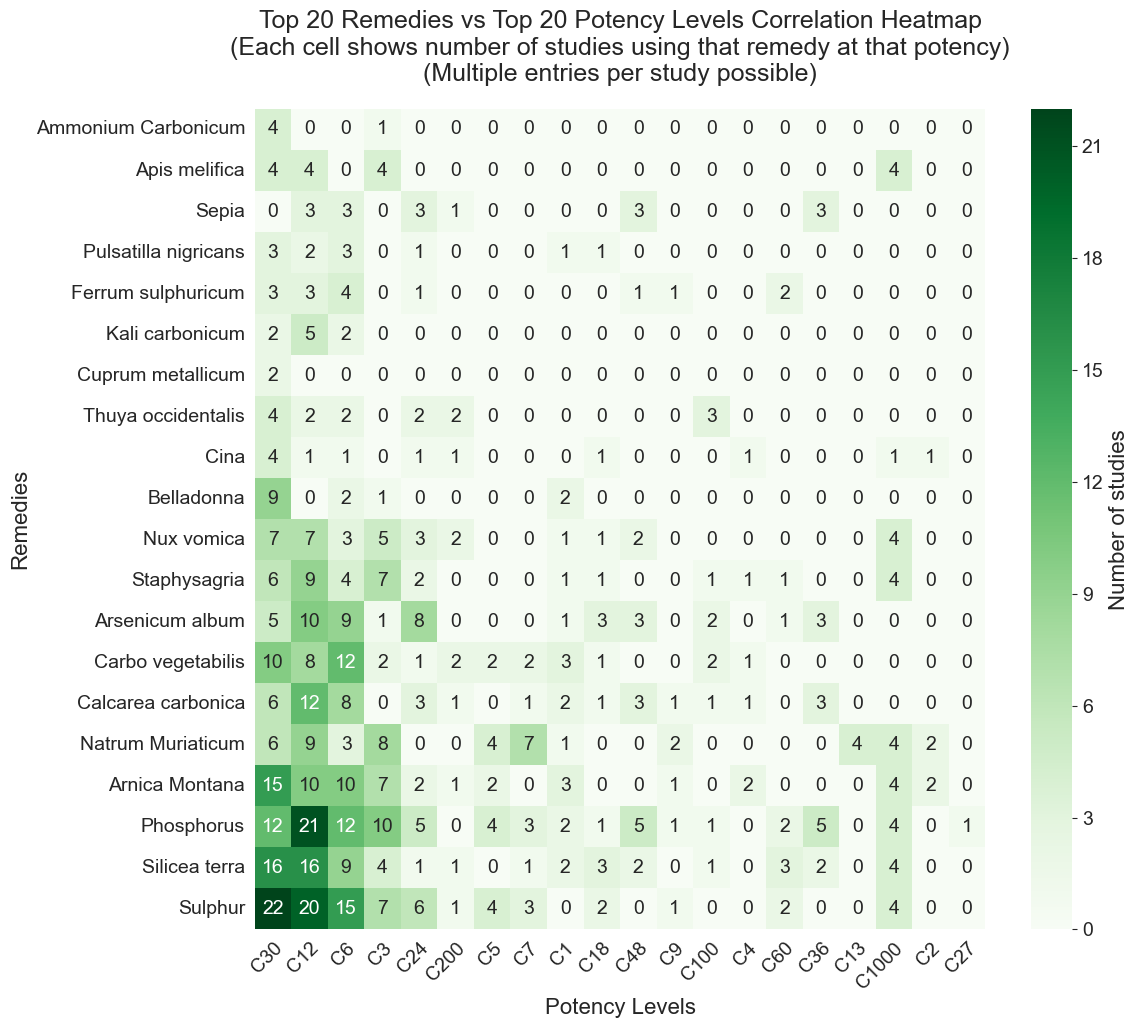

Remedy-potency correlation heatmap includes:
- 20 remedies (top 20)
- 20 potency levels (top 20)
- 672 total remedy-potency study combinations

Top 10 remedy-potency combinations:
- Sulphur at C30: 22 studies
- Phosphorus at C12: 21 studies
- Sulphur at C12: 20 studies
- Silicea terra at C30: 16 studies
- Silicea terra at C12: 16 studies
- Arnica Montana at C30: 15 studies
- Sulphur at C6: 15 studies
- Carbo vegetabilis at C6: 12 studies
- Calcarea carbonica at C12: 12 studies
- Phosphorus at C30: 12 studies


In [345]:
# Cross-Category Heatmap: Top 20 Remedies vs Top 20 Potency Levels

# This code creates a heatmap showing which potency levels are used with which remedies. We'll focus on the top 20 most frequent remedies and top 20 most frequent potency levels to identify patterns in remedy-potency combinations.

# Create remedy-potency cross-correlation heatmap analysis - this shows which potency levels are used with which remedies

# Warn about empty fields (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Remedy/remedies ']) or str(row['Remedy/remedies ']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty remedy field")
    elif 'N/A' in str(row['Remedy/remedies ']):
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has 'N/A' in remedy — needs real label")
    if pd.isna(row['Potency levels']) or str(row['Potency levels']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty potency field")

# Clean remedy data
remedy_series_potency = (
  df['Remedy/remedies ']
  .dropna()
  .astype(str)
  .str.strip()
)

# Split comma-separated remedies, drop empty strings
remedy_exploded_potency = (
  remedy_series_potency
  .str.split(',')
  .explode()
  .astype(str)
  .str.strip()
)
remedy_exploded_potency = remedy_exploded_potency[remedy_exploded_potency != '']

# Clean potency data
potency_series_remedy = (
  df['Potency levels']
  .dropna()
  .astype(str)
  .str.strip()
)

# Split comma-separated potencies, drop empty strings
potency_exploded_remedy = (
  potency_series_remedy
  .str.split(',')
  .explode()
  .astype(str)
  .str.strip()
)
potency_exploded_remedy = potency_exploded_remedy[potency_exploded_remedy != '']

# Top 20 of each
top_20_remedies_potency = remedy_exploded_potency.value_counts().head(20).index.tolist()
top_20_potencies = potency_exploded_remedy.value_counts().head(20).index.tolist()

print(f"Top 20 remedies: {top_20_remedies_potency}")
print(f"Top 20 potency levels: {top_20_potencies}")

# Create expanded dataframe for cross-tabulation - each row represents one remedy-potency combination from the original data
# Only rows with both valid remedy and potency data
valid_idx_rp = remedy_series_potency.index.intersection(potency_series_remedy.index)
expanded_remedy_potency = []
for idx in valid_idx_rp:
  remedy_cell = remedy_series_potency.loc[idx]
  potency_cell = potency_series_remedy.loc[idx]

  remedies = str(remedy_cell).split(',')
  potencies = str(potency_cell).split(',')

  # Create all combinations of remedies and potencies from this study
  for remedy in remedies:
      remedy_clean = remedy.strip()
      if not remedy_clean:
          continue  # skip empty comma-fragments
      if remedy_clean in top_20_remedies_potency:
          for potency in potencies:
              potency_clean = potency.strip()
              if potency_clean and potency_clean in top_20_potencies:
                  expanded_remedy_potency.append({'Remedy': remedy_clean, 'Potency': potency_clean})

print(f"Created {len(expanded_remedy_potency)} remedy-potency combinations")

# Check if we have data before proceeding
if len(expanded_remedy_potency) == 0:
  print("No data found! Check if remedies and potencies match top lists.")
else:
  expanded_remedy_potency_df = pd.DataFrame(expanded_remedy_potency)

  # Create cross-tabulation matrix (remedies as rows, potencies as columns)
  remedy_potency_matrix = pd.crosstab(expanded_remedy_potency_df['Remedy'], expanded_remedy_potency_df['Potency'])

  # Sort axes by frequency (most frequent closest to origin) - reverse the original frequency order so most frequent items appear first
  remedy_frequency_order = [remedy for remedy in top_20_remedies_potency if remedy in remedy_potency_matrix.index]
  potency_frequency_order = [potency for potency in top_20_potencies if potency in remedy_potency_matrix.columns]

  # Reorder the matrix with most frequent items first (closest to origin)
  remedy_potency_matrix = remedy_potency_matrix.reindex(index=remedy_frequency_order[::-1], columns=potency_frequency_order)

  # Create heatmap visualization
  fig_remedy_potency, ax_remedy_potency = plt.subplots(figsize=hmap_figsize(*remedy_potency_matrix.shape))

  # Use seaborn for professional heatmap
  import seaborn as sns
  sns.heatmap(
      remedy_potency_matrix,
      annot=True,  # Show numbers in cells
      fmt='d',     # Integer format
      cmap='Greens',  # Purple color scheme for remedy-potency correlation
      ax=ax_remedy_potency,
      cbar_kws={'label': 'Number of studies'},
      annot_kws={'size': HMAP_ANNOT_FS}  # Smaller annotation text due to large matrix
  )

  # Center ticks and labels in the middle of each cell
  ax_remedy_potency.set_xticks([i + 0.5 for i in range(len(remedy_potency_matrix.columns))])
  ax_remedy_potency.set_xticklabels(remedy_potency_matrix.columns, rotation=45, ha='right', rotation_mode='anchor')
  ax_remedy_potency.set_yticks([i + 0.5 for i in range(len(remedy_potency_matrix.index))])
  ax_remedy_potency.set_yticklabels(remedy_potency_matrix.index, rotation=0)

  # Customize the plot
  ax_remedy_potency.set_title('Top 20 Remedies vs Top 20 Potency Levels Correlation Heatmap\n(Each cell shows number of studies using that remedy at that potency)\n(Multiple entries per study possible)', fontsize=TITLE_FS, pad=20)
  ax_remedy_potency.tick_params(axis='both', labelsize=HMAP_TICK_FS)
  ax_remedy_potency.set_xlabel('Potency Levels', fontsize=AXIS_LABEL_FS)
  ax_remedy_potency.set_ylabel('Remedies', fontsize=AXIS_LABEL_FS)

  # Save and display
  plt.tight_layout()
  fix_hmap_cbar(fig_remedy_potency, ax_remedy_potency)
  fig_remedy_potency.savefig('remedy_potency_correlation_heatmap.png', dpi=300, bbox_inches='tight')
  plt.show()

  # Print summary statistics
  total_combinations = remedy_potency_matrix.values.sum()
  print(f"Remedy-potency correlation heatmap includes:")
  print(f"- {len(remedy_potency_matrix.index)} remedies (top 20)")
  print(f"- {len(remedy_potency_matrix.columns)} potency levels (top 20)")
  print(f"- {total_combinations} total remedy-potency study combinations")

  # Extract and rank all remedy-potency combinations from the matrix for summary analysis
  remedy_potency_pairs = []
  # Loop through each row (remedy) in the matrix
  for i in range(len(remedy_potency_matrix)):
      # Loop through each column (potency) in the matrix
      for j in range(len(remedy_potency_matrix.columns)):
          remedy = remedy_potency_matrix.index[i]  # Get remedy name from row index
          potency = remedy_potency_matrix.columns[j]  # Get potency name from column index
          count = remedy_potency_matrix.iloc[i, j]  # Get the count value from this cell
          if count > 0:  # Only include combinations that actually occurred
              remedy_potency_pairs.append((remedy, potency, count))

  # Sort by count (highest first) to show most frequent combinations
  remedy_potency_pairs.sort(key=lambda x: x[2], reverse=True)
  print(f"\nTop 10 remedy-potency combinations:")
  for remedy, potency, count in remedy_potency_pairs[:10]:
      print(f"- {remedy} at {potency}: {count} studies")



### Remedy-Potency Heatmap (potency-sorted)

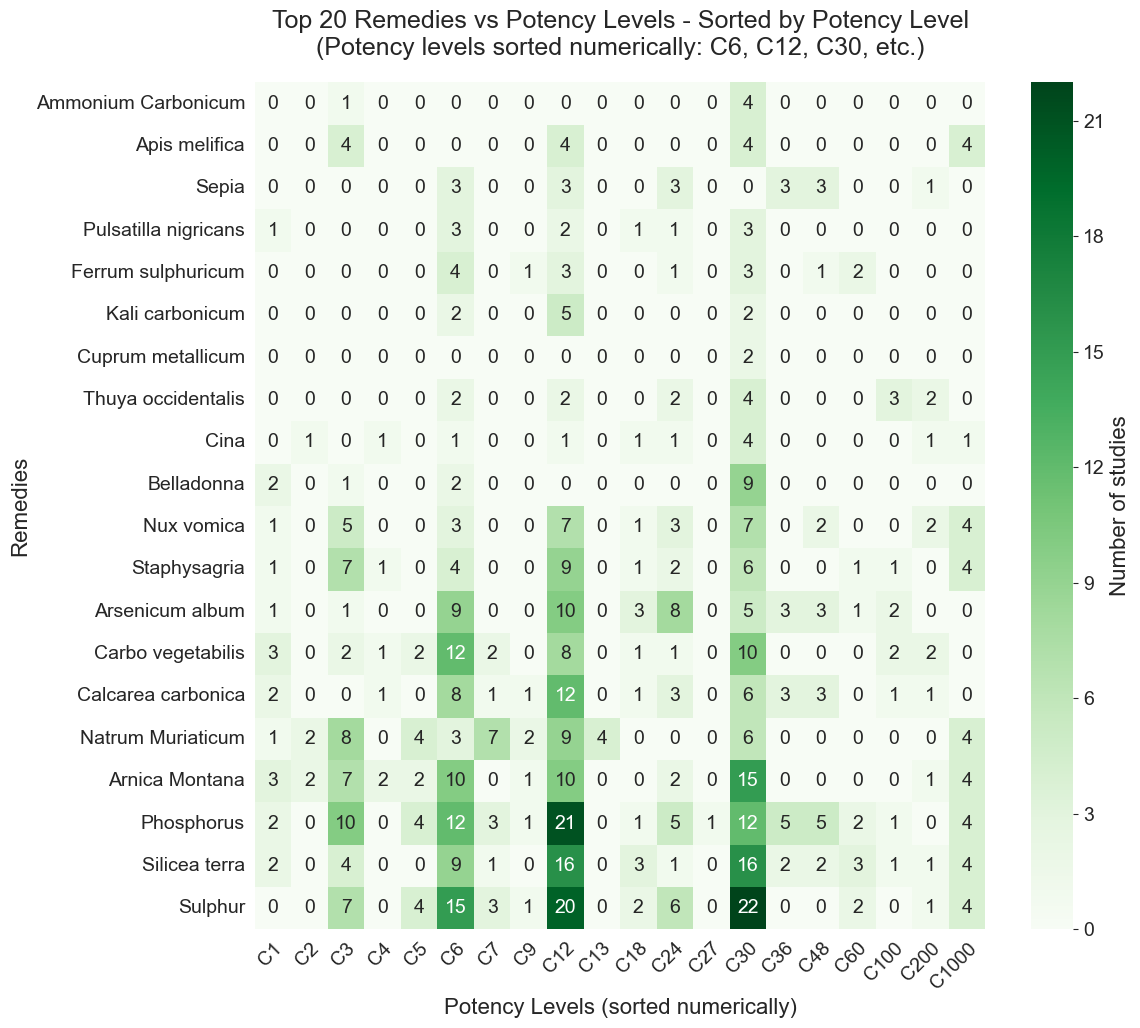


Potency levels in sorted order:
1. C1 (level 1)
2. C2 (level 2)
3. C3 (level 3)
4. C4 (level 4)
5. C5 (level 5)
6. C6 (level 6)
7. C7 (level 7)
8. C9 (level 9)
9. C12 (level 12)
10. C13 (level 13)
11. C18 (level 18)
12. C24 (level 24)
13. C27 (level 27)
14. C30 (level 30)
15. C36 (level 36)
16. C48 (level 48)
17. C60 (level 60)
18. C100 (level 100)
19. C200 (level 200)
20. C1000 (level 1000)


In [346]:
# Create potency-level-sorted version of remedy-potency heatmap
# Potency levels sorted numerically (C6, C12, C30, C200, etc.)

# Define a function to extract numeric value from potency strings like 'C6', 'C12', 'C200'
def extract_potency_number(potency_str):
    """Extract numeric part from potency string (e.g., 'C6' -> 6, 'C200' -> 200)"""
    try:
        # Remove 'C' prefix and convert to integer
        if potency_str.startswith('C'):
            return int(potency_str[1:])
        # For other formats (LM, M, etc.), return large number to put at end
        return 999999
    except (ValueError, AttributeError):
        # If parsing fails, return large number to put at end
        return 999999

# Sort potency levels by their numeric value
potency_cols = remedy_potency_matrix.columns.tolist()
sorted_potencies = sorted(potency_cols, key=extract_potency_number)

# Keep the same remedy order as original (frequency-based with reversed order)
remedy_rows = remedy_potency_matrix.index.tolist()

# Reindex the matrix with sorted potencies
remedy_potency_sorted = remedy_potency_matrix.loc[remedy_rows, sorted_potencies]

# Create heatmap visualization
fig_sorted_potency, ax_sorted_potency = plt.subplots(figsize=hmap_figsize(*remedy_potency_sorted.shape))

sns.heatmap(
    remedy_potency_sorted,
    annot=True,  # Show numbers in cells
    fmt='d',     # Integer format
    cmap='Greens',  # Green color scheme
    ax=ax_sorted_potency,
    cbar_kws={'label': 'Number of studies'},
    annot_kws={'size': HMAP_ANNOT_FS}  # Smaller annotation text
)

# Center ticks and labels
ax_sorted_potency.set_xticks([i + 0.5 for i in range(len(remedy_potency_sorted.columns))])
ax_sorted_potency.set_xticklabels(remedy_potency_sorted.columns, rotation=45, ha='right', rotation_mode='anchor')
ax_sorted_potency.set_yticks([i + 0.5 for i in range(len(remedy_potency_sorted.index))])
ax_sorted_potency.set_yticklabels(remedy_potency_sorted.index, rotation=0)

# Customize the plot
ax_sorted_potency.set_title(
    'Top 20 Remedies vs Potency Levels - Sorted by Potency Level\n(Potency levels sorted numerically: C6, C12, C30, etc.)',
    fontsize=TITLE_FS,
    pad=20
)
ax_sorted_potency.tick_params(axis='both', labelsize=HMAP_TICK_FS)
ax_sorted_potency.set_xlabel('Potency Levels (sorted numerically)', fontsize=AXIS_LABEL_FS)
ax_sorted_potency.set_ylabel('Remedies', fontsize=AXIS_LABEL_FS)

# Save and display
plt.tight_layout()
fix_hmap_cbar(fig_sorted_potency, ax_sorted_potency)
fig_sorted_potency.savefig('remedy_potency_correlation_heatmap_sorted.png', dpi=300, bbox_inches='tight')
plt.show()

# Print sorted potency order
print(f"\nPotency levels in sorted order:")
for i, potency in enumerate(sorted_potencies, 1):
    numeric_val = extract_potency_number(potency)
    if numeric_val < 999999:
        print(f"{i}. {potency} (level {numeric_val})")
    else:
        print(f"{i}. {potency} (non-standard format)")


## Cross-Category Heatmaps

### Country-Crop Heatmap

  RAWDATA CLEANUP NEEDED: Covidence #5109 has empty crop field
  RAWDATA CLEANUP NEEDED: Covidence #11703 has empty crop field
  RAWDATA CLEANUP NEEDED: Covidence #11860 has empty crop field
Country-Crop heatmap includes:
- 6 countries (top 20)
- 20 crops (top 20)
- 100 total country-crop combinations

Top 10 country-crop combinations:
- Brazil studying Tomato: 15 studies
- Brazil studying Bean: 11 studies
- Brazil studying Soybean: 10 studies
- Brazil studying Onion: 7 studies
- Brazil studying Lettuce: 5 studies
- Brazil studying Cabbage: 4 studies
- Brazil studying Chamomile: 4 studies
- Brazil studying Artemisia: 3 studies
- Brazil studying Strawberry: 3 studies
- Brazil studying Tiririca: 3 studies


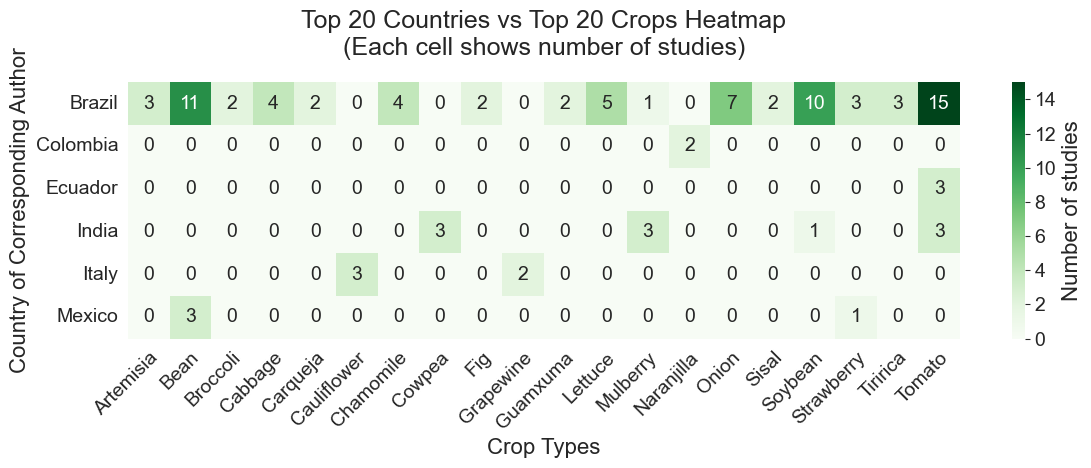

In [347]:
# Cross-Category Heatmap: Top 20 Countries vs Top 20 Crops
# This code creates a heatmap showing which crop types are studied in which countries

# Data cleaning and preparation
# Warn about empty fields (all rows here are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Country of corresponding author']) or str(row['Country of corresponding author']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty country field")
    if pd.isna(row['Crop type studied']) or str(row['Crop type studied']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty crop field")

# TODO-RAWDATA: 'Parkistan' typo and 'Great Britain ' trailing space will be fixed in final data
country_series_crop = (
    df['Country of corresponding author']
    .dropna()
    .astype(str)
    .str.strip()
    .replace({'N/A': 'Unknown', 'Parkistan': 'Pakistan'})
)

crop_series_country = (
    df['Crop type studied']
    .dropna()
    .astype(str)
    .str.strip()
)

# Filter: Top 20 of each
top_20_countries = country_series_crop.value_counts().drop(['Unknown'], errors='ignore').head(20).index.tolist()
top_20_crops_country = crop_series_country.value_counts().head(20).index.tolist()

# Data expansion
# Only rows with both valid country and crop data
valid_idx_cc = country_series_crop.index.intersection(crop_series_country.index)
expanded_country_crop = []
for idx in valid_idx_cc:
    country = country_series_crop.loc[idx]
    crop = crop_series_country.loc[idx]

    # Skip if either not in top 20
    if country not in top_20_countries:
        continue
    if crop not in top_20_crops_country:
        continue

    expanded_country_crop.append({'Country': country, 'Crop': crop})

# Validation
if len(expanded_country_crop) == 0:
    print("No data found! Check if countries and crops match top lists.")
else:
    expanded_country_crop_df = pd.DataFrame(expanded_country_crop)

    # Countries as rows, crops as columns
    country_crop_matrix = pd.crosstab(expanded_country_crop_df['Country'], expanded_country_crop_df['Crop'])

    # Create heatmap visualization
    fig_country_crop, ax_country_crop = plt.subplots(figsize=hmap_figsize(*country_crop_matrix.shape))

    # Use seaborn for professional heatmap
    sns.heatmap(
        country_crop_matrix,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=ax_country_crop,
        annot_kws={'size': HMAP_ANNOT_FS},
        cbar_kws={'label': 'Number of studies'}
    )

    # Tick positioning
    ax_country_crop.set_xticks([i + 0.5 for i in range(len(country_crop_matrix.columns))])
    ax_country_crop.set_xticklabels(country_crop_matrix.columns, rotation=45, ha='right', rotation_mode='anchor')
    ax_country_crop.set_yticks([i + 0.5 for i in range(len(country_crop_matrix.index))])
    ax_country_crop.set_yticklabels(country_crop_matrix.index, rotation=0)

    # Labels
    ax_country_crop.set_title('Top 20 Countries vs Top 20 Crops Heatmap\n(Each cell shows number of studies)', fontsize=TITLE_FS, pad=20)
    ax_country_crop.tick_params(axis='both', labelsize=HMAP_TICK_FS)
    ax_country_crop.set_xlabel('Crop Types', fontsize=AXIS_LABEL_FS)
    ax_country_crop.set_ylabel('Country of Corresponding Author', fontsize=AXIS_LABEL_FS)

    plt.tight_layout()
    fix_hmap_cbar(fig_country_crop, ax_country_crop)
    fig_country_crop.savefig('country_crop_heatmap.png', dpi=300, bbox_inches='tight')

    # Summary statistics
    print(f"Country-Crop heatmap includes:")
    print(f"- {len(country_crop_matrix.index)} countries (top 20)")
    print(f"- {len(country_crop_matrix.columns)} crops (top 20)")
    print(f"- {country_crop_matrix.values.sum()} total country-crop combinations")

    # Top pairs
    country_crop_pairs = []
    for i in range(len(country_crop_matrix)):
        for j in range(len(country_crop_matrix.columns)):
            country = country_crop_matrix.index[i]
            crop = country_crop_matrix.columns[j]
            count = country_crop_matrix.iloc[i, j]
            if count > 0:
                country_crop_pairs.append((country, crop, count))

    country_crop_pairs.sort(key=lambda x: x[2], reverse=True)
    print(f"\nTop 10 country-crop combinations:")
    for country, crop, count in country_crop_pairs[:10]:
        print(f"- {country} studying {crop}: {count} studies")


### Country-Crop Heatmap (Europe Grouped)


  RAWDATA CLEANUP NEEDED: Covidence #5109 has empty crop field
  RAWDATA CLEANUP NEEDED: Covidence #11703 has empty crop field
  RAWDATA CLEANUP NEEDED: Covidence #11860 has empty crop field
Europe-grouped countries present in data: ['Switzerland', 'Serbia', 'Italy', 'Great Britain']
Studies folded into 'Europe': 9
Country-Crop (Europe grouped) heatmap includes:
- 6 countries (most common, post-grouping)
- 20 crops (top 20)
- 100 total country-crop combinations

Top 10 country-crop combinations:
- Brazil studying Tomato: 15 studies
- Brazil studying Bean: 11 studies
- Brazil studying Soybean: 10 studies
- Brazil studying Onion: 7 studies
- Brazil studying Lettuce: 5 studies
- Brazil studying Cabbage: 4 studies
- Brazil studying Chamomile: 4 studies
- Brazil studying Artemisia: 3 studies
- Brazil studying Strawberry: 3 studies
- Brazil studying Tiririca: 3 studies


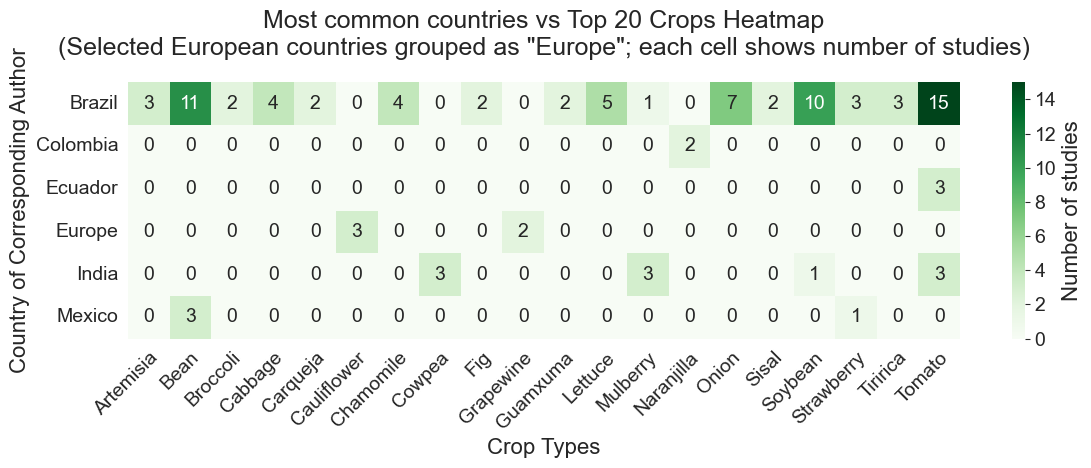

In [348]:
# Cross-Category Heatmap: Most Common Countries (Europe grouped) vs Top 20 Crops
# Variant of the "Top 20 Countries vs Top 20 Crops" heatmap above. Several European
# countries individually place too low to break into the top 20 (only Italy made it
# in the original chart), so before ranking countries by frequency, group a set of
# European countries into a single "Europe" bucket. This lets the region compete on
# equal footing with large single-country contributors (e.g. USA, India) instead of
# being split into many small, individually-invisible slices.

# Data cleaning and preparation
# Warn about empty fields (all rows here are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Country of corresponding author']) or str(row['Country of corresponding author']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty country field")
    if pd.isna(row['Crop type studied']) or str(row['Crop type studied']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty crop field")

# Countries condensed into "Europe" before the top-20 ranking is computed
europe_countries = [
    'Germany', 'France', 'Switzerland', 'Serbia', 'Italy',
    'Romania', 'Great Britain', 'Lithuania', 'UK',
]

# TODO-RAWDATA: 'Parkistan' typo and 'Great Britain ' trailing space will be fixed in final data
# Build the raw (ungrouped) series first — needed below to check which of the
# listed countries actually appear in the data — then apply the Europe grouping
# as a second, separate step so this cell is self-contained (doesn't rely on
# variables from the original Top-20-Countries heatmap cell having been run).
country_series_crop_raw = (
    df['Country of corresponding author']
    .dropna()
    .astype(str)
    .str.strip()
    .replace({'N/A': 'Unknown', 'Parkistan': 'Pakistan'})
)
country_series_crop_eu = country_series_crop_raw.replace({c: 'Europe' for c in europe_countries})

crop_series_country_eu = (
    df['Crop type studied']
    .dropna()
    .astype(str)
    .str.strip()
)

# Sanity check: which of the listed countries actually appear in the data, and how
# many studies got folded into "Europe" as a result of the grouping.
present_europe_countries = [c for c in europe_countries if c in country_series_crop_raw.value_counts().index]
print(f"Europe-grouped countries present in data: {present_europe_countries}")
print(f"Studies folded into 'Europe': {(country_series_crop_eu == 'Europe').sum()}")

# Filter: most common countries (post-grouping) x top 20 crops
top_20_countries_eu = country_series_crop_eu.value_counts().drop(['Unknown'], errors='ignore').head(20).index.tolist()
top_20_crops_country_eu = crop_series_country_eu.value_counts().head(20).index.tolist()

# Data expansion
# Only rows with both valid country and crop data
valid_idx_cc_eu = country_series_crop_eu.index.intersection(crop_series_country_eu.index)
expanded_country_crop_eu = []
for idx in valid_idx_cc_eu:
    country = country_series_crop_eu.loc[idx]
    crop = crop_series_country_eu.loc[idx]

    # Skip if either not in the top lists
    if country not in top_20_countries_eu:
        continue
    if crop not in top_20_crops_country_eu:
        continue

    expanded_country_crop_eu.append({'Country': country, 'Crop': crop})

# Validation
if len(expanded_country_crop_eu) == 0:
    print("No data found! Check if countries and crops match top lists.")
else:
    expanded_country_crop_eu_df = pd.DataFrame(expanded_country_crop_eu)

    # Countries as rows, crops as columns
    country_crop_matrix_eu = pd.crosstab(expanded_country_crop_eu_df['Country'], expanded_country_crop_eu_df['Crop'])

    # Create heatmap visualization
    fig_country_crop_eu, ax_country_crop_eu = plt.subplots(figsize=hmap_figsize(*country_crop_matrix_eu.shape))

    # Use seaborn for professional heatmap
    sns.heatmap(
        country_crop_matrix_eu,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=ax_country_crop_eu,
        annot_kws={'size': HMAP_ANNOT_FS},
        cbar_kws={'label': 'Number of studies'}
    )

    # Tick positioning
    ax_country_crop_eu.set_xticks([i + 0.5 for i in range(len(country_crop_matrix_eu.columns))])
    ax_country_crop_eu.set_xticklabels(country_crop_matrix_eu.columns, rotation=45, ha='right', rotation_mode='anchor')
    ax_country_crop_eu.set_yticks([i + 0.5 for i in range(len(country_crop_matrix_eu.index))])
    ax_country_crop_eu.set_yticklabels(country_crop_matrix_eu.index, rotation=0)

    # Labels
    ax_country_crop_eu.set_title('Most common countries vs Top 20 Crops Heatmap\n(Selected European countries grouped as "Europe"; each cell shows number of studies)', fontsize=TITLE_FS, pad=20)
    ax_country_crop_eu.tick_params(axis='both', labelsize=HMAP_TICK_FS)
    ax_country_crop_eu.set_xlabel('Crop Types', fontsize=AXIS_LABEL_FS)
    ax_country_crop_eu.set_ylabel('Country of Corresponding Author', fontsize=AXIS_LABEL_FS)

    plt.tight_layout()
    fix_hmap_cbar(fig_country_crop_eu, ax_country_crop_eu)
    fig_country_crop_eu.savefig('country_crop_heatmap_europe_grouped.png', dpi=300, bbox_inches='tight')

    # Summary statistics
    print(f"Country-Crop (Europe grouped) heatmap includes:")
    print(f"- {len(country_crop_matrix_eu.index)} countries (most common, post-grouping)")
    print(f"- {len(country_crop_matrix_eu.columns)} crops (top 20)")
    print(f"- {country_crop_matrix_eu.values.sum()} total country-crop combinations")

    # Top pairs
    country_crop_pairs_eu = []
    for i in range(len(country_crop_matrix_eu)):
        for j in range(len(country_crop_matrix_eu.columns)):
            country = country_crop_matrix_eu.index[i]
            crop = country_crop_matrix_eu.columns[j]
            count = country_crop_matrix_eu.iloc[i, j]
            if count > 0:
                country_crop_pairs_eu.append((country, crop, count))

    country_crop_pairs_eu.sort(key=lambda x: x[2], reverse=True)
    print(f"\nTop 10 country-crop combinations:")
    for country, crop, count in country_crop_pairs_eu[:10]:
        print(f"- {country} studying {crop}: {count} studies")


### Potency-Crop Heatmap

  RAWDATA CLEANUP NEEDED: Covidence #5109 has empty crop type field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty potency levels field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty potency levels field
  RAWDATA CLEANUP NEEDED: Covidence #11703 has empty crop type field
  RAWDATA CLEANUP NEEDED: Covidence #11860 has empty crop type field
Potency-Crop correlation heatmap includes:
- 20 potency levels (top 20)
- 18 crops (top 20)
- 264 total potency-crop combinations

Top 10 potency-crop combinations:
- C12 on Soybean: 10 studies
- C12 on Tomato: 8 studies
- C30 on Tomato: 8 studies
- C6 on Soybean: 8 studies
- C6 on Tomato: 8 studies
- C12 on Bean: 7 studies
- C6 on Bean: 6 studies
- C6 on Onion: 6 studies
- C12 on Onion: 5 studies
- C13 on Tomato: 5 studies


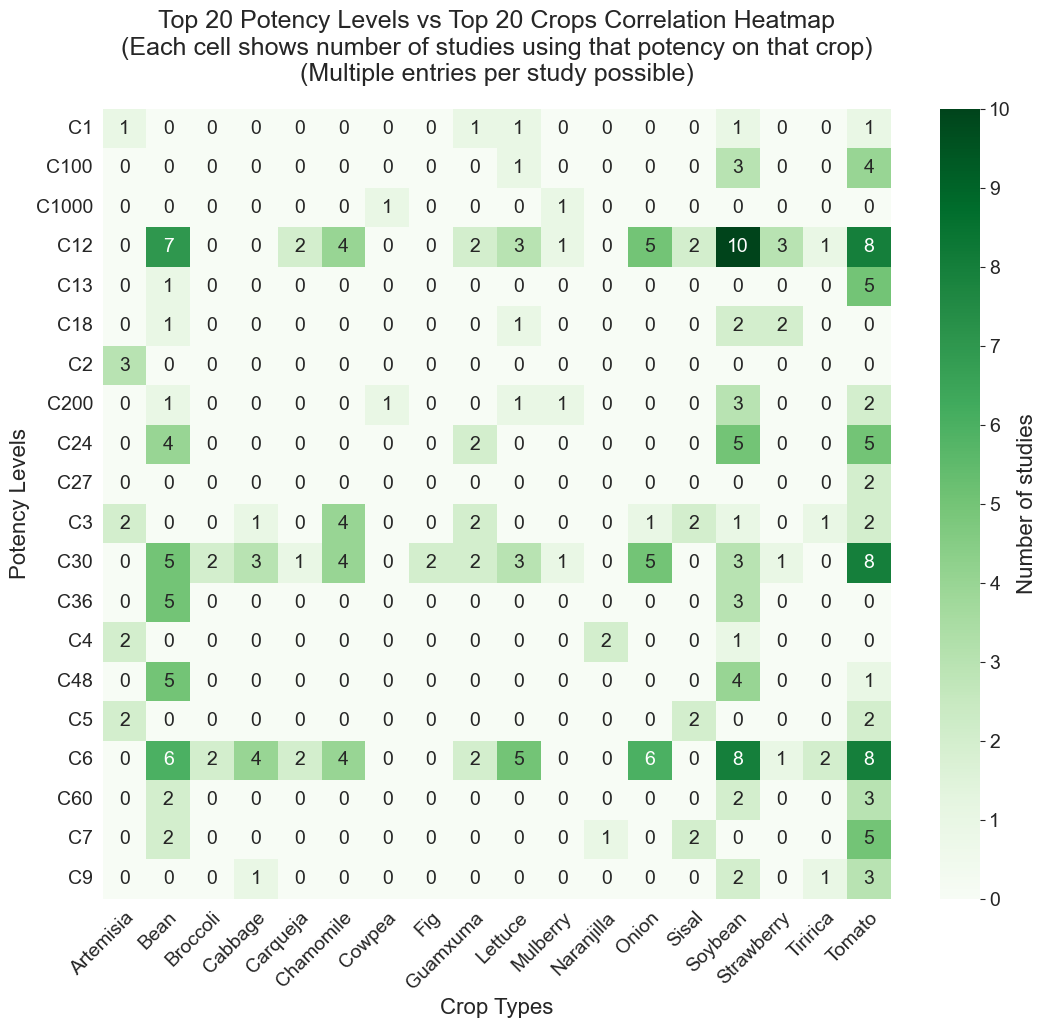

In [349]:
# Cross-Category Heatmap: Top 20 Potency Levels vs Top 20 Crops
# This code creates a heatmap showing which potency levels are used on which crops

# Warn about empty fields (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Potency levels']) or str(row['Potency levels']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty potency levels field")
    if pd.isna(row['Crop type studied']) or str(row['Crop type studied']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty crop type field")

# Data cleaning and preparation
potency_series_crop = (
    df['Potency levels']
    .dropna()
    .astype(str)
    .str.strip()
)

potency_exploded_crop = (
    potency_series_crop
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
potency_exploded_crop = potency_exploded_crop[potency_exploded_crop != '']

crop_series_potency = (
    df['Crop type studied']
    .dropna()
    .astype(str)
    .str.strip()
)

# Filter: Top 20 of each
top_20_potencies_crop = potency_exploded_crop.value_counts().head(20).index.tolist()
top_20_crops_potency = crop_series_potency.value_counts().head(20).index.tolist()

# Data expansion (all combinations)
# Only rows with both valid potency and crop data
valid_idx_pc = potency_series_crop.index.intersection(crop_series_potency.index)
expanded_potency_crop = []
for idx in valid_idx_pc:
    potency_cell = potency_series_crop.loc[idx]
    crop = crop_series_potency.loc[idx]

    # Skip if crop not in top 20
    if crop not in top_20_crops_potency:
        continue

    potencies = str(potency_cell).split(',')

    # Create entries for ALL potencies used on this crop
    for potency in potencies:
        potency_clean = potency.strip()
        if potency_clean and potency_clean in top_20_potencies_crop:
            expanded_potency_crop.append({'Potency': potency_clean, 'Crop': crop})

# Validation
if len(expanded_potency_crop) == 0:
    print("No data found! Check if potencies and crops match top lists.")
else:
    expanded_potency_crop_df = pd.DataFrame(expanded_potency_crop)

    # Potencies as rows, crops as columns
    potency_crop_matrix = pd.crosstab(expanded_potency_crop_df['Potency'], expanded_potency_crop_df['Crop'])

    # Create heatmap visualization
    fig_potency_crop, ax_potency_crop = plt.subplots(figsize=hmap_figsize(*potency_crop_matrix.shape))

    # Use seaborn for professional heatmap
    sns.heatmap(
        potency_crop_matrix,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=ax_potency_crop,
        cbar_kws={'label': 'Number of studies'},
        annot_kws={'size': HMAP_ANNOT_FS}  # Smaller text for large matrix
    )

    # Tick positioning
    ax_potency_crop.set_xticks([i + 0.5 for i in range(len(potency_crop_matrix.columns))])
    ax_potency_crop.set_xticklabels(potency_crop_matrix.columns, rotation=45, ha='right', rotation_mode='anchor')
    ax_potency_crop.set_yticks([i + 0.5 for i in range(len(potency_crop_matrix.index))])
    ax_potency_crop.set_yticklabels(potency_crop_matrix.index, rotation=0)

    # Labels
    ax_potency_crop.set_title('Top 20 Potency Levels vs Top 20 Crops Correlation Heatmap\n(Each cell shows number of studies using that potency on that crop)\n(Multiple entries per study possible)', fontsize=TITLE_FS, pad=20)
    ax_potency_crop.tick_params(axis='both', labelsize=HMAP_TICK_FS)
    ax_potency_crop.set_xlabel('Crop Types', fontsize=AXIS_LABEL_FS)
    ax_potency_crop.set_ylabel('Potency Levels', fontsize=AXIS_LABEL_FS)

    plt.tight_layout()
    fix_hmap_cbar(fig_potency_crop, ax_potency_crop)
    fig_potency_crop.savefig('potency_crop_correlation_heatmap.png', dpi=300, bbox_inches='tight')

    # Summary statistics
    print(f"Potency-Crop correlation heatmap includes:")
    print(f"- {len(potency_crop_matrix.index)} potency levels (top 20)")
    print(f"- {len(potency_crop_matrix.columns)} crops (top 20)")
    print(f"- {potency_crop_matrix.values.sum()} total potency-crop combinations")

    # Top pairs
    potency_crop_pairs = []
    for i in range(len(potency_crop_matrix)):
        for j in range(len(potency_crop_matrix.columns)):
            potency = potency_crop_matrix.index[i]
            crop = potency_crop_matrix.columns[j]
            count = potency_crop_matrix.iloc[i, j]
            if count > 0:
                potency_crop_pairs.append((potency, crop, count))

    potency_crop_pairs.sort(key=lambda x: x[2], reverse=True)
    print(f"\nTop 10 potency-crop combinations:")
    for potency, crop, count in potency_crop_pairs[:10]:
        print(f"- {potency} on {crop}: {count} studies")


### Intervention-Crop Heatmap

  RAWDATA CLEANUP NEEDED: Covidence #5109 has empty Crop type studied field
  RAWDATA CLEANUP NEEDED: Covidence #11703 has empty Crop type studied field
  RAWDATA CLEANUP NEEDED: Covidence #11860 has empty Crop type studied field
  RAWDATA CLEANUP NEEDED: Covidence #10695 has empty Homeopathic intervention field
Intervention-Crop heatmap includes:
- 8 intervention types
- 20 crops (top 20)
- 118 total intervention-crop combinations

Top 10 intervention-crop combinations:
- Treatment of plant during growth (eg. spray on leaves) on Tomato: 12 studies
- Treatment of plant during growth (eg. spray on leaves) on Onion: 7 studies
- Treatment of soil during growth (seperate from watering) on Bean: 7 studies
- Treatment of plant during growth (eg. spray on leaves) on Bean: 6 studies
- Treatment of plant during growth (eg. spray on leaves) on Soybean: 6 studies
- Pre-treatment of seeds on Tomato: 4 studies
- Pre-treatment of soil/growth medium on Soybean: 4 studies
- Treatment of plant during g

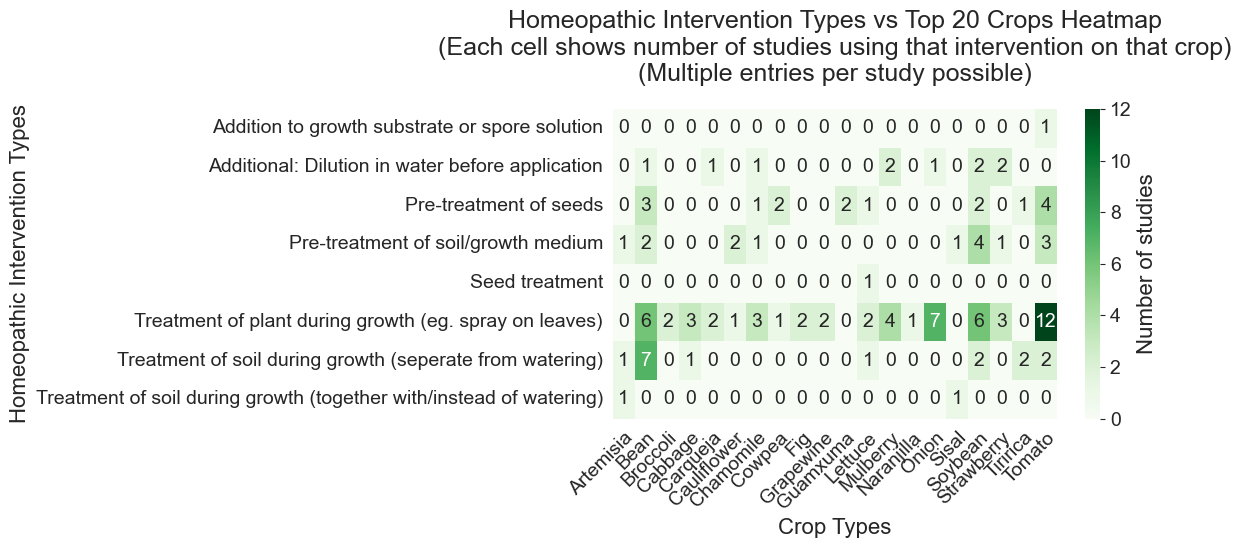

In [350]:
# Cross-Category Heatmap: Homeopathic Intervention Types vs Top 20 Crops
# This code creates a heatmap showing which intervention types are applied to which crops

# --- RAWDATA warnings for empty fields ---
for idx, row in df.iterrows():
    if pd.isna(row['Homeopathic intervention']) or str(row['Homeopathic intervention']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty Homeopathic intervention field")
    elif str(row['Homeopathic intervention']).strip() == 'N/A':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has outdated 'N/A' in Homeopathic intervention — needs real label")
    if pd.isna(row['Crop type studied']) or str(row['Crop type studied']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty Crop type studied field")

# Data cleaning — drop NaN/empty, keep 'N/A' as legit crop label
intervention_series_crop = (
    df['Homeopathic intervention']
    .dropna()
    .astype(str)
    .str.strip()
)
intervention_series_crop = intervention_series_crop[intervention_series_crop != '']

crop_series_intervention = (
    df['Crop type studied']
    .dropna()
    .astype(str)
    .str.strip()
)
crop_series_intervention = crop_series_intervention[crop_series_intervention != '']

# Explode comma-separated interventions
intervention_exploded_crop = (
    intervention_series_crop
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
intervention_exploded_crop = intervention_exploded_crop[intervention_exploded_crop != '']

# Filter: Top 20 crops, ALL intervention types (since there are only ~9 types)
top_20_crops_intervention = crop_series_intervention.value_counts().head(20).index.tolist()
all_interventions = intervention_exploded_crop.value_counts().index.tolist()

# Data expansion — use index intersection for alignment
valid_idx = intervention_series_crop.index.intersection(crop_series_intervention.index)

expanded_intervention_crop = []
for idx in valid_idx:
    crop = crop_series_intervention.loc[idx]
    intervention_cell = intervention_series_crop.loc[idx]

    # Skip if crop not in top 20
    if crop not in top_20_crops_intervention:
        continue

    # Split and add each intervention-crop pair
    interventions = str(intervention_cell).split(',')
    for intervention in interventions:
        intervention_clean = intervention.strip()
        if intervention_clean and intervention_clean in all_interventions:
            expanded_intervention_crop.append({'Intervention': intervention_clean, 'Crop': crop})

# Validation
if len(expanded_intervention_crop) == 0:
    print("No data found! Check if interventions and crops match top lists.")
else:
    expanded_intervention_crop_df = pd.DataFrame(expanded_intervention_crop)

    # Interventions as rows, crops as columns
    intervention_crop_matrix = pd.crosstab(expanded_intervention_crop_df['Intervention'], expanded_intervention_crop_df['Crop'])

    # Create heatmap visualization (adjust figsize based on number of intervention types ~9 x 20 crops)
    fig_intervention_crop, ax_intervention_crop = plt.subplots(figsize=hmap_figsize(*intervention_crop_matrix.shape))

    # Use seaborn for professional heatmap
    sns.heatmap(
        intervention_crop_matrix,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=ax_intervention_crop,
        cbar_kws={'label': 'Number of studies'},
        annot_kws={'size': HMAP_ANNOT_FS}
    )

    # Tick positioning
    ax_intervention_crop.set_xticks([i + 0.5 for i in range(len(intervention_crop_matrix.columns))])
    ax_intervention_crop.set_xticklabels(intervention_crop_matrix.columns, rotation=45, ha='right', rotation_mode='anchor')
    ax_intervention_crop.set_yticks([i + 0.5 for i in range(len(intervention_crop_matrix.index))])
    ax_intervention_crop.set_yticklabels(intervention_crop_matrix.index, rotation=0)

    # Labels
    ax_intervention_crop.set_title('Homeopathic Intervention Types vs Top 20 Crops Heatmap\n(Each cell shows number of studies using that intervention on that crop)\n(Multiple entries per study possible)', fontsize=TITLE_FS, pad=20)
    ax_intervention_crop.tick_params(axis='both', labelsize=HMAP_TICK_FS)
    ax_intervention_crop.set_xlabel('Crop Types', fontsize=AXIS_LABEL_FS)
    ax_intervention_crop.set_ylabel('Homeopathic Intervention Types', fontsize=AXIS_LABEL_FS)

    plt.tight_layout()
    fix_hmap_cbar(fig_intervention_crop, ax_intervention_crop)
    fig_intervention_crop.savefig('intervention_crop_heatmap.png', dpi=300, bbox_inches='tight')

    # Summary statistics
    print(f"Intervention-Crop heatmap includes:")
    print(f"- {len(intervention_crop_matrix.index)} intervention types")
    print(f"- {len(intervention_crop_matrix.columns)} crops (top 20)")
    print(f"- {intervention_crop_matrix.values.sum()} total intervention-crop combinations")

    # Top pairs
    intervention_crop_pairs = []
    for i in range(len(intervention_crop_matrix)):
        for j in range(len(intervention_crop_matrix.columns)):
            intervention = intervention_crop_matrix.index[i]
            crop = intervention_crop_matrix.columns[j]
            count = intervention_crop_matrix.iloc[i, j]
            if count > 0:
                intervention_crop_pairs.append((intervention, crop, count))

    intervention_crop_pairs.sort(key=lambda x: x[2], reverse=True)
    print(f"\nTop 10 intervention-crop combinations:")
    for intervention, crop, count in intervention_crop_pairs[:10]:
        print(f"- {intervention} on {crop}: {count} studies")


## Potency Production Methods

### Production of potency — parsing


In [351]:
#===== Production of potency — clean parsing (foundation for tables/charts) ==

# The "Production of potency" column is multi-select and CSV-quoted: two labels
# contain an internal comma ("Brand-not-reported MT, store bought from ...") and
# Excel wraps those in quotes. We therefore parse each cell with the csv module
# (skipinitialspace=True) rather than a naive comma split, so a quoted label is
# recognised even when it follows ", " instead of sitting at the cell start.
#
# Data-handling rules:
#   - NaN / empty  -> dropped, with a RAWDATA warning (a genuine data gap)
#   - "N/A"        -> KEPT as a meaningful label (author explicitly stated N/A)
#   - every other token kept verbatim (any grouping happens later, in viz cells)

import csv
from io import StringIO
from collections import Counter


def parse_production_cell(value):
    # Return a list of cleaned production-method tokens for one study, or None if
    # the field is missing. csv handles the quoted, comma-bearing labels;
    # skipinitialspace lets a quoted field be recognised even after ", ".
    if pd.isna(value) or str(value).strip() == "":
        return None
    tokens = next(csv.reader(StringIO(str(value)), skipinitialspace=True))
    return [t.strip() for t in tokens if t.strip()]


# Warn about + drop studies with no production-of-potency info.
for idx, row in df.iterrows():
    if pd.isna(row["Production of potency"]) or str(row["Production of potency"]).strip() == "":
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty Production of potency field")

# Per-study token lists (missing rows dropped). Index = surviving df rows.
production_routes = df["Production of potency"].apply(parse_production_cell).dropna()
n_production_studies = int(len(production_routes))

# Flat label frequency across studies (each label counted once per study).
production_token_counts = pd.Series(
    Counter(token for tokens in production_routes for token in tokens)
).sort_values(ascending=False)

print(
    f"\nProduction of potency parsed for {n_production_studies} studies "
    f"(of {len(df)} with MIS >= 5)."
)
print("Distinct labels:", len(production_token_counts))
print(production_token_counts.to_string())


  RAWDATA CLEANUP NEEDED: Covidence #4315 has empty Production of potency field
  RAWDATA CLEANUP NEEDED: Covidence #5112 has empty Production of potency field

Production of potency parsed for 158 studies (of 160 with MIS >= 5).
Distinct labels: 10
Additional: further potentization in-house                                          98
In-house production of mother tincture                                              63
Brand-not-reported potency store bought potency from un-named pharmacy/institute    53
Branded potency                                                                     36
Branded MT                                                                           8
Brand-not-reported potency store bought potency from named pharmacy/institute        7
Brand-not-reported MT, store bought from named pharmacy/institute                    4
Brand-not-reported MT, store bough from un-named pharmacy/institute                  4
N/A                                                   

### Production of potency — single methods vs combinations


In [352]:
#===== Production of potency — single methods vs combinations ================

# Built on `production_routes` (per-study token lists from the parsing cell).
#   1. Collapse the named/un-named pharmacy distinction (not of interest) and
#      drop the now-implicit ", store bought" -> "Brand-not-reported MT" /
#      "Brand-not-reported potency".
#   2. "Additional: further potentization in-house" is a MODIFIER, not an option:
#      it becomes the without/with column split, never counted as an option.
#   3. Studies with exactly ONE core option -> counted per option (rows in
#      pipeline order), split by without/with further potentization.
#   4. Studies with >= 2 core options -> collapsed into one "Combinations" row
#      (total only); the actual combinations are printed below, most prevalent
#      first, each with its own without/with further-potentization split.
#   5. Studies left with NO core option (only the modifier) are flagged & dropped.

FURTHER_LABEL = "Additional: further potentization in-house"

# Collapse pharmacy provenance; drop the now-implicit ", store bought".
production_collapse_map = {
    "Brand-not-reported potency store bought potency from named pharmacy/institute": "Brand-not-reported potency",
    "Brand-not-reported potency store bought potency from un-named pharmacy/institute": "Brand-not-reported potency",
    "Brand-not-reported MT, store bought from named pharmacy/institute": "Brand-not-reported MT",
    "Brand-not-reported MT, store bough from un-named pharmacy/institute": "Brand-not-reported MT",
}

# Row order: MT-sourced first (a remedy starts as MT), then ready-made potency,
# then the leftover categories.
single_option_order = [
    "In-house production of mother tincture",
    "Brand-not-reported MT",
    "Branded MT",
    "Brand-not-reported potency",
    "Branded potency",
    "Use of potency from earlier experiment",
    "N/A",
]

single_without = Counter()   # option -> studies with only this option, no further potentization
single_with = Counter()      # option -> studies with only this option + further potentization
combo_counts = Counter()     # tuple(sorted core options) -> study count
combo_without = Counter()    # combo -> studies without further potentization
combo_with = Counter()       # combo -> studies with further potentization

for idx, tokens in production_routes.items():
    has_further = FURTHER_LABEL in tokens
    # Collapse, drop the modifier, de-duplicate (collapsing can create dupes,
    # e.g. a study citing both named & un-named MT becomes one "Brand-not-reported MT").
    core_unique = sorted({production_collapse_map.get(t, t) for t in tokens if t != FURTHER_LABEL})

    if len(core_unique) == 0:
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{df.loc[idx, 'Covidence #']} "
              f"lists only 'further potentization in-house' with no production source — dropped")
        continue

    if len(core_unique) == 1:
        (single_with if has_further else single_without)[core_unique[0]] += 1
    else:
        combo_key = tuple(core_unique)
        combo_counts[combo_key] += 1
        (combo_with if has_further else combo_without)[combo_key] += 1

# --- Assemble the table -----------------------------------------------------
singles_without = sum(single_without.values())
singles_with = sum(single_with.values())
combos_without = sum(combo_without.values())
combos_with = sum(combo_with.values())
combos_total = int(sum(combo_counts.values()))
grand_total = singles_without + singles_with + combos_total

table_rows = []
for option in single_option_order:
    without_n = single_without.get(option, 0)
    with_n = single_with.get(option, 0)
    table_rows.append({
        "Production method": option,
        "Without further potentization": without_n,
        "With further potentization": with_n,
        "Total": without_n + with_n,
    })

# Combinations: now split without/with as well as total.
table_rows.append({
    "Production method": "Combinations",
    "Without further potentization": combos_without,
    "With further potentization": combos_with,
    "Total": combos_total,
})

# Total row: column sums (singles + combinations) reconcile to the grand total.
table_rows.append({
    "Production method": "Total",
    "Without further potentization": singles_without + combos_without,
    "With further potentization": singles_with + combos_with,
    "Total": grand_total,
})

production_single_table = pd.DataFrame(table_rows)

production_single_title = (
    f"Production of potency — single methods (split by further in-house "
    f"potentization); {grand_total} studies classified"
)

# --- Console: the table, then the actual combinations -----------------------
print(f"\n{production_single_title}")
print(production_single_table.to_string(index=False))

print(
    "\nCombinations behind the 'Combinations' row "
    "(most prevalent first; total, then without / with further potentization):"
)
if combo_counts:
    for combo, n in sorted(combo_counts.items(), key=lambda kv: (-kv[1], kv[0])):
        print(
            f"  {n:>3}  (without {combo_without.get(combo, 0)}, "
            f"with {combo_with.get(combo, 0)})  {' + '.join(combo)}"
        )
else:
    print("  (none)")

# In-notebook display: hide the index.
production_single_table.style.hide(axis="index").set_caption(production_single_title)



Production of potency — single methods (split by further in-house potentization); 158 studies classified
                     Production method  Without further potentization  With further potentization  Total
In-house production of mother tincture                             17                          33     50
                 Brand-not-reported MT                              0                           5      5
                            Branded MT                              2                           3      5
            Brand-not-reported potency                             21                          34     55
                       Branded potency                             16                          11     27
Use of potency from earlier experiment                              0                           0      0
                                   N/A                              0                           0      0
                          Combinations                

Production method,Without further potentization,With further potentization,Total
In-house production of mother tincture,17,33,50
Brand-not-reported MT,0,5,5
Branded MT,2,3,5
Brand-not-reported potency,21,34,55
Branded potency,16,11,27
Use of potency from earlier experiment,0,0,0
N/A,0,0,0
Combinations,4,12,16
Total,60,98,158


### Materials for Potentization

  RAWDATA CLEANUP NEEDED: Covidence #4315 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #4845 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #5111 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #10537 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #11735 has empty materials for potentization field


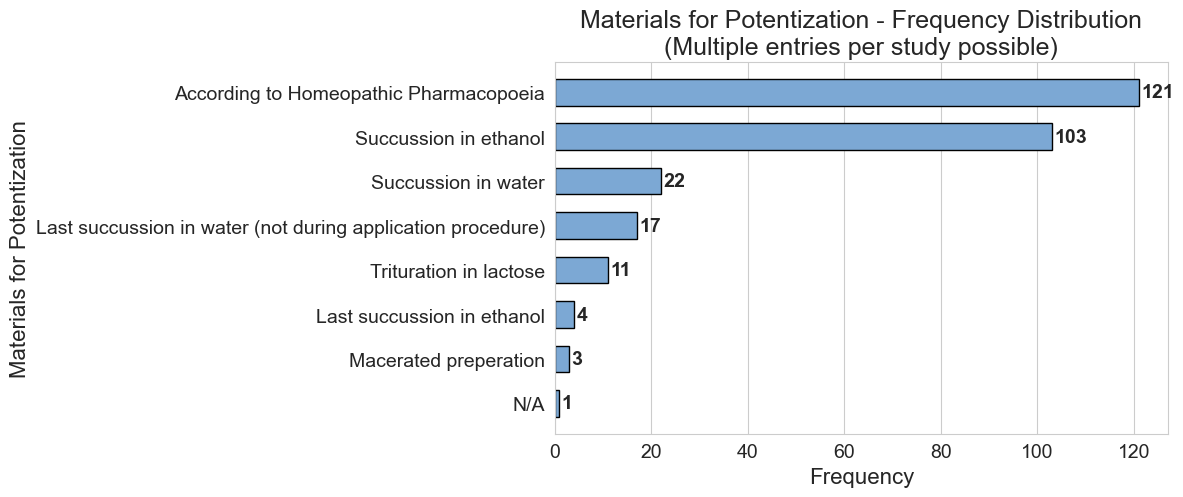

Materials for Potentization - Summary:
- Total entries: 282
- Unique materials: 8
- Most common: According to Homeopathic Pharmacopoeia (121 entries)


In [353]:
# Materials for Potentization Horizontal Bar Chart

# This code analyzes the "Materials for potentization" column and creates a horizontal bar chart showing the frequency of each material used. We'll handle comma-separated entries properly.

# Analyze "Materials for potentization" column and create horizontal bar chart with comma separation

# Warn about empty fields (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Materials for potentization']) or str(row['Materials for potentization']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty materials for potentization field")

# Clean and split the 'Materials for potentization' column on commas
materials_series_potent = (
    df['Materials for potentization']
    .dropna()
    .astype(str)
    .str.strip()
)

# Split on comma, explode into individual entries, drop empty strings
materials_exploded_potent = (
    materials_series_potent
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
materials_exploded_potent = materials_exploded_potent[materials_exploded_potent != '']

# Get frequency counts and sort by frequency (highest first for horizontal bars)
materials_counts_potent = materials_exploded_potent.value_counts().sort_values(ascending=True)

# Create horizontal bar chart using matplotlib
fig_materials, ax_materials = plt.subplots(figsize=hbar_figsize(len(materials_counts_potent)))

# Create horizontal bars with proper positioning
y_positions = range(len(materials_counts_potent))
bars = ax_materials.barh(y_positions, materials_counts_potent.values, edgecolor='black', height=BAR_H)

# Set y-axis labels and positions
ax_materials.set_yticks(y_positions)
ax_materials.set_yticklabels(materials_counts_potent.index)

# Customize the plot
ax_materials.set_xlabel('Frequency')
ax_materials.set_ylabel('Materials for Potentization')
ax_materials.set_title('Materials for Potentization - Frequency Distribution\n(Multiple entries per study possible)')

# Add value labels on the bars
for i, (material, freq) in enumerate(materials_counts_potent.items()):
    ax_materials.text(freq + 0.5, i, str(freq), va='center', fontweight='bold')

ax_materials.yaxis.grid(False)

# Save and display
plt.tight_layout()
fig_materials.savefig('materials_potentization_horizontal_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"Materials for Potentization - Summary:")
print(f"- Total entries: {len(materials_exploded_potent)}")
print(f"- Unique materials: {len(materials_counts_potent)}")
print(f"- Most common: {materials_counts_potent.index[-1]} ({materials_counts_potent.iloc[-1]} entries)")


### Succussion Methods

In [354]:
# Create pie chart showing succussion methods per study from "Materials for potentization" column

# Warn about empty fields (all rows are MIS >= 5)
for idx, row in df.iterrows():
    if pd.isna(row['Materials for potentization']) or str(row['Materials for potentization']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty materials for potentization field")

# Clean the materials for potentization column (drop NaN, keep 'N/A' as legit entry)
materials_series_pie = (
    df['Materials for potentization']
    .dropna()
    .astype(str)
    .str.strip()
)


# Function to categorize each study based on succussion method
# 'Other / no info' covers: N/A, According to Homeopathic Pharmacopoeia (usually
# ethanol but not exclusively), trituration, maceration, and any other entries
# that don't explicitly mention succussion in water or ethanol.
def categorize_succussion_method(cell_value):
    if pd.isna(cell_value) or str(cell_value).strip() == '':
        return 'Other / no info'

    cell_str = str(cell_value).lower()

    # Literal 'N/A' entries → no info about succussion method
    if cell_str.strip() == 'n/a':
        return 'Other / no info'

    has_water = 'succussion in water' in cell_str
    has_ethanol = 'succussion in ethanol' in cell_str

    if has_water and has_ethanol:
        return 'Both'
    elif has_water:
        return 'Succussion in water'
    elif has_ethanol:
        return 'Succussion in ethanol'
    else:
        return 'Other / no info'


# Apply categorization to each study
succussion_categories = materials_series_pie.apply(categorize_succussion_method)
succussion_counts = succussion_categories.value_counts()

# Prepare data for pie chart
labels_succussion = succussion_counts.index.tolist()
labels_succussion = [add_line_breaks_to_label(lbl, strategy='word_count') for lbl in labels_succussion]
values_succussion = succussion_counts.values.tolist()

# Compute percentages and set label positions
total_succussion = sum(values_succussion)
percentages_succussion = [(v / total_succussion) * 100 if total_succussion else 0 for v in values_succussion]
percentages_cutoff = 10
text_positions_succussion = ['outside' if p < percentages_cutoff else 'inside' for p in percentages_succussion]
custom_text_succussion = [
    f"{label}<br>{percent:.1f}%" if position == 'inside'
    else f"{label} {percent:.1f}%"
    for label, percent, position in zip(labels_succussion, percentages_succussion, text_positions_succussion)
]

# Build pie chart (styled like the "Country of corresponding author" chart)
succussion_pie = go.Figure(
    data=[
        go.Pie(
            labels=labels_succussion,
            values=values_succussion,
            text=custom_text_succussion,
            textinfo='text',
            textposition=text_positions_succussion,
            insidetextorientation='horizontal',
            sort=False,
            direction='clockwise',
            rotation=90,
        )
    ]
)

succussion_pie.update_traces(
    textfont=dict(size=PLOTLY_TEXT_FS, color='black'),
    insidetextfont=dict(color='black'),
)

textfont = dict(size=PLOTLY_TEXT_FS, color='black'),
succussion_pie.update_layout(
    title='Materials for Potentization - Succussion Methods',
    showlegend=False,
    margin=dict(t=120, b=20, l=20, r=20)
)

succussion_pie.show()
succussion_pie.write_image('materials_succussion_methods_pie.png', width=800, height=600, scale=2)

# Print summary statistics
print(f"Succussion Methods Distribution:")
for method, count in succussion_counts.items():
    percentage = (count / total_succussion * 100) if total_succussion else 0
    print(f"- {method}: {count} studies ({percentage:.1f}%)")
print(f"Total studies: {total_succussion}")


  RAWDATA CLEANUP NEEDED: Covidence #4315 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #4845 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #5111 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #10537 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty materials for potentization field
  RAWDATA CLEANUP NEEDED: Covidence #11735 has empty materials for potentization field


Succussion Methods Distribution:
- Succussion in ethanol: 90 studies (58.8%)
- Other / no info: 24 studies (15.7%)
- Succussion in water: 23 studies (15.0%)
- Both: 16 studies (10.5%)
Total studies: 153


### Controls

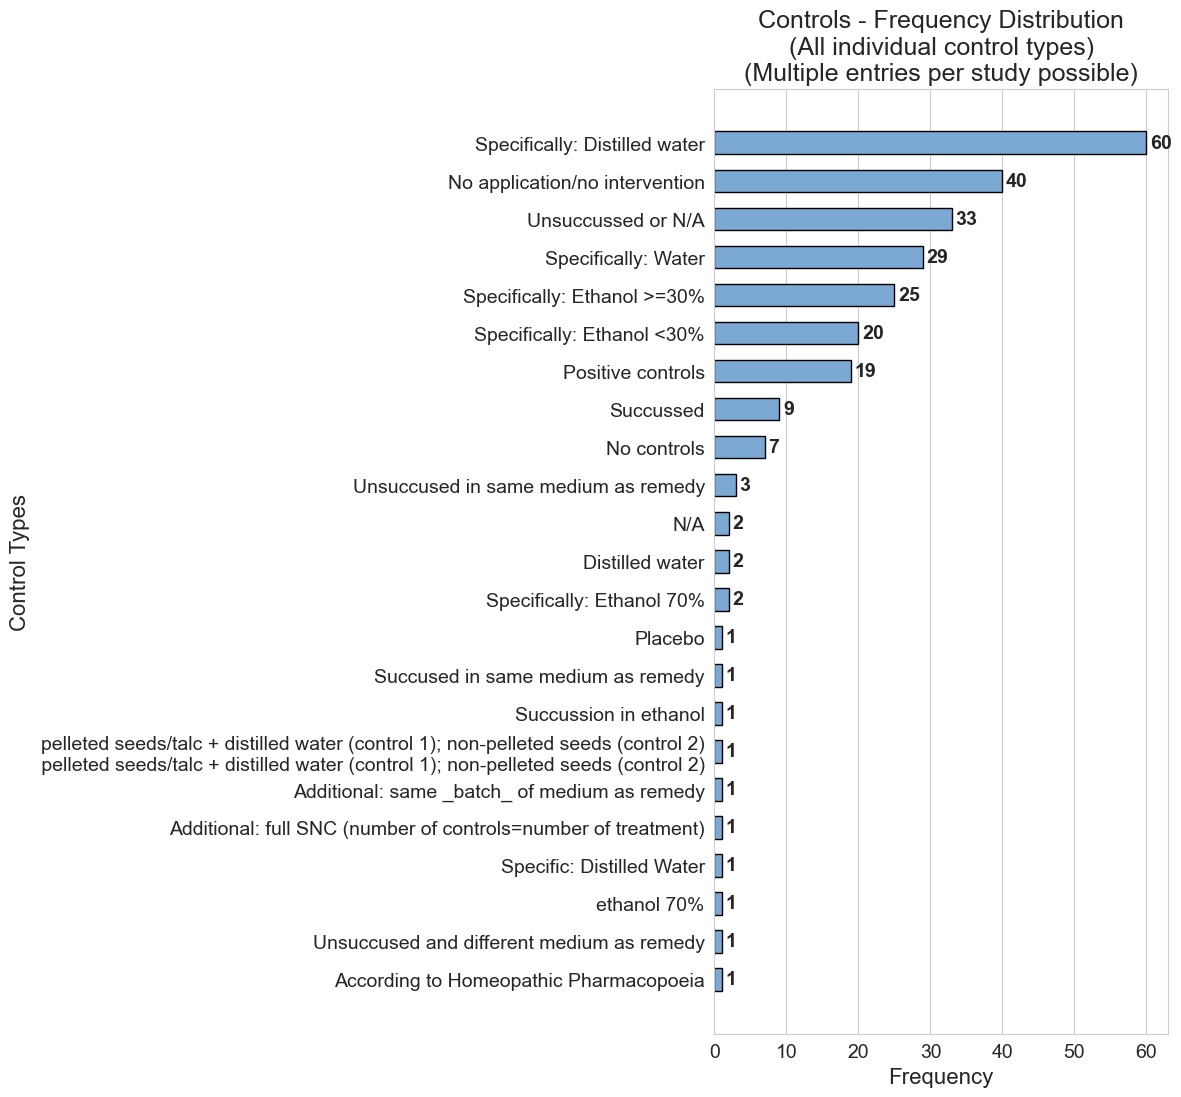

Controls - Summary:
- Total entries: 261
- Unique control types: 23
- Most common: Specifically: Distilled water (60 entries)
- Least common: According to Homeopathic Pharmacopoeia (1 entries)


In [355]:
# Analyze "Controls" column and create horizontal bar chart with comma separation, showing all individual control types

# --- RAWDATA warnings for empty fields ---
for idx, row in df.iterrows():
    if pd.isna(row['Controls']) or str(row['Controls']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty Controls field")

# Clean and split the 'Controls' column on commas — 'N/A' is a legit label
controls_series_chart = (
    df['Controls']
    .dropna()
    .astype(str)
    .str.strip()
)
controls_series_chart = controls_series_chart[controls_series_chart != '']

# Split on comma, explode into individual entries, and clean up
controls_exploded_chart = (
    controls_series_chart
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
controls_exploded_chart = controls_exploded_chart[controls_exploded_chart != '']

# Get frequency counts and sort by frequency (highest first for horizontal bars)
controls_counts_chart = controls_exploded_chart.value_counts().sort_values(ascending=True)

# Create horizontal bar chart using matplotlib
fig_controls, ax_controls = plt.subplots(figsize=hbar_figsize(len(controls_counts_chart)))

# Create horizontal bars with proper positioning
y_positions = range(len(controls_counts_chart))
bars = ax_controls.barh(y_positions, controls_counts_chart.values, edgecolor='black', height=BAR_H)

# Set y-axis labels and positions
ax_controls.set_yticks(y_positions)
ax_controls.set_yticklabels(controls_counts_chart.index, fontsize=TICK_FS)

# Customize the plot
ax_controls.set_xlabel('Frequency')
ax_controls.set_ylabel('Control Types')
ax_controls.set_title('Controls - Frequency Distribution\n(All individual control types)\n(Multiple entries per study possible)')

# Add value labels on the bars
for i, (control, freq) in enumerate(controls_counts_chart.items()):
    ax_controls.text(freq + 0.5, i, str(freq), va='center', fontweight='bold')

ax_controls.yaxis.grid(False)

# Save and display
plt.tight_layout()
fig_controls.savefig('controls_horizontal_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"Controls - Summary:")
print(f"- Total entries: {len(controls_exploded_chart)}")
print(f"- Unique control types: {len(controls_counts_chart)}")
print(f"- Most common: {controls_counts_chart.index[-1]} ({controls_counts_chart.iloc[-1]} entries)")
print(f"- Least common: {controls_counts_chart.index[0]} ({controls_counts_chart.iloc[0]} entries)")


### Controls Relabeled

RELABELING COMPARISON:
Original: 23 unique labels, 261 total entries
Relabeled: 19 unique labels, 261 total entries


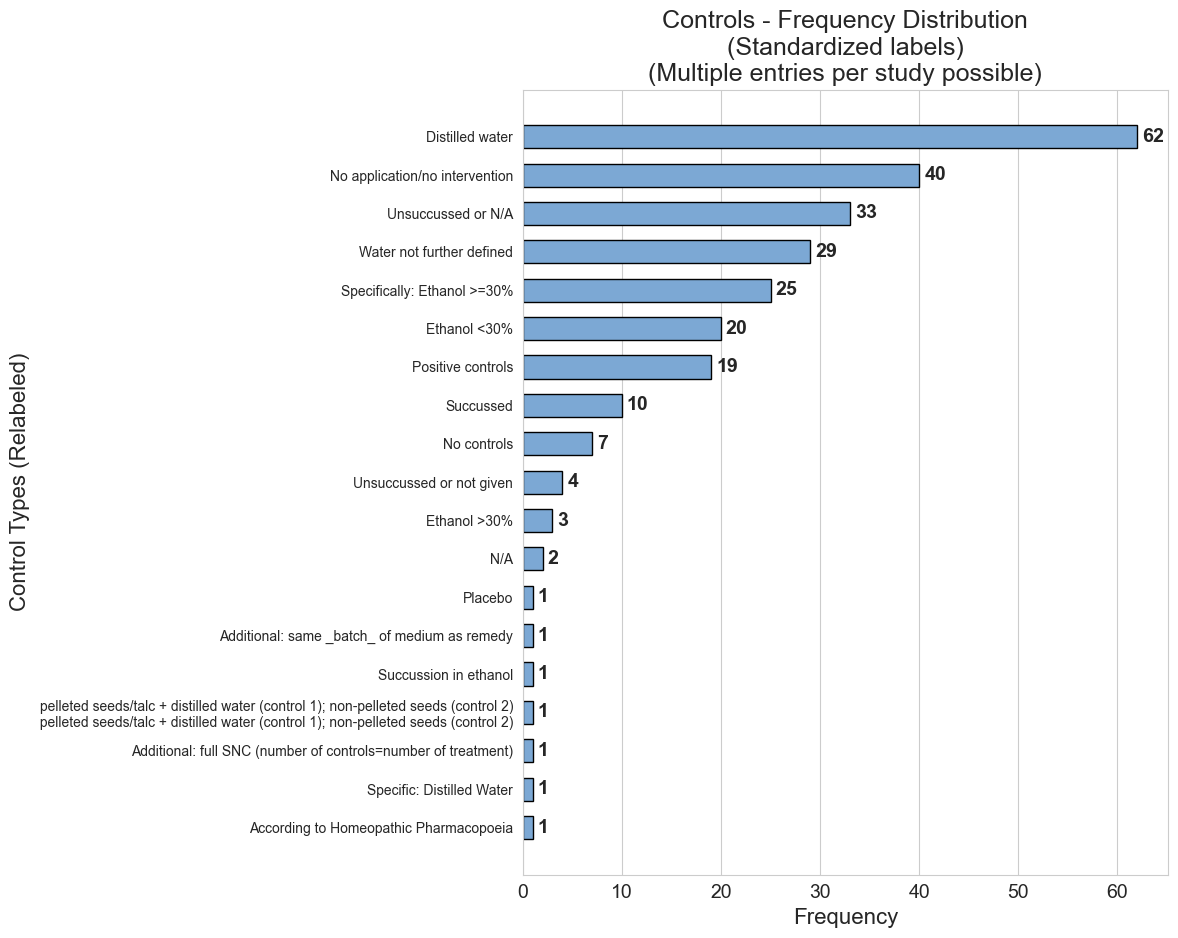


Controls (Relabeled) - Summary:
- Total entries: 261
- Unique control types: 19
- Most common: Distilled water (62 entries)
- Least common: According to Homeopathic Pharmacopoeia (1 entries)

Standardized Control Types:
 1. According to Homeopathic Pharmacopoeia
 2. Specific: Distilled Water
 3. Additional: full SNC (number of controls=number of treatment)
 4. pelleted seeds/talc + distilled water (control 1); non-pelleted seeds (control 2)
 pelleted seeds/talc + distilled water (control 1); non-pelleted seeds (control 2)
 5. Succussion in ethanol
 6. Additional: same _batch_ of medium as remedy
 7. Placebo
 8. N/A
 9. Ethanol >30%
10. Unsuccussed or not given
11. No controls
12. Succussed
13. Positive controls
14. Ethanol <30%
15. Specifically: Ethanol >=30%
16. Water not further defined
17. Unsuccussed or N/A
18. No application/no intervention
19. Distilled water


In [356]:
#
# NEEDS OVERHAUL -----------------
#

# Create relabeled Controls column with standardized labels and generate horizontal bar chart

# Create comprehensive mapping dictionary for control label standardization
controls_mapping = {
    'Distilled Water': 'Distilled water',
    'pelleted seeds/talc + distilled water (control 1); non-pelleted seeds (control 2)': 'Other',
    'ethanol 70%': 'Ethanol >30%',
    'Distilled water': 'Distilled water',
    'Specifically: Ethanol 70%': 'Ethanol >30%',
    'Succused in same medium as remedy': 'Succussed',
    'No controls': 'No controls',
    'Succussed': 'Succussed',
    'Specifically: Ethanol >30%': 'Ethanol >30%',
    'Positive controls': 'Positive controls',
    'Unsuccused and different medium as remedy': 'Unsuccussed or not given',
    'Specifically: Ethanol <30%': 'Ethanol <30%',
    'Unsuccused in same medium as remedy': 'Unsuccussed or not given',
    'No application/no intervention': 'No application/no intervention',
    'Specifically: Distilled water': 'Distilled water',
    'Unsuccused or N/A': 'Unsuccussed or not given',
    'Specifically: Water': 'Water not further defined',
    'N/A': 'N/A'
}


# Function to relabel individual control entries
def relabel_control_entry(entry):
    entry = entry.strip()
    return controls_mapping.get(entry, entry)  # Return mapped value or original if not found


# --- RAWDATA warnings for empty fields ---
for idx, row in df.iterrows():
    if pd.isna(row['Controls']) or str(row['Controls']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty Controls field")

# Clean the original Controls column — 'N/A' is a legit label
controls_series_original = (
    df['Controls']
    .dropna()
    .astype(str)
    .str.strip()
)
controls_series_original = controls_series_original[controls_series_original != '']

# Apply relabeling to each cell (handling comma-separated entries)
controls_relabeled_series = []
controls_relabeled_index = []
for idx, cell_value in controls_series_original.items():
    # Split by comma, relabel each entry, then rejoin
    entries = [entry.strip() for entry in cell_value.split(',')]
    relabeled_entries = [relabel_control_entry(entry) for entry in entries]
    controls_relabeled_series.append(', '.join(relabeled_entries))
    controls_relabeled_index.append(idx)

# Create controls_relabeled column with proper index
controls_relabeled = pd.Series(controls_relabeled_series, index=controls_relabeled_index)

# Split relabeled controls on comma, explode into individual entries, and clean up
controls_relabeled_exploded = (
    controls_relabeled
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
controls_relabeled_exploded = controls_relabeled_exploded[controls_relabeled_exploded != '']

# Get frequency counts and sort by frequency (highest first for horizontal bars)
controls_relabeled_counts = controls_relabeled_exploded.value_counts().sort_values(ascending=True)

# Display comparison of before and after relabeling
print("RELABELING COMPARISON:")
print("=" * 50)
original_exploded = (controls_series_original.str.split(',').explode().astype(str).str.strip())
original_exploded = original_exploded[original_exploded != '']
original_counts = original_exploded.value_counts()
print(f"Original: {len(original_counts)} unique labels, {len(original_exploded)} total entries")
print(f"Relabeled: {len(controls_relabeled_counts)} unique labels, {len(controls_relabeled_exploded)} total entries")

# Create horizontal bar chart using matplotlib
fig_controls_relabeled, ax_controls_relabeled = plt.subplots(figsize=hbar_figsize(len(controls_relabeled_counts)))

# Create horizontal bars with proper positioning
y_positions = range(len(controls_relabeled_counts))
bars = ax_controls_relabeled.barh(y_positions, controls_relabeled_counts.values, edgecolor='black', height=BAR_H)

# Set y-axis labels and positions
ax_controls_relabeled.set_yticks(y_positions)
ax_controls_relabeled.set_yticklabels(controls_relabeled_counts.index, fontsize=10)

# Customize the plot
ax_controls_relabeled.set_xlabel('Frequency')
ax_controls_relabeled.set_ylabel('Control Types (Relabeled)')
ax_controls_relabeled.set_title('Controls - Frequency Distribution\n(Standardized labels)\n(Multiple entries per study possible)')

# Add value labels on the bars
for i, (control, freq) in enumerate(controls_relabeled_counts.items()):
    ax_controls_relabeled.text(freq + 0.5, i, str(freq), va='center', fontweight='bold')

ax_controls_relabeled.yaxis.grid(False)

# Save and display
plt.tight_layout()
fig_controls_relabeled.savefig('controls_relabeled_horizontal_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nControls (Relabeled) - Summary:")
print(f"- Total entries: {len(controls_relabeled_exploded)}")
print(f"- Unique control types: {len(controls_relabeled_counts)}")
print(f"- Most common: {controls_relabeled_counts.index[-1]} ({controls_relabeled_counts.iloc[-1]} entries)")
print(f"- Least common: {controls_relabeled_counts.index[0]} ({controls_relabeled_counts.iloc[0]} entries)")

# Show the relabeled control types
print(f"\nStandardized Control Types:")
for i, control in enumerate(controls_relabeled_counts.index, 1):
    print(f"{i:2d}. {control}")


### Controls Pie Chart (disabled)

In [357]:
# #
# # NEEDS OVERHAUL -----------------
# #
#
#
# controls_mapping_pie = {
#       'Distilled Water': 'Distilled water',
#       'pelleted seeds/talc + distilled water (control 1); non-pelleted seeds (control 2)': 'Other',
#       'ethanol 70%': 'Ethanol >30%',
#       'Distilled water': 'Distilled water',
#       'Specifically: Ethanol 70%': 'Ethanol >30%',
#       'Succused in same medium as remedy': 'Succussed',
#       'No controls': 'No controls',
#       'Succussed': 'Succussed',
#       'Specifically: Ethanol >30%': 'Ethanol >30%',
#       'Positive controls': 'Positive controls',
#       'Unsuccused and different medium as remedy': 'Unsuccussed or not given',
#       'Specifically: Ethanol <30%': 'Ethanol <30%',
#       'Unsuccused in same medium as remedy': 'Unsuccussed or not given',
#       'No application/no intervention': 'No application/no intervention',
#       'Specifically: Distilled water': 'Distilled water',
#       'Unsuccused or N/A': 'Unsuccussed or not given',
#       'Unsuccussed or N/A': 'Unsuccussed or not given',  # Fixed spelling variation
#       'Specifically: Water': 'Water not further defined',
#       'N/A': 'N/A'
# }
#
#   # Function to categorize each study's succussion status
#   def categorize_succussion_status(cell_value):
#       if pd.isna(cell_value) or str(cell_value).strip() in ['', 'N/A']:
#           return None  # Exclude studies with no content
#
#       # Split by comma and relabel each entry
#       entries = [entry.strip() for entry in str(cell_value).split(',')]
#       relabeled_entries = [controls_mapping_pie.get(entry, entry) for entry in entries]
#
#       # Check for target labels
#       has_succussed = 'Succussed' in relabeled_entries
#       has_unsuccussed = 'Unsuccussed or not given' in relabeled_entries
#
#       # Categorize based on presence of target labels
#       if has_succussed and has_unsuccussed:
#           return 'Both Succussed and Unsuccussed'  # Handle edge case if both present
#       elif has_succussed:
#           return 'Succussed'
#       elif has_unsuccussed:
#           return 'Unsuccussed or not given'
#       else:
#           return 'Unknown'
#
#   # Clean the original Controls column
#   controls_series_succussion = (
#       df['Controls']
#       .fillna('N/A')
#       .astype(str)
#       .str.strip()
#   )
#
#   # Apply categorization to each study
#   succussion_categories = controls_series_succussion.apply(categorize_succussion_status)
#
#   # Remove None values (excluded studies with no content)
#   succussion_categories_filtered = succussion_categories.dropna()
#
#   # Get frequency counts
#   succussion_counts = succussion_categories_filtered.value_counts()
#
#   print(f"Succussion status analysis:")
#   print(f"- Original studies: {len(df)}")
#   print(f"- Studies with control content: {len(succussion_categories_filtered)}")
#   print(f"- Excluded studies (no content): {len(df) - len(succussion_categories_filtered)}")
#
#   # Prepare data for pie chart
#   labels_succussion_status = succussion_counts.index.tolist()
#   labels_succussion_status = [add_line_breaks_to_label(lbl, strategy='word_count') for lbl in labels_succussion_status]
#   values_succussion_status = succussion_counts.values.tolist()
#
#   # Compute percentages and set label positions
#   total_succussion_status = sum(values_succussion_status)
#   percentages_succussion_status = [(v / total_succussion_status) * 100 if total_succussion_status else 0 for v in values_succussion_status]
#   percentages_cutoff = 10
#   text_positions_succussion_status = ['outside' if p < percentages_cutoff else 'inside' for p in percentages_succussion_status]
#   custom_text_succussion_status = [
#       f"{label}<br>{percent:.1f}%" if position == 'inside'
#       else f"{label} {percent:.1f}%"
#       for label, percent, position in zip(labels_succussion_status, percentages_succussion_status, text_positions_succussion_status)
#   ]
#
#   # Build pie chart (styled like the "Country of corresponding author" chart)
#   succussion_status_pie = go.Figure(
#       data=[
#           go.Pie(
#               labels=labels_succussion_status,
#               values=values_succussion_status,
#               text=custom_text_succussion_status,
#               textinfo='text',
#               textposition=text_positions_succussion_status,
#             insidetextorientation='horizontal',
#               sort=False,
#               direction='clockwise',
#               rotation=90,
#           )
#       ]
#   )
#
#   succussion_status_pie.update_traces(
#       textfont=dict(size=12, color='black'),
#       insidetextfont=dict(color='black'),
#   )
#
#
#   textfont=dict(size=12, color='black'),
#   succussion_status_pie.update_layout(
#       title='Succussion Status of Control Groups in Studies',
#       showlegend=False,
#       margin=dict(t=120, b=20, l=20, r=20)
#   )
#
#   succussion_status_pie.show()
#   succussion_status_pie.write_image('succussion_status_pie.png', width=800, height=600, scale=2)
#
#   # Print detailed breakdown
#   print(f"\nSuccussion Status Distribution:")
#   for status, count in succussion_counts.items():
#       percentage = (count / total_succussion_status * 100) if total_succussion_status else 0
#       print(f"- {status}: {count} studies ({percentage:.1f}%)")
#   print(f"Total studies analyzed: {total_succussion_status}")
#


## Outcome Measures

### Outcome Measure Frequencies

Analysis of the top 30 most frequently used outcome measures across all studies. Each study may report multiple outcome measures (comma-separated).

Total unique outcome measures: 280
Total outcome measure entries: 847

Top 30 most frequent outcome measures:


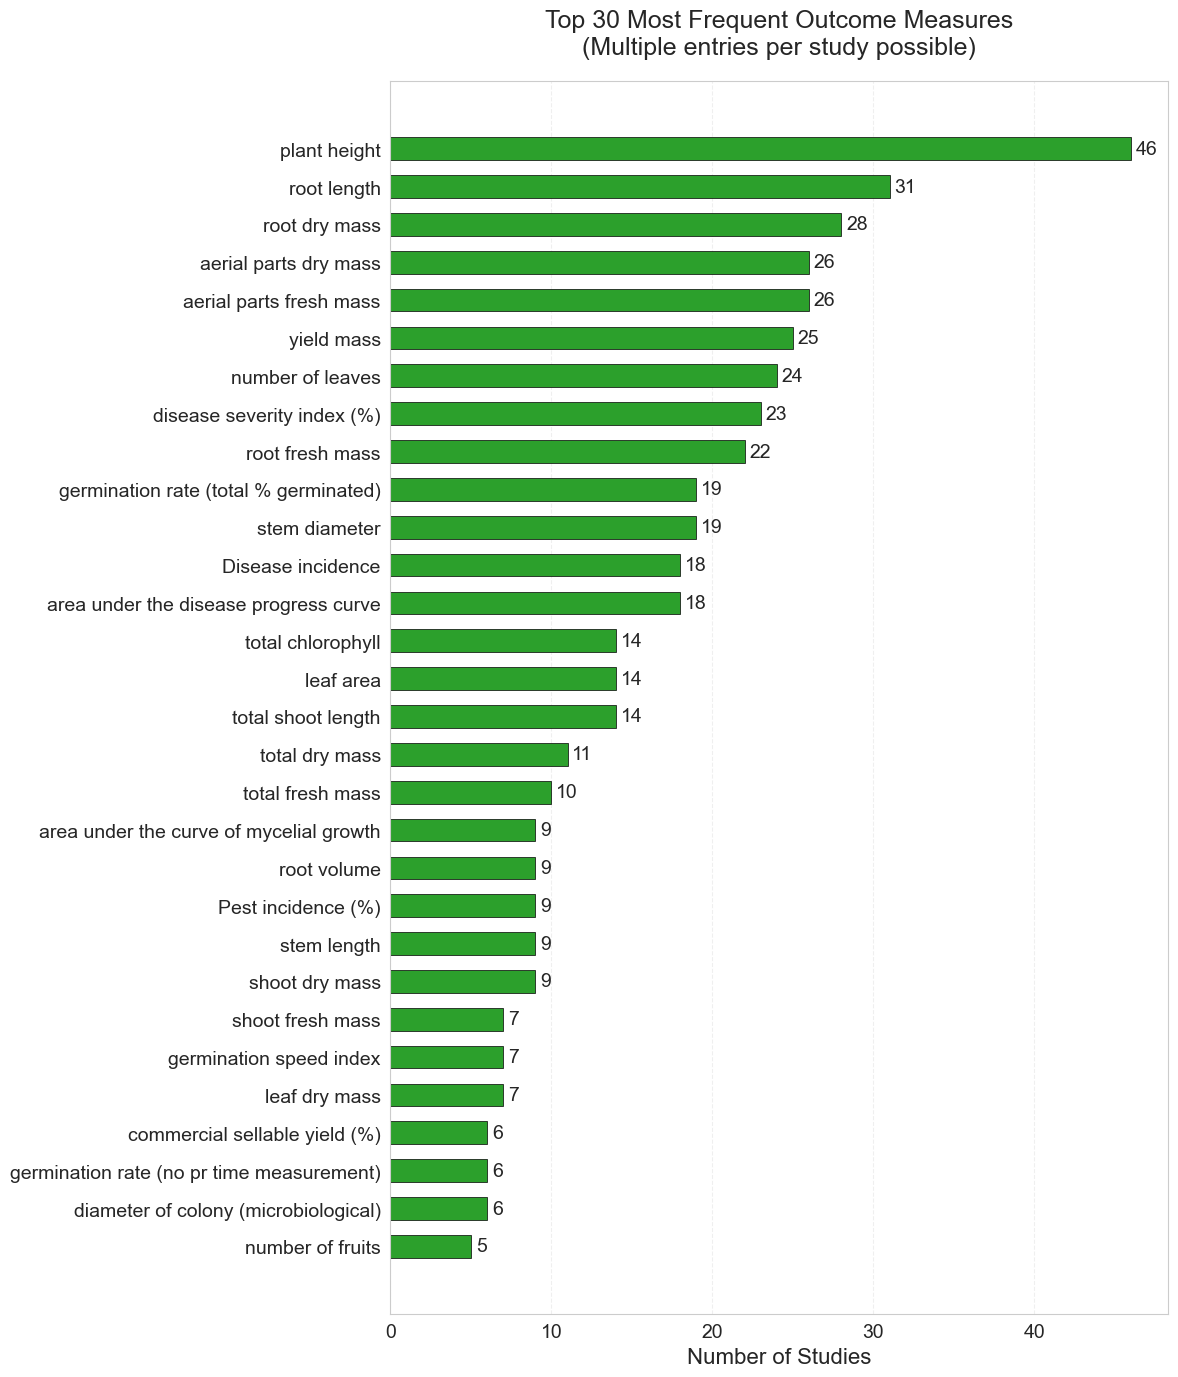


Chart saved: outcome_measures_frequency.png
Showing top 30 outcome measures out of 30 total in top 30


In [358]:
# Extract and analyze outcome measures - showing top 30 most frequent

# --- RAWDATA warnings for empty fields ---
for idx, row in df.iterrows():
    if pd.isna(row['Outcome measures (specific)']) or str(row['Outcome measures (specific)']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty Outcome measures field")
    elif 'N/A' in str(row['Outcome measures (specific)']):
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has 'N/A' in Outcome measures — needs real label")

# Clean outcome measures data — drop NaN/empty, 'N/A' passes through visibly
outcome_series = (
    df['Outcome measures (specific)']
    .dropna()
    .astype(str)
    .str.strip()
)
outcome_series = outcome_series[outcome_series != '']

# Split comma-separated outcome measures into individual entries
outcome_exploded = (
    outcome_series
    .str.split(',')
    .explode()
    .astype(str)
    .str.strip()
)
outcome_exploded = outcome_exploded[outcome_exploded != '']

# Get top 30 most frequent outcome measures
outcome_counts = outcome_exploded.value_counts().head(30)

print(f"Total unique outcome measures: {outcome_exploded.nunique()}")
print(f"Total outcome measure entries: {len(outcome_exploded)}")
print(f"\nTop 30 most frequent outcome measures:")

# Create horizontal bar chart
fig_outcome, ax_outcome = plt.subplots(figsize=hbar_figsize(len(outcome_counts)))

# Create horizontal bars (reverse order so most frequent is at top)
y_pos = range(len(outcome_counts))
ax_outcome.barh(y_pos, outcome_counts.values[::-1], color='#2ca02c', edgecolor='black', linewidth=0.5, height=BAR_H)

# Customize axes
ax_outcome.set_yticks(y_pos)
ax_outcome.set_yticklabels(outcome_counts.index[::-1], fontsize=TICK_FS)
ax_outcome.set_xlabel('Number of Studies', fontsize=AXIS_LABEL_FS)
ax_outcome.set_title('Top 30 Most Frequent Outcome Measures\n(Multiple entries per study possible)', fontsize=TITLE_FS, pad=20)

# Add value labels on bars
for i, (idx, value) in enumerate(zip(y_pos, outcome_counts.values[::-1])):
    ax_outcome.text(value + 0.3, idx, str(int(value)), va='center', fontsize=DATA_LABEL_FS)

# Add grid for better readability
ax_outcome.grid(axis='x', alpha=0.3, linestyle='--')
ax_outcome.set_axisbelow(True)
ax_outcome.yaxis.grid(False)

# Save and display
plt.tight_layout()
fig_outcome.savefig('outcome_measures_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print(f"\nChart saved: outcome_measures_frequency.png")
print(f"Showing top 30 outcome measures out of {outcome_counts.shape[0]} total in top 30")


# Significance correlations


## Significance preamble

### Outcome vs Significance Validation

This validation checks whether significant results reported for each study are a proper subset of the outcome measures. Discrepancies may indicate:
- Typos or spelling inconsistencies
- Data entry errors
- Missing outcome measures in the documentation
- Different terminology used between columns


In [359]:
# Data Validation - Outcome Measures vs Significant Results
# Validates that significant results are proper subsets of outcome measures

# Define column names
outcome_col = 'Outcome measures (specific)'
sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Normalization function
def normalize_items(text):
    """Normalize comma-separated text into a set of cleaned items."""
    if pd.isna(text):
        return set()
    
    # Convert to string, replace newlines with spaces
    text = str(text).replace('\n', ' ')
    
    # Lowercase and strip
    text = text.lower().strip()
    
    # Split by comma and clean each item
    items = [item.strip() for item in text.split(',') if item.strip()]
    
    return set(items)

# Validate each row
validation_results = []

for idx, row in df.iterrows():
    outcomes = normalize_items(row[outcome_col])
    sig_text = row[sig_col]
    
    # Check for special valid cases
    if pd.notna(sig_text):
        sig_text_lower = str(sig_text).lower()
        # Skip if the text indicates no significant results
        if 'not significant' in sig_text_lower or 'no significance calculated' in sig_text_lower:
            continue
    
    significant = normalize_items(sig_text)
    
    # Only check rows with significant results
    if len(significant) > 0:
        # Check if significant is subset of outcomes
        if not significant.issubset(outcomes):
            missing = significant - outcomes
            
            # Get sample data for context
            outcome_list = sorted(outcomes)
            sig_list = sorted(significant)
            
            validation_results.append({
                'Row Index': idx,
                'Covidence #': int(row['Covidence #']) if pd.notna(row['Covidence #']) else 'N/A',
                'Missing Items Count': len(missing),
                'Missing Items': ', '.join(sorted(missing)),
                'Outcome Count': len(outcomes),
                'Significant Count': len(significant),
                'Sample Outcomes': ', '.join(outcome_list),
                'Sample Significant': ', '.join(sig_list)
            })

# Create results DataFrame
validation_df = pd.DataFrame(validation_results)

# Print summary statistics
print("=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)
print(f"Total rows in dataset: {len(df)}")
print(f"Rows with outcome measures: {df[outcome_col].notna().sum()}")
print(f"Rows with significant results: {df[sig_col].notna().sum()}")
print(f"\nRows with validation issues: {len(validation_df)}")

if len(validation_df) > 0:
    total_with_sig = df[sig_col].notna().sum()
    print(f"Percentage of significant results with issues: {len(validation_df)/total_with_sig*100:.1f}%")
    print(f"\nTotal missing items across all problematic rows: {validation_df['Missing Items Count'].sum()}")
    print(f"Average missing items per problematic row: {validation_df['Missing Items Count'].mean():.1f}")
    print(f"Max missing items in a single row: {validation_df['Missing Items Count'].max()}")
    
    print("\n" + "=" * 80)
    print("PROBLEMATIC STUDIES (sorted by number of missing items)")
    print("=" * 80)
    
    # Sort by missing items count and display
    validation_df_sorted = validation_df.sort_values('Missing Items Count', ascending=False)
    
    # Configure display options
    pd.set_option('display.max_colwidth', 80)
    pd.set_option('display.width', None)
    
    # Display the validation results
    display(validation_df_sorted)
    
    print("\n" + "=" * 80)
    print("DETAILED EXAMPLES (Top 5 Most Problematic)")
    print("=" * 80)
    
    for i, (idx, row_data) in enumerate(validation_df_sorted.head(5).iterrows()):
        print(f"\n{i+1}. Row {row_data['Row Index']}, Covidence #{row_data['Covidence #']}")
        print(f"   Missing Items ({row_data['Missing Items Count']}): {row_data['Missing Items']}")
        print(f"   Context: {row_data['Outcome Count']} outcomes, {row_data['Significant Count']} significant")
    
    # Save to CSV for further analysis
    output_file = 'validation_results.csv'
    validation_df_sorted.to_csv(output_file, index=False)
    print(f"\n\nFull validation results saved to: {output_file}")
    
else:
    print("\n✓ All validation checks passed!")
    print("All significant results are proper subsets of their corresponding outcome measures.")


VALIDATION SUMMARY
Total rows in dataset: 160
Rows with outcome measures: 160
Rows with significant results: 144

Rows with validation issues: 35
Percentage of significant results with issues: 24.3%

Total missing items across all problematic rows: 41
Average missing items per problematic row: 1.2
Max missing items in a single row: 3

PROBLEMATIC STUDIES (sorted by number of missing items)


,Row Index,Covidence #,Missing Items Count,Missing Items,Outcome Count,Significant Count,Sample Outcomes,Sample Significant
33,177,11863,3,"area under the curve of mycelial growth, total flavonoid content (%), total ...",1,4,microbiological growth inhibition (%),"area under the curve of mycelial growth, microbiological growth inhibition (..."
19,102,6162,2,"aerial parts fresh mass, plant height",11,11,"leaf area, number of leaves, number of nematodes in roots, number of nematod...","aerial parts fresh mass, leaf area, number of leaves, number of nematodes in..."
16,88,2242,2,"number of floral blooms, stem fresh mass",11,10,"aerial parts dry mass, aerial parts fresh mass, leaf dry mass, leaf fresh ma...","aerial parts dry mass, aerial parts fresh mass, number of branches, number o..."
31,162,10666,2,"area under the disease progress curve, germination rate (no pr time measurem...",2,2,"area under the curve of mycelial growth, number of sclerotia","area under the disease progress curve, germination rate (no pr time measurem..."
18,91,2344,2,"fruit fresh mass, root volume",3,5,"peroxidase, phenylalanine ammonia-lyase, polyphenoloxidase","fruit fresh mass, peroxidase, phenylalanine ammonia-lyase, polyphenoloxidase..."
24,133,10591,1,injured leaf area (%),7,1,"area under the disease progress curve pest incidence and severity (thrips), ...",injured leaf area (%)
20,110,6190,1,number of floral blooms,9,5,"number of branches, number of flower buds, number of leaves, root length, so...","number of branches, number of floral blooms, number of leaves, root length, ..."
21,111,6192,1,nematod population per 2g of roots,11,4,"leaf fresh mass, leaf protein content %, nematode population per 2.4 g of ro...","leaf protein content %, nematod population per 2g of roots, number of root g..."
22,113,7201,1,oil content mass %,8,2,"aerial parts dry mass, aerial parts fresh mass, flower buds dry mass, leaf a...","aerial parts fresh mass, oil content mass %"
23,131,10584,1,no significance,3,1,"leaf dry mass, leaf number;leaf area, shoot dry mass",no significance



DETAILED EXAMPLES (Top 5 Most Problematic)

1. Row 177, Covidence #11863
   Missing Items (3): area under the curve of mycelial growth, total flavonoid content (%), total phenolic content
   Context: 1 outcomes, 4 significant

2. Row 102, Covidence #6162
   Missing Items (2): aerial parts fresh mass, plant height
   Context: 11 outcomes, 11 significant

3. Row 88, Covidence #2242
   Missing Items (2): number of floral blooms, stem fresh mass
   Context: 11 outcomes, 10 significant

4. Row 162, Covidence #10666
   Missing Items (2): area under the disease progress curve, germination rate (no pr time measurement)
   Context: 2 outcomes, 2 significant

5. Row 91, Covidence #2344
   Missing Items (2): fruit fresh mass, root volume
   Context: 3 outcomes, 5 significant


Full validation results saved to: validation_results.csv


### Significance Rate Summary

In [360]:
# Significance Rate Analysis
# Calculate average percentage of outcomes that were significant

print("=" * 80)
print("SIGNIFICANCE RATE ANALYSIS")
print("=" * 80)

# Reuse column names and normalization function from validation code above
outcome_col = 'Outcome measures (specific)'
sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Part 1: Calculate average significance rate for valid studies
# NOW INCLUDES studies with 'not significant' or 'no significance calculated' (treated as 0%)
significance_rates = []
distribution = {
    '0%': 0,
    '1-25%': 0,
    '26-50%': 0,
    '51-75%': 0,
    '76-99%': 0,
    '100%': 0
}

for idx, row in df.iterrows():
    sig_text = row[sig_col]
    
    # Skip empty cells (NaN or empty string) — these should be filled after consensus
    if pd.isna(sig_text) or str(sig_text).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty significance field")
        continue
    
    sig_text_lower = str(sig_text).lower().strip()
    
    # Check for special text cases - treat as 0% significance
    if 'not significant' in sig_text_lower or 'no significance calculated' in sig_text_lower:
        # Count these as 0% significance rate
        significance_rates.append(0.0)
        distribution['0%'] += 1
        continue
    
    # Get normalized sets
    outcomes = normalize_items(row[outcome_col])
    significant = normalize_items(sig_text)
    
    # Skip if validation error (significant not subset of outcomes)
    if len(significant) > 0 and len(outcomes) > 0:
        if not significant.issubset(outcomes):
            continue  # Skip validation errors
    
    # Calculate significance rate for this study
    if len(outcomes) > 0 and len(significant) > 0:
        rate = (len(significant) / len(outcomes)) * 100
        significance_rates.append(rate)
        
        # Categorize for distribution
        if rate == 0:
            distribution['0%'] += 1
        elif rate <= 25:
            distribution['1-25%'] += 1
        elif rate <= 50:
            distribution['26-50%'] += 1
        elif rate <= 75:
            distribution['51-75%'] += 1
        elif rate < 100:
            distribution['76-99%'] += 1
        else:  # 100%
            distribution['100%'] += 1
    elif len(outcomes) > 0 and len(significant) == 0:
        # Has outcomes but no significant results - also 0%
        significance_rates.append(0.0)
        distribution['0%'] += 1

# Calculate average
avg_rate = sum(significance_rates) / len(significance_rates) if significance_rates else 0

print("\nPART 1: AVERAGE SIGNIFICANCE RATE (Valid Studies)")
print("-" * 55)
print("Includes: Validated studies + 'not significant' + 'no significance calculated' (as 0%)")
print("Excludes: Empty fields (see warnings above), validation errors\n")
print(f"Valid studies analyzed: {len(significance_rates)}")
print(f"Average percentage of outcomes that were significant: {avg_rate:.1f}%\n")

print("Details:")
print(f"- Studies with 0% significance: {distribution['0%']}")
print(f"- Studies with 1-25% significance: {distribution['1-25%']}")
print(f"- Studies with 26-50% significance: {distribution['26-50%']}")
print(f"- Studies with 51-75% significance: {distribution['51-75%']}")
print(f"- Studies with 76-99% significance: {distribution['76-99%']}")
print(f"- Studies with 100% significance: {distribution['100%']}")

# Part 2: Categorical breakdown
print("\n" + "=" * 80)
print("PART 2: CATEGORICAL BREAKDOWN (All Studies)")
print("-" * 44)
print("Note: Categories can overlap - a study may appear in multiple categories.\n")

total_studies = len(df)
print(f"Total studies in dataset: {total_studies}\n")

# Category a: Any significant outcomes
count_any_sig = 0
for idx, row in df.iterrows():
    sig_text = row[sig_col]
    if pd.notna(sig_text):
        sig_text_lower = str(sig_text).lower().strip()
        # Exclude special cases
        if 'not significant' not in sig_text_lower and 'no significance calculated' not in sig_text_lower:
            significant = normalize_items(sig_text)
            if len(significant) > 0:
                count_any_sig += 1

# Category b: "not significant"
count_not_sig = 0
for idx, row in df.iterrows():
    sig_text = row[sig_col]
    if pd.notna(sig_text):
        if 'not significant' in str(sig_text).lower():
            count_not_sig += 1

# Category c: "no significance calculated"
count_no_calc = 0
for idx, row in df.iterrows():
    sig_text = row[sig_col]
    if pd.notna(sig_text):
        if 'no significance calculated' in str(sig_text).lower():
            count_no_calc += 1

# Category d: Empty significance field (NaN or empty string)
count_blank = 0
for idx, row in df.iterrows():
    sig_text = row[sig_col]
    if pd.isna(sig_text) or str(sig_text).strip() == '':
        count_blank += 1

# Category e: ALL outcomes significant (100%)
count_all_sig = distribution['100%']

# Validation issues (from earlier analysis)
count_validation_issues = len(validation_df) if len(validation_df) > 0 else 0

# Print categories
print(f"a) Studies with any significant outcomes: {count_any_sig} ({count_any_sig/total_studies*100:.1f}%)")
print(f"b) Studies marked 'not significant': {count_not_sig} ({count_not_sig/total_studies*100:.1f}%)")
print(f"c) Studies with 'no significance calculated': {count_no_calc} ({count_no_calc/total_studies*100:.1f}%)")
print(f"d) Studies with empty significance field: {count_blank} ({count_blank/total_studies*100:.1f}%)")
print(f"e) Studies with ALL outcomes significant (100%): {count_all_sig} ({count_all_sig/total_studies*100:.1f}%)")
print(f"\nValidation: Studies with data quality issues: {count_validation_issues} ({count_validation_issues/total_studies*100:.1f}%)")

print("\n" + "=" * 80)


SIGNIFICANCE RATE ANALYSIS
  RAWDATA CLEANUP NEEDED: Covidence #2603 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #2759 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #3654 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #4316 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #5097 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #2344 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #5110 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #5112 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #10567 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #10584 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #3812 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #3812 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #10694 has e

### Shared Significance Data

In [361]:
# Shared intermediate: per-item outcome significance data
# Computed once here, reused by the outcome measures chart and all cluster charts below.
# Each outcome item (lowercased, stripped) gets a total count and a significance count.

from collections import Counter

outcome_col = 'Outcome measures (specific)'
sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Per-item counters, keyed by lowercase stripped item name
outcome_item_totals = Counter()      # item -> number of studies measuring it
outcome_item_sig_counts = Counter()  # item -> number of studies finding it significant

# Original-case mapping: lowercase -> first-seen original form (for chart labels)
outcome_item_orig_case = {}

for idx, row in df.iterrows():
    # Parse all outcome items for this study
    items_lc = normalize_items(row[outcome_col])  # set of lowercase items
    if not items_lc:
        continue

    # Track original-case form for display (split manually to preserve case)
    if pd.notna(row[outcome_col]):
        for raw_item in str(row[outcome_col]).split(','):
            raw_stripped = raw_item.strip()
            lc = raw_stripped.lower().strip()
            if lc and lc not in outcome_item_orig_case:
                outcome_item_orig_case[lc] = raw_stripped

    # Count totals
    for item in items_lc:
        outcome_item_totals[item] += 1

    # Parse significance column
    sig_text = row[sig_col]
    if pd.isna(sig_text) or str(sig_text).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty significance field")
        continue
    sig_text_lower = str(sig_text).lower().strip()
    if 'not significant' in sig_text_lower or 'no significance calculated' in sig_text_lower:
        continue

    # Count significant items
    sig_set = normalize_items(sig_text)
    for item in items_lc:
        if item in sig_set:
            outcome_item_sig_counts[item] += 1

print(f"Unique outcome items tracked: {len(outcome_item_totals)}")
print(f"Items with >= 1 significant finding: {len(outcome_item_sig_counts)}")


  RAWDATA CLEANUP NEEDED: Covidence #2603 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #2759 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #3654 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #4316 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #5097 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #2344 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #5110 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #5112 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #10567 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #2703 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #10584 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #3812 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #3812 has empty significance field
  RAWDATA CLEANUP NEEDED: Covidence #10694 has empty significance field
  R

## Outcome Significance

### Outcome Significance Stacked Bar

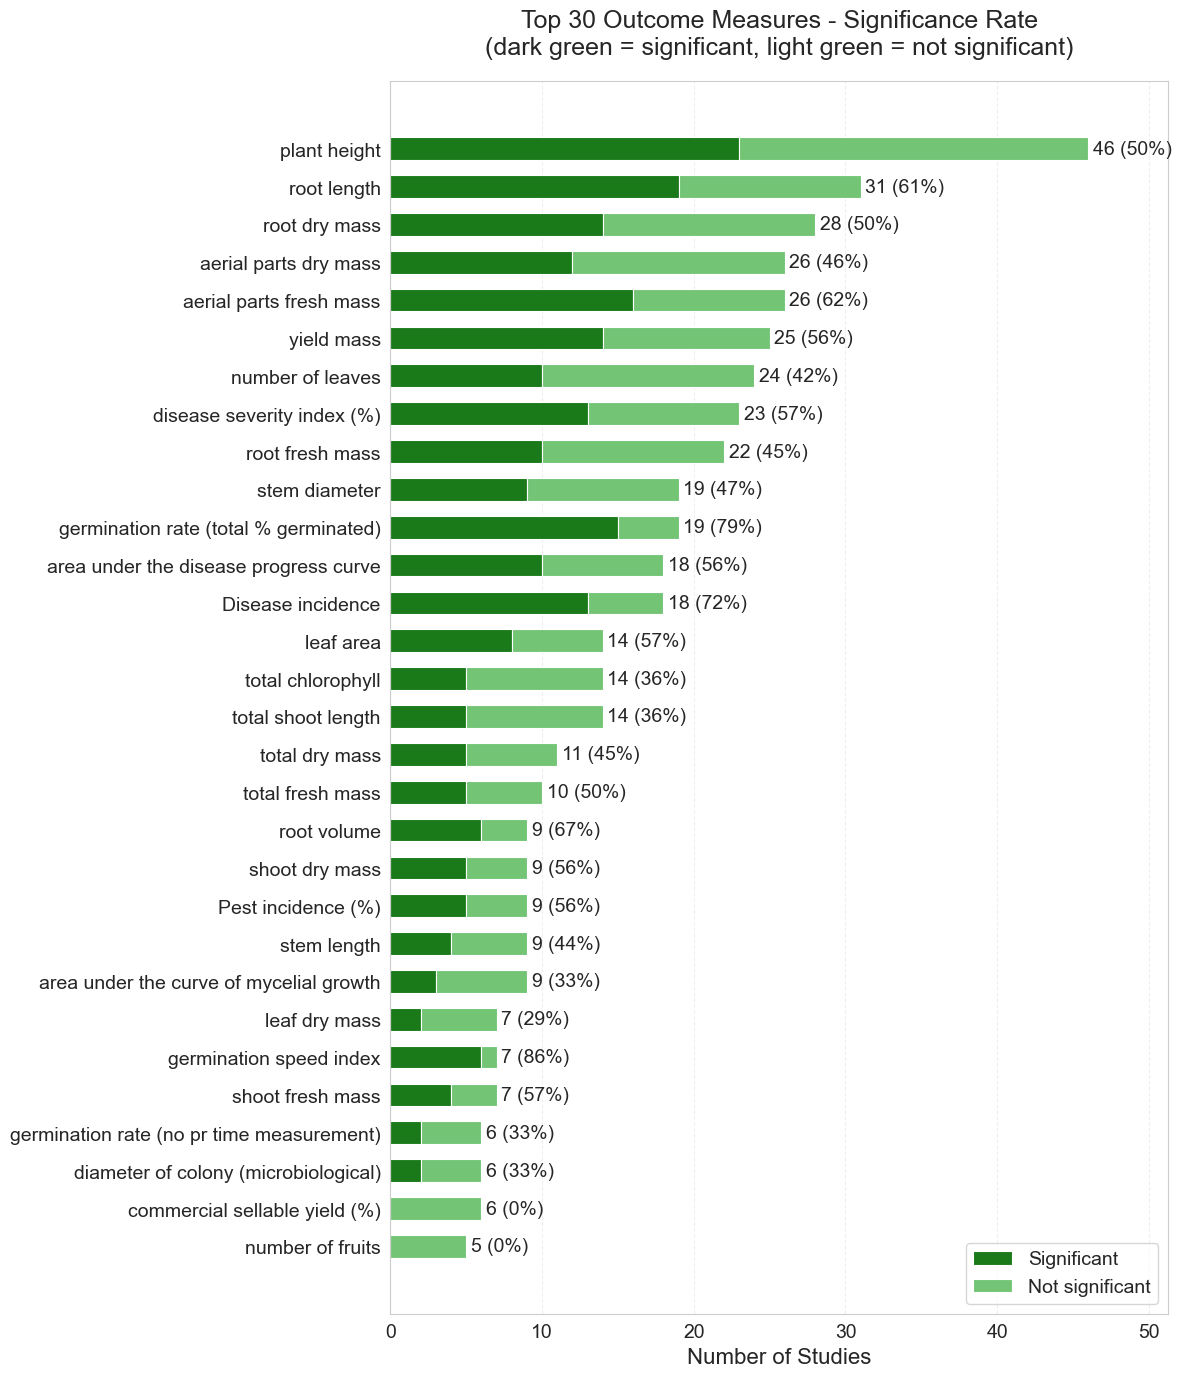

In [362]:
# Stacked bar chart: outcome measures with significance overlay
# Dark green = also significant, light green = measured but not significant
# Uses shared outcome_item_totals, outcome_item_sig_counts, outcome_item_orig_case
# computed in the cell above.

# Step 1: Top 30 outcomes by total count, with original-case labels
top30_items = outcome_item_totals.most_common(30)
top30_orig_labels = [outcome_item_orig_case.get(item, item) for item, _ in top30_items]

# Step 2: Build arrays in reverse order (so most frequent is at top)
labels = top30_orig_labels[::-1]
totals = [count for _, count in top30_items][::-1]
sig_vals = [outcome_item_sig_counts.get(item, 0) for item, _ in top30_items][::-1]
not_sig_vals = [t - s for t, s in zip(totals, sig_vals)]

# Step 4: Plot stacked horizontal bar chart
fig_stacked, ax_stacked = plt.subplots(figsize=hbar_figsize(len(labels)))

y_pos = range(len(labels))

# Dark green = significant
ax_stacked.barh(y_pos, sig_vals, color='#1a7a1a', edgecolor='white', linewidth=0.8, height=BAR_H, label='Significant')
# Light green = not significant (stacked on top)
ax_stacked.barh(y_pos, not_sig_vals, left=sig_vals, color='#74c476', edgecolor='white', linewidth=0.8, height=BAR_H, label='Not significant')

# Axis labels and title
ax_stacked.set_yticks(y_pos)
ax_stacked.set_yticklabels(labels, fontsize=TICK_FS)
ax_stacked.set_xlabel('Number of Studies', fontsize=AXIS_LABEL_FS)
ax_stacked.set_title(
    'Top 30 Outcome Measures - Significance Rate\n(dark green = significant, light green = not significant)',
    fontsize=TITLE_FS, pad=20
)

# Value labels at end of each bar: total count and % significant
for i, (total, sig) in enumerate(zip(totals, sig_vals)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_stacked.text(total + 0.3, i, f'{total} ({pct:.0f}%)', va='center', fontsize=DATA_LABEL_FS)

# Extend x-axis to fit text labels (approx 3 extra characters of space)
max_val = max(totals)
ax_stacked.set_xlim(right=max_val + 0.3 + len(f'{max_val} (100%)') * max_val * 0.012)

ax_stacked.legend(loc='lower right', fontsize=LEGEND_FS)

ax_stacked.grid(axis='x', alpha=0.3, linestyle='--')
ax_stacked.set_axisbelow(True)
ax_stacked.yaxis.grid(False)

plt.tight_layout()
fig_stacked.savefig('outcome_measures_significance_stacked.png', dpi=300, bbox_inches='tight')
plt.show()


### Claude-Clustered Outcome Significance

Clusters found: 16
  Vegetative Growth: 143 total, 69 significant (48%)
  Pest & Disease Assessment: 112 total, 63 significant (56%)
  Biomass: 110 total, 58 significant (53%)
  Root Development: 100 total, 55 significant (55%)
  Reproductive & Yield: 85 total, 36 significant (42%)
  Biochemical & Physiological: 77 total, 42 significant (55%)
  Other: 45 total, 15 significant (33%)
  Germination & Emergence: 40 total, 28 significant (70%)
  Entomological / Zoological: 32 total, 21 significant (66%)
  Microbiological (in vitro): 27 total, 13 significant (48%)
  Nutrient Content & Uptake: 25 total, 21 significant (84%)
  Water Relations & Gas Exchange: 21 total, 7 significant (33%)
  Fruit / Harvest Quality: 20 total, 1 significant (5%)
  Morphometrics & Anatomy: 5 total, 3 significant (60%)
  Soil Properties: 3 total, 3 significant (100%)
  Other / Not applicable: 2 total, 1 significant (50%)

Unmatched outcome measures grouped into 'Other' (41 unique):
  'pest incidence': 2 occurrence(

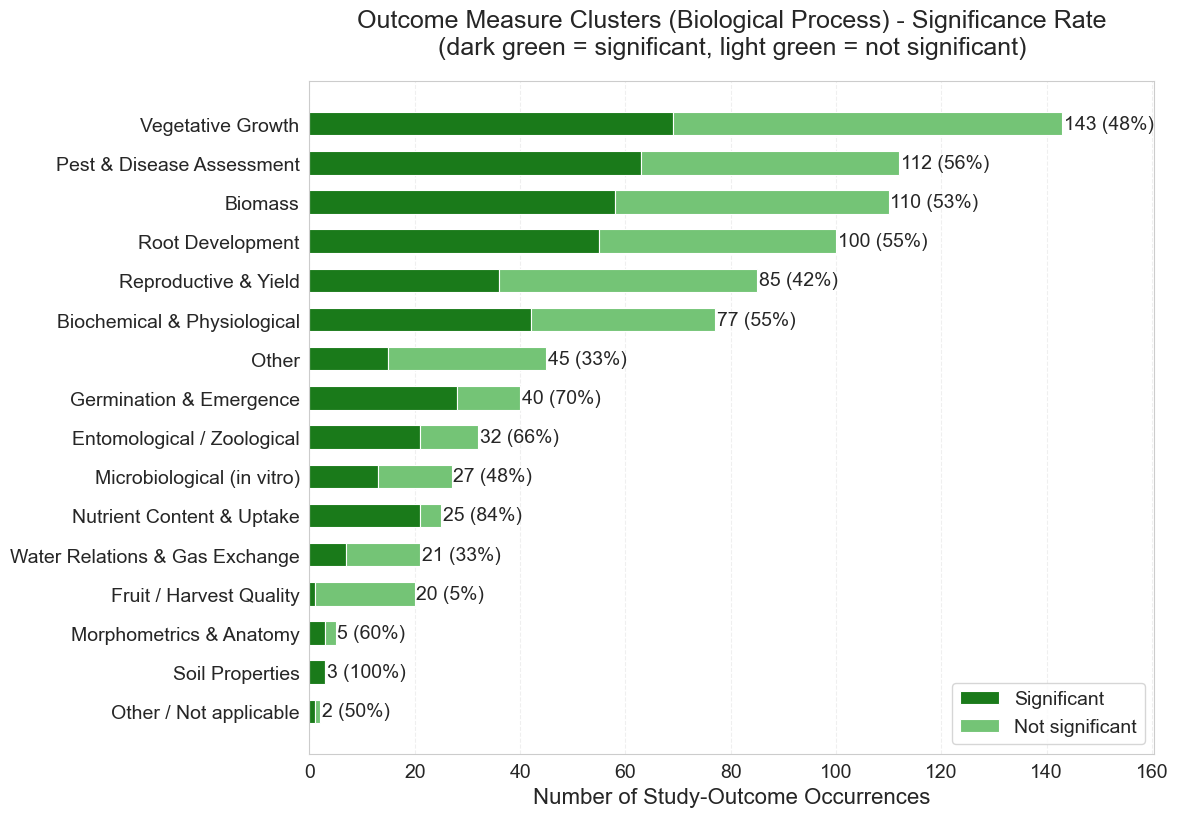

Chart saved: cluster_significance_stacked_biological.png


In [363]:
# Stacked bar chart: outcome measure clusters with significance overlay
# Uses Claude_Clusters.xlsx sheet 3 as lookup: Outcome Measure -> Biological Process Cluster
# Unmatched outcome measures are grouped into "Other"
# Uses shared outcome_item_totals and outcome_item_sig_counts from upstream cell.

from collections import Counter

# Step 1: Load cluster lookup from Claude_Clusters.xlsx (third sheet, index 2)
clusters_df = pd.read_excel('Claude_Clusters.xlsx', sheet_name=2)
cluster_lookup = {
    str(row['Outcome Measure (specific)']).lower().strip(): str(row['Biological Process Cluster']).strip()
    for _, row in clusters_df.iterrows()
    if pd.notna(row['Outcome Measure (specific)']) and pd.notna(row['Biological Process Cluster'])
}

# Step 2: Map shared item-level counts through cluster lookup
cluster_total = Counter()
cluster_sig = Counter()
unmatched_items = Counter()
for item, total_count in outcome_item_totals.items():
    if item in cluster_lookup:
        cluster = cluster_lookup[item]
    else:
        cluster = 'Other'
        unmatched_items[item] += total_count
    cluster_total[cluster] += total_count
    cluster_sig[cluster] += outcome_item_sig_counts.get(item, 0)

# Step 3: Build sorted arrays (by total count, most frequent at top)
sorted_clusters = sorted(cluster_total.keys(), key=lambda c: cluster_total[c])
labels = sorted_clusters  # ascending → most frequent will be at top after barh
totals = [cluster_total[c] for c in labels]
sig_vals = [cluster_sig[c] for c in labels]
not_sig_vals = [t - s for t, s in zip(totals, sig_vals)]

print(f"Clusters found: {len(labels)}")
for c, t, s in sorted(zip(labels, totals, sig_vals), key=lambda x: -x[1]):
    pct = s / t * 100 if t > 0 else 0
    print(f"  {c}: {t} total, {s} significant ({pct:.0f}%)")

print(f"\nUnmatched outcome measures grouped into 'Other' ({len(unmatched_items)} unique):")
for item, count in sorted(unmatched_items.items(), key=lambda x: -x[1]):
    print(f"  '{item}': {count} occurrence(s)")

# Step 5: Plot stacked horizontal bar chart
fig_cl, ax_cl = plt.subplots(figsize=hbar_figsize(len(labels)))

y_pos = range(len(labels))

ax_cl.barh(y_pos, sig_vals, color='#1a7a1a', edgecolor='white', linewidth=0.8,
           height=BAR_H, label='Significant')
ax_cl.barh(y_pos, not_sig_vals, left=sig_vals, color='#74c476', edgecolor='white',
           linewidth=0.8, height=BAR_H, label='Not significant')

ax_cl.set_yticks(y_pos)
ax_cl.set_yticklabels(labels, fontsize=TICK_FS)
ax_cl.set_xlabel('Number of Study-Outcome Occurrences', fontsize=AXIS_LABEL_FS)
ax_cl.set_title(
    'Outcome Measure Clusters (Biological Process) - Significance Rate\n(dark green = significant, light green = not significant)',
    fontsize=TITLE_FS, pad=20
)

for i, (total, sig) in enumerate(zip(totals, sig_vals)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_cl.text(total + 0.3, i, f'{total} ({pct:.0f}%)', va='center', fontsize=DATA_LABEL_FS)

max_val = max(totals)
ax_cl.set_xlim(right=max_val + 0.3 + len(f'{max_val} (100%)') * max_val * 0.012)

ax_cl.legend(loc='lower right', fontsize=LEGEND_FS)
ax_cl.grid(axis='x', alpha=0.3, linestyle='--')
ax_cl.set_axisbelow(True)
ax_cl.yaxis.grid(False)

plt.tight_layout()
fig_cl.savefig('cluster_significance_stacked_biological.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: cluster_significance_stacked_biological.png")


### Hand-Clustered Outcome Significance

General clusters found: 8
  Morphometrics: 445 total, 213 significant (48%)
  Physiology: 108 total, 65 significant (60%)
  Pest incidence & severity: 80 total, 51 significant (64%)
  Disease incidence & severity: 76 total, 36 significant (47%)
  Metabolism: 66 total, 37 significant (56%)
  Other: 45 total, 15 significant (33%)
  Entomology: 24 total, 16 significant (67%)
  Soil fertility: 3 total, 3 significant (100%)

Unmatched outcome measures grouped into 'Other' (41 unique):
  'pest incidence': 2 occurrence(s)
  'shoot length': 2 occurrence(s)
  'chroma (c*) and hue angle (hº)]"': 2 occurrence(s)
  '"fruit colour (epidermis) - [lightness (l*)': 2 occurrence(s)
  'photosynthesis rate (adc photosynthesis meter)': 1 occurrence(s)
  'photosynthetic rate': 1 occurrence(s)
  'total flavonoid content (%) - quercetin': 1 occurrence(s)
  'number of split edible roots.': 1 occurrence(s)
  'pest severity': 1 occurrence(s)
  'seedling quality - (dickson quality index)': 1 occurrence(s)
  'ste

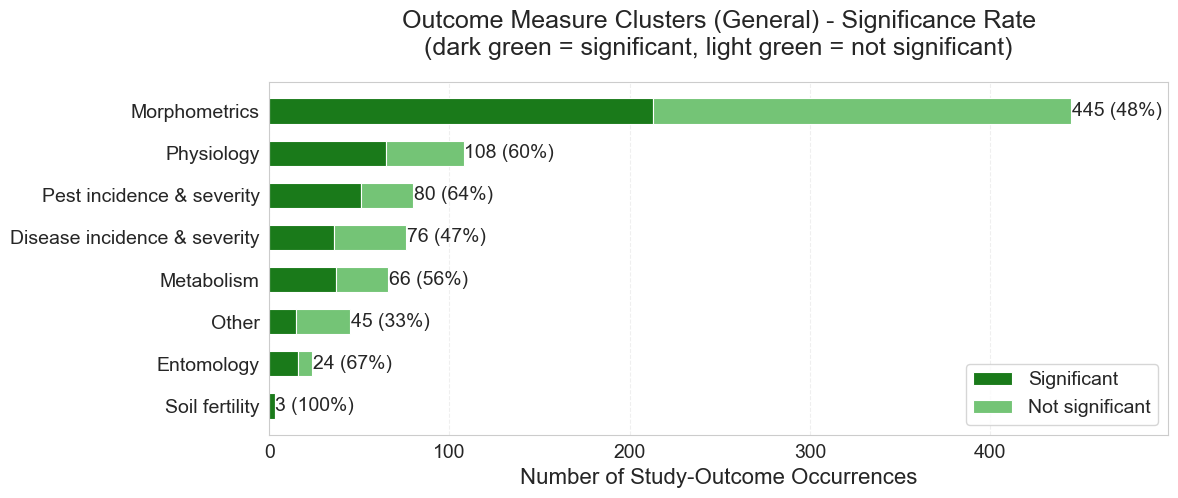

Chart saved: cluster_significance_stacked_general.png


In [364]:
# Stacked bar chart: outcome measures clustered by "Cluster general" (col B of 260505 CSV)
# Mirrors the biological-process plot above, but uses the hand-curated general clusters
# (Morphometrics, Physiology, Metabolism, Disease incidence & severity, Pest incidence & severity, Entomology, Soil fertility, ...).
# Unmatched outcomes fall into "Other".
# Uses shared outcome_item_totals and outcome_item_sig_counts from upstream cell.

from collections import Counter

# Step 1: Map shared item-level counts through general cluster lookup
cluster_total_g = Counter()
cluster_sig_g = Counter()
unmatched_g = Counter()
for item, total_count in outcome_item_totals.items():
    if item in lookup_outcome_general:
        cluster = lookup_outcome_general[item]
    else:
        cluster = 'Other'
        unmatched_g[item] += total_count
    cluster_total_g[cluster] += total_count
    cluster_sig_g[cluster] += outcome_item_sig_counts.get(item, 0)

# Step 2: ordered arrays (ascending so the largest bar lands at top after barh)
labels_g = sorted(cluster_total_g.keys(), key=lambda c: cluster_total_g[c])
totals_g = [cluster_total_g[c] for c in labels_g]
sig_vals_g = [cluster_sig_g[c] for c in labels_g]
not_sig_vals_g = [t - s for t, s in zip(totals_g, sig_vals_g)]

print(f"General clusters found: {len(labels_g)}")
for c, t, s in sorted(zip(labels_g, totals_g, sig_vals_g), key=lambda x: -x[1]):
    pct = s / t * 100 if t > 0 else 0
    print(f"  {c}: {t} total, {s} significant ({pct:.0f}%)")
print(f"\nUnmatched outcome measures grouped into 'Other' ({len(unmatched_g)} unique):")
for item, count in sorted(unmatched_g.items(), key=lambda x: -x[1]):
    print(f"  '{item}': {count} occurrence(s)")

# Step 4: plot
fig_g, ax_g = plt.subplots(figsize=hbar_figsize(len(labels_g)))
y_pos = range(len(labels_g))

ax_g.barh(y_pos, sig_vals_g, color='#1a7a1a', edgecolor='white', linewidth=0.8,
          height=BAR_H, label='Significant')
ax_g.barh(y_pos, not_sig_vals_g, left=sig_vals_g, color='#74c476', edgecolor='white',
          linewidth=0.8, height=BAR_H, label='Not significant')

ax_g.set_yticks(y_pos)
ax_g.set_yticklabels(labels_g, fontsize=TICK_FS)
ax_g.set_xlabel('Number of Study-Outcome Occurrences', fontsize=AXIS_LABEL_FS)
ax_g.set_title(
    'Outcome Measure Clusters (General) - Significance Rate\n(dark green = significant, light green = not significant)',
    fontsize=TITLE_FS, pad=20
)

for i, (total, sig) in enumerate(zip(totals_g, sig_vals_g)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_g.text(total + 0.3, i, f'{total} ({pct:.0f}%)', va='center', fontsize=DATA_LABEL_FS)

max_val = max(totals_g)
ax_g.set_xlim(right=max_val + 0.3 + len(f'{max_val} (100%)') * max_val * 0.012)
ax_g.legend(loc='lower right', fontsize=LEGEND_FS)
ax_g.grid(axis='x', alpha=0.3, linestyle='--')
ax_g.set_axisbelow(True)
ax_g.yaxis.grid(False)

plt.tight_layout()
fig_g.savefig('cluster_significance_stacked_general.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: cluster_significance_stacked_general.png")


### Agronomical Outcome Significance


Unmatched outcomes (no general cluster) grouped into 'Other' (41 unique):
  'photosynthesis rate (adc photosynthesis meter)': 1 occurrence(s)
  'photosynthetic rate': 1 occurrence(s)
  'total flavonoid content (%) - quercetin': 1 occurrence(s)
  'number of split edible roots.': 1 occurrence(s)
  'pest incidence': 1 occurrence(s)
  'pest severity': 1 occurrence(s)
  'seedling quality - (dickson quality index)': 1 occurrence(s)
  'stem diamenter': 1 occurrence(s)
  'total shoot lenght': 1 occurrence(s)
  'peroxidase enzyme activity enzyme activity between shoot and root system between shoot and root system lationship  between shoot and root system': 1 occurrence(s)
  'relationship between shoot and root system': 1 occurrence(s)
  'shoot length': 1 occurrence(s)
  'total soluble sugar': 1 occurrence(s)
  'total biomass': 1 occurrence(s)
  'number of  leaf glands (dark glands)': 1 occurrence(s)
  'plant growth': 1 occurrence(s)
  'n* of insects per plant': 1 occurrence(s)
  'pest severety

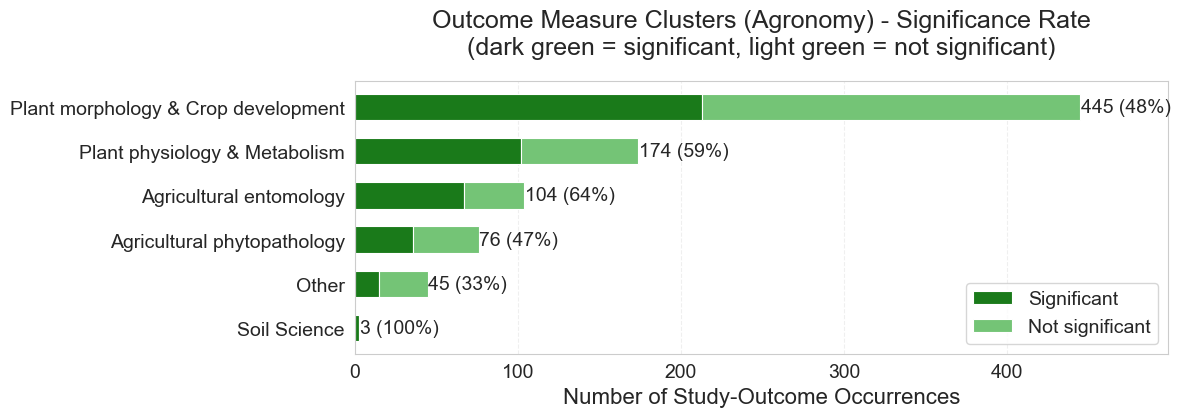

Chart saved: cluster_significance_stacked_agronomy.png


In [365]:
# Stacked bar chart: outcome measures clustered by "Mapping Agronomy cluster" (col D of 260505 CSV)
# Two-step lookup: outcome -> general cluster (col B) -> agronomy cluster (col D).
# The agronomy mapping is a hand-curated rollup of the general clusters into broader agronomy domains
# (e.g. Plant physiology & Metabolism, Agricultural phytopathology, Agricultural entomology, Soil Science).
# Uses shared outcome_item_totals and outcome_item_sig_counts from upstream cell.

from collections import Counter

# Track *why* an item lands in 'Other' for diagnostics:
#   unmatched_outcomes_a -> outcome name not in lookup_outcome_general (col A miss)
#   unmatched_general_a  -> general cluster has no agronomy rollup (col B miss in the C/D table)
unmatched_outcomes_a = Counter()
unmatched_general_a = Counter()

def to_agronomy(item):
    """Two-step lookup: outcome name -> general cluster -> agronomy cluster.
    Records which step failed so we can print the offenders below."""
    g = lookup_outcome_general.get(item)
    if g is None:
        unmatched_outcomes_a[item] += 1
        return 'Other'
    a = lookup_general_agronomy.get(g)
    if a is None:
        unmatched_general_a[g] += 1
        return 'Other'
    return a

# Step 1: Map shared item-level counts through two-step agronomy lookup
cluster_total_a = Counter()
cluster_sig_a = Counter()
for item, total_count in outcome_item_totals.items():
    cluster = to_agronomy(item)
    cluster_total_a[cluster] += total_count
    cluster_sig_a[cluster] += outcome_item_sig_counts.get(item, 0)

if unmatched_outcomes_a:
    print(f"\nUnmatched outcomes (no general cluster) grouped into 'Other' ({len(unmatched_outcomes_a)} unique):")
    for item, count in sorted(unmatched_outcomes_a.items(), key=lambda x: -x[1]):
        print(f"  '{item}': {count} occurrence(s)")
if unmatched_general_a:
    print(f"\nGeneral clusters with no agronomy rollup ({len(unmatched_general_a)} unique):")
    for g, count in sorted(unmatched_general_a.items(), key=lambda x: -x[1]):
        print(f"  '{g}': {count} occurrence(s)")

labels_a = sorted(cluster_total_a.keys(), key=lambda c: cluster_total_a[c])
totals_a = [cluster_total_a[c] for c in labels_a]
sig_vals_a = [cluster_sig_a[c] for c in labels_a]
not_sig_vals_a = [t - s for t, s in zip(totals_a, sig_vals_a)]

print(f"Agronomy clusters found: {len(labels_a)}")
for c, t, s in sorted(zip(labels_a, totals_a, sig_vals_a), key=lambda x: -x[1]):
    pct = s / t * 100 if t > 0 else 0
    print(f"  {c}: {t} total, {s} significant ({pct:.0f}%)")

fig_a, ax_a = plt.subplots(figsize=hbar_figsize(len(labels_a)))
y_pos = range(len(labels_a))

ax_a.barh(y_pos, sig_vals_a, color='#1a7a1a', edgecolor='white', linewidth=0.8,
          height=BAR_H, label='Significant')
ax_a.barh(y_pos, not_sig_vals_a, left=sig_vals_a, color='#74c476', edgecolor='white',
          linewidth=0.8, height=BAR_H, label='Not significant')

ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(labels_a, fontsize=TICK_FS)
ax_a.set_xlabel('Number of Study-Outcome Occurrences', fontsize=AXIS_LABEL_FS)
ax_a.set_title(
    'Outcome Measure Clusters (Agronomy) - Significance Rate\n(dark green = significant, light green = not significant)',
    fontsize=TITLE_FS, pad=20
)

for i, (total, sig) in enumerate(zip(totals_a, sig_vals_a)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_a.text(total + 0.3, i, f'{total} ({pct:.0f}%)', va='center', fontsize=DATA_LABEL_FS)

max_val = max(totals_a)
ax_a.set_xlim(right=max_val + 0.3 + len(f'{max_val} (100%)') * max_val * 0.012)
ax_a.legend(loc='lower right', fontsize=LEGEND_FS)
ax_a.grid(axis='x', alpha=0.3, linestyle='--')
ax_a.set_axisbelow(True)
ax_a.yaxis.grid(False)

plt.tight_layout()
fig_a.savefig('cluster_significance_stacked_agronomy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: cluster_significance_stacked_agronomy.png")


## Crop Significance
This can not be exhaustatively done, as each study can have multiple crops, and we did not record the significances directly connected to the crops

Single-crop studies: 148 out of 160 total rows


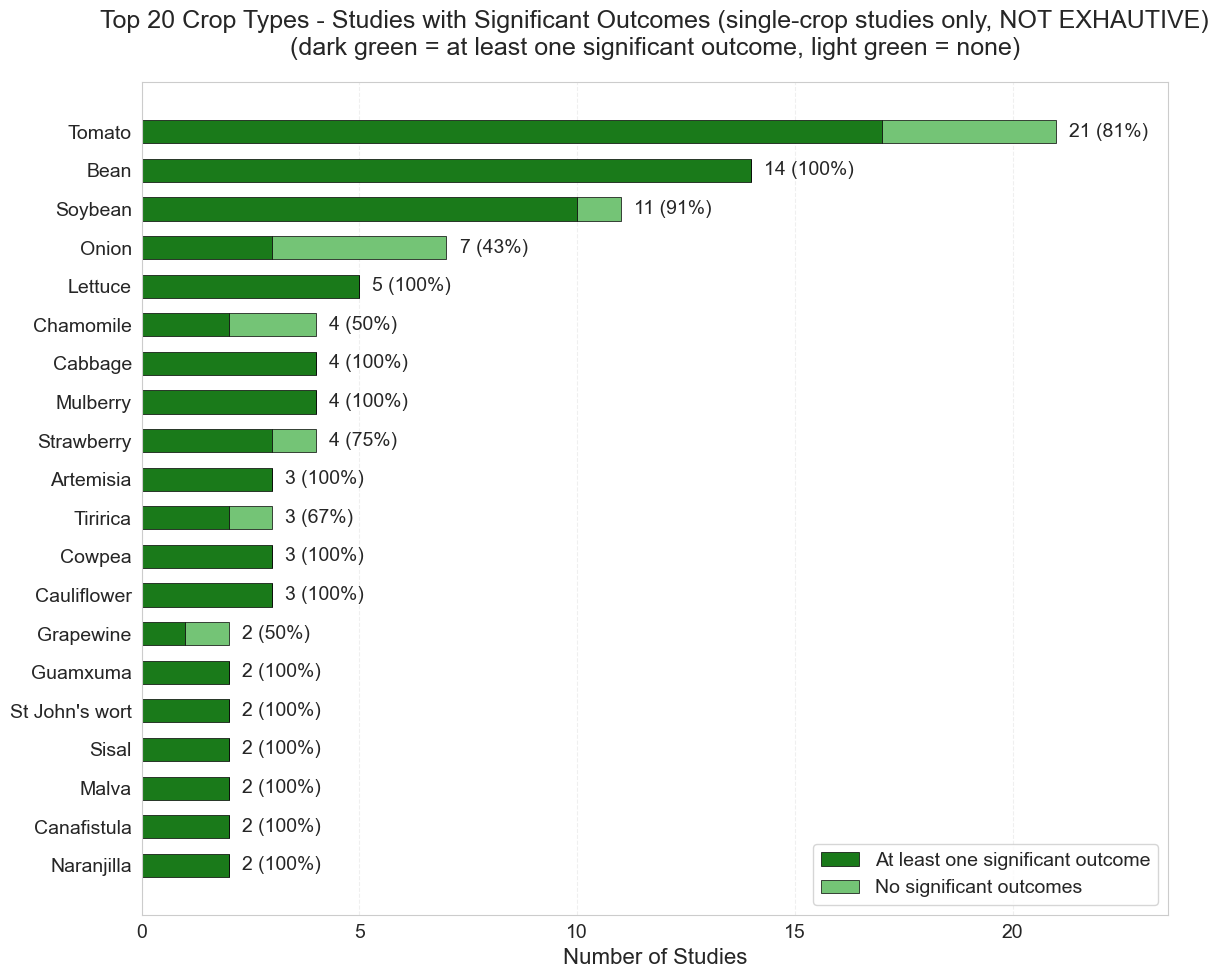

In [366]:
# Stacked bar chart: top 20 crop types with significance overlay
# Single-crop studies only (multi-crop rows excluded - significance not linkable to specific crop)
# Dark green = study had at least one significant outcome
# Light green = study had no significant outcomes

sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Step 1: Filter to single-crop studies only (drop NaN first, then filter multi-crop)
crop_series_st = df['Crop type studied'].dropna().astype(str).str.strip()
single_crop_mask = ~crop_series_st.str.contains(',')
# Use the mask's own index to select from df (aligned to non-NaN crop rows)
df_single_crop = df.loc[single_crop_mask[single_crop_mask].index].copy()

print(f"Single-crop studies: {len(df_single_crop)} out of {len(df)} total rows")

# Step 2: Get top 20 crop types by frequency (among single-crop studies)
crop_counts_st = df_single_crop['Crop type studied'].str.strip().value_counts().head(20)
top20_crop_set = set(crop_counts_st.index)

# Step 3: Helper to check if a study had at least one significant outcome
def has_significant_outcome(sig_text):
    # Skip empty cells — these should be filled after consensus
    if pd.isna(sig_text) or str(sig_text).strip() == '':
        return False
    s = str(sig_text).lower().strip()
    if 'not significant' in s or 'no significance calculated' in s:
        return False
    return True

# Step 4: Count significant studies per crop
sig_counts_crop = {}
for crop in top20_crop_set:
    crop_rows = df_single_crop[df_single_crop['Crop type studied'].str.strip() == crop]
    sig_counts_crop[crop] = int(crop_rows.apply(lambda r: has_significant_outcome(r[sig_col]), axis=1).sum())

# Step 5: Build arrays (reversed so most frequent is at top)
crop_labels = crop_counts_st.index[::-1].tolist()
crop_totals = crop_counts_st.values[::-1].tolist()
crop_sig_vals = [sig_counts_crop[lbl] for lbl in crop_labels]
crop_not_sig_vals = [t - s for t, s in zip(crop_totals, crop_sig_vals)]

# Step 6: Plot stacked horizontal bar chart
fig_crop_st, ax_crop_st = plt.subplots(figsize=hbar_figsize(len(crop_labels)))

y_pos = range(len(crop_labels))

ax_crop_st.barh(y_pos, crop_sig_vals, color='#1a7a1a', edgecolor='black', linewidth=0.5, height=BAR_H, label='At least one significant outcome')
ax_crop_st.barh(y_pos, crop_not_sig_vals, left=crop_sig_vals, color='#74c476', edgecolor='black', linewidth=0.5, height=BAR_H, label='No significant outcomes')

ax_crop_st.set_yticks(y_pos)
ax_crop_st.set_yticklabels(crop_labels, fontsize=TICK_FS)
ax_crop_st.set_xlabel('Number of Studies', fontsize=AXIS_LABEL_FS)
ax_crop_st.set_title(
    'Top 20 Crop Types - Studies with Significant Outcomes (single-crop studies only, NOT EXHAUTIVE)\n(dark green = at least one significant outcome, light green = none)',
    fontsize=TITLE_FS, pad=20
)

# Value labels at end of each bar: total and % with significance
for i, (total, sig) in enumerate(zip(crop_totals, crop_sig_vals)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_crop_st.text(total + 0.3, i, f'{total} ({pct:.0f}%)', va='center', fontsize=DATA_LABEL_FS)

# Extend x-axis to prevent text clipping
max_crop_val = max(crop_totals)
ax_crop_st.set_xlim(right=max_crop_val + 0.3 + len(f'{max_crop_val} (100%)') * max_crop_val * 0.012)

ax_crop_st.legend(loc='lower right', fontsize=LEGEND_FS)

ax_crop_st.grid(axis='x', alpha=0.3, linestyle='--')
ax_crop_st.set_axisbelow(True)
ax_crop_st.yaxis.grid(False)

plt.tight_layout()
fig_crop_st.savefig('crop_type_significance_stacked.png', dpi=300, bbox_inches='tight')
plt.show()


## Country Significance

Studies with valid country data: 160 out of 160 total rows


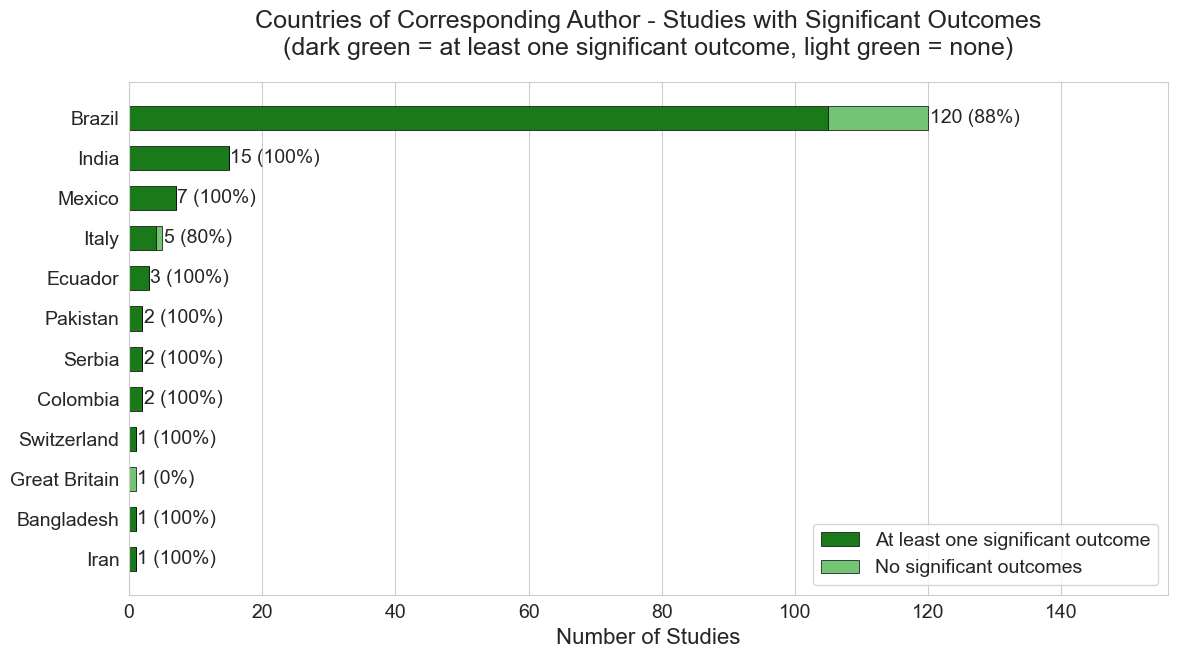

In [367]:
# Stacked bar chart: countries of corresponding author with significance overlay
# Each study has exactly one country, so no multi-value filtering needed.
# Dark green = at least one significant outcome
# Light green = no significant outcomes

sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Step 1: Prepare country series — warn about empty fields, drop NaN, rename N/A
# TODO-RAWDATA: 'Parkistan' typo and 'Great Britain ' trailing space will be fixed in final data
for idx, row in df.iterrows():
    if pd.isna(row['Country of corresponding author']) or str(row['Country of corresponding author']).strip() == '':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty country field")
country_series_sig = (
    df['Country of corresponding author']
    .dropna()
    .astype(str)
    .str.strip()
    .replace({'N/A': 'Unknown', 'Parkistan': 'Pakistan'})
)
df_country_sig = df.loc[country_series_sig.index].copy()
df_country_sig['_country'] = country_series_sig

print(f"Studies with valid country data: {len(df_country_sig)} out of {len(df)} total rows")

# Step 2: Get all countries by frequency
country_counts_sig = df_country_sig['_country'].value_counts()

# Step 3: Helper to check if a study had at least one significant outcome
def has_significant_outcome_country(sig_text):
    # Skip empty cells — these should be filled after consensus
    if pd.isna(sig_text) or str(sig_text).strip() == '':
        return False
    s = str(sig_text).lower().strip()
    if 'not significant' in s or 'no significance calculated' in s:
        return False
    return True

# Step 4: Count significant studies per country
sig_counts_country = {}
for country in country_counts_sig.index:
    rows = df_country_sig[df_country_sig['_country'] == country]
    sig_counts_country[country] = int(rows.apply(lambda r: has_significant_outcome_country(r[sig_col]), axis=1).sum())

# Step 5: Build arrays (reversed so most frequent is at top)
country_labels_sig = country_counts_sig.index[::-1].tolist()
country_totals_sig = country_counts_sig.values[::-1].tolist()
country_sig_vals = [sig_counts_country[lbl] for lbl in country_labels_sig]
country_not_sig_vals = [t - s for t, s in zip(country_totals_sig, country_sig_vals)]

# Step 6: Plot stacked horizontal bar chart
n_countries = len(country_labels_sig)
fig_country_sig, ax_country_sig = plt.subplots(figsize=hbar_figsize(n_countries))

y_pos_sig = range(n_countries)

ax_country_sig.barh(y_pos_sig, country_sig_vals, color='#1a7a1a', edgecolor='black', linewidth=0.5, height=BAR_H, label='At least one significant outcome')
ax_country_sig.barh(y_pos_sig, country_not_sig_vals, left=country_sig_vals, color='#74c476', edgecolor='black', linewidth=0.5, height=BAR_H, label='No significant outcomes')

ax_country_sig.set_yticks(y_pos_sig)
ax_country_sig.set_yticklabels(country_labels_sig, fontsize=TICK_FS)
ax_country_sig.set_xlabel('Number of Studies', fontsize=AXIS_LABEL_FS)
ax_country_sig.set_title(
    'Countries of Corresponding Author - Studies with Significant Outcomes\n(dark green = at least one significant outcome, light green = none)',
    fontsize=TITLE_FS, pad=20
)

# Value labels at end of each bar: total count and % with significance
for i, (total, sig) in enumerate(zip(country_totals_sig, country_sig_vals)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_country_sig.text(total + 0.2, i, f'{total} ({pct:.0f}%)', va='center', fontsize=DATA_LABEL_FS)

# Extend x-axis to prevent text clipping
max_country_val = max(country_totals_sig)
ax_country_sig.set_xlim(0, max_country_val * 1.3)

ax_country_sig.legend(loc='lower right', fontsize=LEGEND_FS)
ax_country_sig.yaxis.grid(False)

plt.tight_layout()
plt.savefig('country_significance_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Blinding Status vs Significance

  RAWDATA CLEANUP NEEDED: Covidence #2001 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #2036 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #2230 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #7204 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #10492 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #10584 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #10593 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #4230 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #4230 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #4734 has empty or N/A blinding field
  RAWDATA CLEANUP NEEDED: Covidence #4734 has empty or N/A blinding field
Studies with valid blinding data: 149 out of 160 total rows


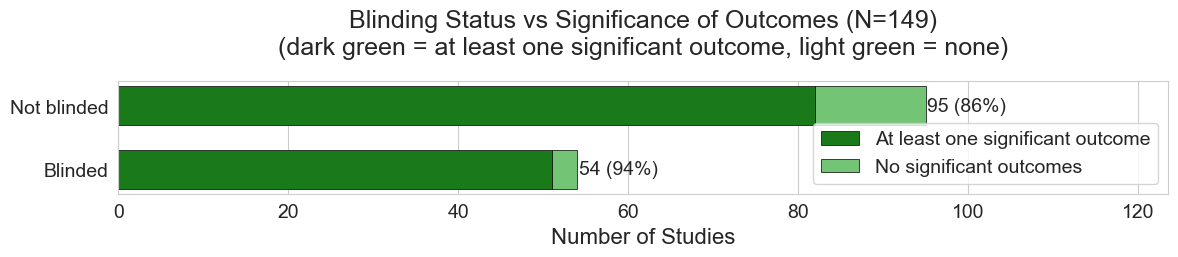

In [368]:
# Stacked bar chart: blinding status vs significant outcomes
# Groups 'Single blinded' + 'Double blinded' into one 'Blinded' bar,
# keeps 'Not blinded' as a separate bar.
# Drops NaN and N/A rows with RAWDATA warnings.
# Dark green = at least one significant outcome
# Light green = no significant outcomes

sig_col = 'Significant results for specific outcome measures (comparing to the control)'

# Step 1: Warn about empty/NaN blinding fields, then drop them
for idx, row in df.iterrows():
    val = row['Blinded']
    if pd.isna(val) or str(val).strip() == '' or str(val).strip() == 'N/A':
        print(f"  RAWDATA CLEANUP NEEDED: Covidence #{row['Covidence #']} has empty or N/A blinding field")

# Step 2: Clean and filter — keep only real blinding categories
blinded_series_sig = (
    df['Blinded']
    .dropna()
    .astype(str)
    .str.strip()
)
# Drop N/A entries
blinded_series_sig = blinded_series_sig[blinded_series_sig != 'N/A']

# Step 3: Group into two categories
blinded_grouped = blinded_series_sig.map({
    'Single blinded': 'Blinded',
    'Double blinded': 'Blinded',
    'Not blinded': 'Not blinded',
})
# Warn about any unmapped values (safety net for future data changes)
unmapped = blinded_grouped[blinded_grouped.isna()]
if len(unmapped) > 0:
    print(f"  WARNING: {len(unmapped)} rows have unexpected Blinded values: {blinded_series_sig.loc[unmapped.index].unique()}")
blinded_grouped = blinded_grouped.dropna()

df_blinded_sig = df.loc[blinded_grouped.index].copy()
df_blinded_sig['_blinded_group'] = blinded_grouped

print(f"Studies with valid blinding data: {len(df_blinded_sig)} out of {len(df)} total rows")

# Step 4: Count per group
blinded_counts_sig = df_blinded_sig['_blinded_group'].value_counts()

# Step 5: Count significant studies per group
sig_counts_blinded = {}
for group in blinded_counts_sig.index:
    rows = df_blinded_sig[df_blinded_sig['_blinded_group'] == group]
    sig_counts_blinded[group] = int(rows.apply(lambda r: has_significant_outcome(r[sig_col]), axis=1).sum())

# Step 6: Build arrays (reversed so most frequent is at top)
blinded_labels_sig = blinded_counts_sig.index[::-1].tolist()
blinded_totals_sig = blinded_counts_sig.values[::-1].tolist()
blinded_sig_vals = [sig_counts_blinded[lbl] for lbl in blinded_labels_sig]
blinded_not_sig_vals = [t - s for t, s in zip(blinded_totals_sig, blinded_sig_vals)]

# Step 7: Plot stacked horizontal bar chart
n_blinded = len(blinded_labels_sig)
fig_blinded_sig, ax_blinded_sig = plt.subplots(figsize=hbar_figsize(n_blinded))

y_pos_blinded = range(n_blinded)

ax_blinded_sig.barh(y_pos_blinded, blinded_sig_vals, color='#1a7a1a', edgecolor='black', linewidth=0.5, height=BAR_H, label='At least one significant outcome')
ax_blinded_sig.barh(y_pos_blinded, blinded_not_sig_vals, left=blinded_sig_vals, color='#74c476', edgecolor='black', linewidth=0.5, height=BAR_H, label='No significant outcomes')

ax_blinded_sig.set_yticks(y_pos_blinded)
ax_blinded_sig.set_yticklabels(blinded_labels_sig, fontsize=TICK_FS)
ax_blinded_sig.set_xlabel('Number of Studies', fontsize=AXIS_LABEL_FS)
ax_blinded_sig.set_title(
    f'Blinding Status vs Significance of Outcomes (N={len(df_blinded_sig)})\n'
    f'(dark green = at least one significant outcome, light green = none)',
    fontsize=TITLE_FS, pad=20
)

# Value labels at end of each bar: total count and % with significance
for i, (total, sig) in enumerate(zip(blinded_totals_sig, blinded_sig_vals)):
    pct = (sig / total * 100) if total > 0 else 0
    ax_blinded_sig.text(total + 0.2, i, f'{total} ({pct:.0f}%)', va='center', fontsize=DATA_LABEL_FS)

# Extend x-axis to prevent text clipping
max_blinded_val = max(blinded_totals_sig)
ax_blinded_sig.set_xlim(0, max_blinded_val * 1.3)

ax_blinded_sig.legend(loc='lower right', fontsize=LEGEND_FS)
ax_blinded_sig.yaxis.grid(False)

plt.tight_layout()
plt.savefig('blinded_significance_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()


## Country Significance Validation

In [369]:
# --- VALIDATION: Country Significance Bar Chart summary stats ---
# Shows per-country counts (significant, not significant, total) and percentages
# Uses: df (not df_all), df_country_sig, country_counts_sig, sig_counts_country

print("=" * 70)
print("BAR CHART DATA VALIDATION")
print(f"Dataframe used: df  (total rows: {len(df)})")
print(f"After filtering blanks/N/A: {len(df_country_sig)} studies")
print("=" * 70)

# Compare with pie chart source
print(f"\nNOTE: Pie chart uses df_all ({len(df_all)} rows), "
      f"bar chart uses df ({len(df)} rows)")
if len(df_all) != len(df):
    print(f"  -> DIFFERENCE of {abs(len(df_all) - len(df))} rows!")
else:
    print("  -> Same row count.")

# Per-country breakdown: total, significant, not significant
bar_total_all = int(country_counts_sig.sum())
print(f"\nPer-country breakdown ({bar_total_all} studies total):")
print(f"{'Country':<35} {'Total':>6} {'Sig':>6} {'NotSig':>6} {'Pct':>7} {'SigPct':>7}")
print("-" * 75)

# Show in descending frequency order (not reversed)
for country, total in country_counts_sig.items():
    sig = sig_counts_country[country]
    not_sig = total - sig
    pct = total / bar_total_all * 100
    sig_pct = sig / total * 100 if total > 0 else 0
    print(f"{country:<35} {total:>6} {sig:>6} {not_sig:>6} {pct:>6.1f}% {sig_pct:>6.1f}%")

print(f"\n{'TOTAL':<35} {bar_total_all:>6} "
      f"{sum(sig_counts_country.values()):>6} "
      f"{bar_total_all - sum(sig_counts_country.values()):>6}")

# Cross-check: does bar chart have "Parkistan" vs "Pakistan" issue?
if 'Parkistan' in country_counts_sig.index:
    print("\nWARNING: 'Parkistan' typo present in bar chart data (not corrected)!")
else:
    print("\nNo 'Parkistan' typo found in bar chart data.")

BAR CHART DATA VALIDATION
Dataframe used: df  (total rows: 160)
After filtering blanks/N/A: 160 studies

NOTE: Pie chart uses df_all (193 rows), bar chart uses df (160 rows)
  -> DIFFERENCE of 33 rows!

Per-country breakdown (160 studies total):
Country                              Total    Sig NotSig     Pct  SigPct
---------------------------------------------------------------------------
Brazil                                 120    105     15   75.0%   87.5%
India                                   15     15      0    9.4%  100.0%
Mexico                                   7      7      0    4.4%  100.0%
Italy                                    5      4      1    3.1%   80.0%
Ecuador                                  3      3      0    1.9%  100.0%
Pakistan                                 2      2      0    1.2%  100.0%
Serbia                                   2      2      0    1.2%  100.0%
Colombia                                 2      2      0    1.2%  100.0%
Switzerland          

# Summary Tables (for export to Word)

Tables are built from the cleaned dataset and collected in `report_tables`.
The final cell writes every collected table into a single `.docx` file.


In [370]:
#===== SECTION: Summary tables — collect for single .docx export ============

# Master accumulator: each entry is (title, DataFrame, optional footer). The export cell at the
# very end writes every table collected here into ONE Word document.
# Re-running this cell resets the list so tables are not duplicated across runs.
report_tables = []


def fmt_count_pct(count, denom):
    # Format a count as "N (P%)" with P = count / denom * 100. Blank/empty
    # padding cells stay blank. `denom` is the relevant study base for that table.
    if count == "" or count is None or pd.isna(count):
        return ""
    return f"{int(count)} ({int(count) / denom * 100:.1f}%)"

## Country: Papers and studies

In [371]:
# --- Table 1: Papers and studies per country --------------------------------
# Definitions:
#   Number of papers  = count of unique "Covidence #"  (one paper = one Covidence #)
#   Number of studies = row count  (a single paper may contribute >1 study; the
#                       extra studies are flagged in "Study # within same publication")
#
# Country handling is kept IDENTICAL to every other country-based cell: we reuse
# `country_series` exactly as built for the country pie chart (df_all, dropna +
# strip + {'N/A': 'Unknown', 'Parkistan': 'Pakistan'}). Studies with a missing
# country were already dropped and RAWDATA-warned in that cell, so the per-country
# rows and the Total below exclude them (the Total reconciles to the rows shown).
#
# Rows with messy extraction flags (e.g. "Duplicate", "double extracted",
# "3 - extra extraction?") are STILL counted as studies, but each one triggers a
# RAWDATA warning so the source file can be cleaned later.

study_col = df_all["Study # within same publication"]


def is_clean_study_entry(value):
    # A blank means a single study (fine). A plain integer is a genuine
    # multi-study marker. Anything else (question marks, "Duplicate",
    # "double extracted") is an extraction flag we want to surface.
    if pd.isna(value):
        return True
    return str(value).strip().isdigit()


flagged_rows = df_all[~study_col.apply(is_clean_study_entry)]
for _, flagged in flagged_rows.iterrows():
    print(
        f"  RAWDATA CLEANUP NEEDED: Covidence #{flagged['Covidence #']} has "
        f"ambiguous study flag '{flagged['Study # within same publication']}' "
        f"(still counted as a study)"
    )

# Attach the cleaned country labels back onto their df_all rows, then aggregate.
country_papers_studies = df_all.loc[country_series.index].copy()
country_papers_studies["_country"] = country_series

country_table = (
    country_papers_studies.groupby("_country")
    .agg(
        **{
            "Number of papers": ("Covidence #", "nunique"),
            "Number of studies": ("Covidence #", "size"),
        }
    )
    .sort_values("Number of studies", ascending=False)
    .reset_index()
    .rename(columns={"_country": "Country"})
)

# Total reconciles to the rows shown (missing-country studies excluded above).
total_row = pd.DataFrame(
    [
        {
            "Country": "Total",
            "Number of papers": country_papers_studies["Covidence #"].nunique(),
            "Number of studies": len(country_papers_studies),
        }
    ]
)
country_table = pd.concat([country_table, total_row], ignore_index=True)

# Express "Number of papers" as "N (% of all papers with a country)", except
# the Total row (kept as a plain count). % basis = the total paper count.
country_total_papers = country_papers_studies["Covidence #"].nunique()
country_table["Number of papers"] = [
    str(p) if c == "Total" else fmt_count_pct(p, country_total_papers)
    for c, p in zip(country_table["Country"], country_table["Number of papers"])
]
country_table = country_table.rename(
    columns={"Number of papers": "Number of papers (%)"}
)

country_title = "Papers and studies per country"
country_footer = (
    f"% = share of the {country_total_papers} papers with a recorded country "
    "(one country per paper, so percentages sum to ~100%)."
)
report_tables.append((country_title, country_table, country_footer))

# Simple in-notebook display: just hide the index. No heavy styling.
country_table.style.hide(axis="index").set_caption(country_title)


  RAWDATA CLEANUP NEEDED: Covidence #5108 has ambiguous study flag '1 - extra extraction? ' (still counted as a study)
  RAWDATA CLEANUP NEEDED: Covidence #6190 has ambiguous study flag 'Duplicate' (still counted as a study)
  RAWDATA CLEANUP NEEDED: Covidence #10584 has ambiguous study flag 'double extraction?' (still counted as a study)
  RAWDATA CLEANUP NEEDED: Covidence #5103 has ambiguous study flag '3 - extra extraction?' (still counted as a study)
  RAWDATA CLEANUP NEEDED: Covidence #10778 has ambiguous study flag 'double extracted' (still counted as a study)
  RAWDATA CLEANUP NEEDED: Covidence #10666 has ambiguous study flag '3 - double extraction?' (still counted as a study)


Country,Number of papers (%),Number of studies
Brazil,108 (67.5%),129
India,29 (18.1%),30
Mexico,7 (4.4%),7
Pakistan,6 (3.8%),6
Italy,2 (1.2%),5
Ecuador,1 (0.6%),3
Colombia,1 (0.6%),2
Great Britain,2 (1.2%),2
Serbia,1 (0.6%),2
Bangladesh,1 (0.6%),1


## MIS filter: articles and studies


In [372]:
# --- Table: Articles and studies before vs after the MIS >= 5 filter --------
# "Number of papers" = unique "Covidence #" (one article = one publication).
# "Number of studies"  = row count (a publication may contribute >1 study).
# Before = df_all (full extracted set); After = df (MIS >= 5 subset used for the
# downstream analyses). Counts include every row (duplicate-flagged rows too),
# consistent with the per-country table.

mis_filter_table = pd.DataFrame(
    [
        {
            "Set": "Before MIS ≥ 5 (all extracted)",
            "Number of papers": df_all["Covidence #"].nunique(),
            "Number of studies": len(df_all),
        },
        {
            "Set": "After MIS ≥ 5",
            "Number of papers": df["Covidence #"].nunique(),
            "Number of studies": len(df),
        },
    ]
)

# Add the retention % to "Number of papers" — only the After-MIS row carries it
# (the only meaningful % here): share of the pre-filter papers that were kept.
papers_before = int(mis_filter_table.loc[0, "Number of papers"])
mis_filter_table["Number of papers"] = [
    fmt_count_pct(p, papers_before) if str(s).startswith("After") else str(p)
    for s, p in zip(mis_filter_table["Set"], mis_filter_table["Number of papers"])
]
mis_filter_table = mis_filter_table.rename(
    columns={"Number of papers": "Number of papers (%)"}
)

mis_title = "Articles and studies before/after MIS ≥ 5 filter"
mis_footer = (
    f"% = share of the {papers_before} pre-filter papers retained after the "
    "MIS ≥ 5 filter."
)
report_tables.append((mis_title, mis_filter_table, mis_footer))

# Simple in-notebook display: just hide the index.
mis_filter_table.style.hide(axis="index").set_caption(mis_title)


Set,Number of papers (%),Number of studies
Before MIS ≥ 5 (all extracted),163,193
After MIS ≥ 5,130 (79.8%),160


## Homeopathic interventions


In [373]:
# --- Table 2: Homeopathic interventions (relabelled & summarised) -----------
# Same data as the intervention lollipop chart: we REUSE that cell's frequency
# table (`homeopathic_intervention_freq_hom_interven`) and exclude the dilution
# modifier exactly as the chart does. Raw route labels are then relabelled, and
# some are merged (e.g. "Addition to growth substrate or spore solution" folds
# into "Pre-treatment of soil/substrate"). "Seed treatment" is kept as its own
# row.
#
# Per-row value = number of studies using that intervention (each study lists a
# given route at most once). The Total is total ENTRIES, which exceeds the study
# count because a study may use several interventions.

intervention_label_map = {
    "Pre-treatment of seeds": "Pre-treatment of seeds",
    "Pre-treatment of soil/growth medium": "Pre-treatment of soil/substrate",
    "Treatment of plant during growth (eg. spray on leaves)": "Treatment of plant during growth",
    "Treatment of soil during growth (together with/instead of watering)": "Treatment of soil/substrate during growth",
    "Treatment of soil during growth (seperate from watering)": "Treatment of soil/substrate during growth",
    "Treatment post-harvest (eg. fruits)": "Treatment post-harvest",
    "N/A": "Unknown",
    "Addition to growth substrate or spore solution": "Pre-treatment of soil/substrate",
}

# Reuse the chart's frequencies, minus the dilution modifier (kept in that
# table, but excluded from the chart and here too).
route_freq = homeopathic_intervention_freq_hom_interven.drop(
    index=dilution_label, errors="ignore"
)["Frequency"]

# Relabel, then merge any labels that now collide (sum their counts).
intervention_summary = (
    route_freq.rename(index=lambda t: intervention_label_map.get(t, t))
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)

intervention_table = intervention_summary.rename_axis("Intervention").reset_index(
    name="Number of studies"
)

# Total ENTRIES (not studies — multiple interventions per study possible).
total_entries = int(intervention_summary.sum())
total_row = pd.DataFrame(
    [{"Intervention": "Total entries", "Number of studies": total_entries}]
)
intervention_table = pd.concat([intervention_table, total_row], ignore_index=True)

# How many studies the data comes from (non-empty intervention field).
n_intervention_studies = int(len(homeopathic_series_hom_interven))
intervention_title = (
    f"Homeopathic interventions (from {n_intervention_studies} studies; "
    "multiple interventions per study possible)"
)

# Express "Number of studies" as "N (% of studies)", except the Total row.
intervention_table["Number of studies"] = [
    str(n) if lab == "Total entries" else fmt_count_pct(n, n_intervention_studies)
    for lab, n in zip(
        intervention_table["Intervention"], intervention_table["Number of studies"]
    )
]
intervention_table = intervention_table.rename(
    columns={"Number of studies": "Number of studies (%)"}
)

intervention_footer = (
    f"% = proportion of the {n_intervention_studies} studies with a recorded "
    "intervention; studies may list several, so percentages sum to >100%."
)
report_tables.append((intervention_title, intervention_table, intervention_footer))

# Simple in-notebook display: just hide the index.
intervention_table.style.hide(axis="index").set_caption(intervention_title)


Intervention,Number of studies (%)
Treatment of plant during growth,85 (53.5%)
Pre-treatment of soil/substrate,31 (19.5%)
Pre-treatment of seeds,29 (18.2%)
Treatment of soil/substrate during growth,27 (17.0%)
Seed treatment,1 (0.6%)
Total entries,173


## Interventions vs parallel interventions


In [374]:
# --- Table 3: Homeopathic interventions vs parallel interventions -----------
# Two independent breakdowns placed side by side in one table:
#   Left  = homeopathic intervention routes  (reuses `intervention_summary` from
#           the table above; from `n_intervention_studies` studies)
#   Right = parallel interventions, grouped  (reuses `grouped_counts` from the
#           parallel-interventions pie cell; kept exactly as the pie shows them,
#           including the "None"/"N/A"/one-off stress edge categories)
# The two sides have different row counts and different denominators, so the
# shorter side is padded with blanks and each side keeps its own Total entries
# in the bottom row. Per-cell value = number of studies listing that entry
# (multiple per study possible), so a side's Total exceeds its study count.
#
# NOTE: the second count column is named with a trailing space so the column
# labels are technically unique (pandas Styler requires it); both render as
# "Number of studies (%)".

# How many studies each side draws from (non-empty field).
n_parallel_studies = int((parallel_series != "").sum())

left_idx = list(intervention_summary.index)
left_val = [fmt_count_pct(int(v), n_intervention_studies) for v in intervention_summary.values]
right_idx = list(grouped_counts.index)
right_val = [fmt_count_pct(int(v), n_parallel_studies) for v in grouped_counts.values]

# Pad the shorter side with blanks so both align row-for-row.
n_rows = max(len(left_idx), len(right_idx))
left_idx += [""] * (n_rows - len(left_idx))
left_val += [""] * (n_rows - len(left_val))
right_idx += [""] * (n_rows - len(right_idx))
right_val += [""] * (n_rows - len(right_val))

# Bottom row: each side's total entries.
left_idx.append("Total entries")
left_val.append(str(int(intervention_summary.sum())))
right_idx.append("Total entries")
right_val.append(str(int(grouped_counts.sum())))

combined_interventions_table = pd.DataFrame(
    {
        "Intervention": left_idx,
        "Number of studies (%)": left_val,
        "Parallel Interventions": right_idx,
        "Number of studies (%) ": right_val,  # trailing space -> unique but reads the same
    }
)

combined_interventions_title = (
    f"Homeopathic interventions vs parallel interventions "
    f"(homeopathic from {n_intervention_studies} studies, "
    f"parallel from {n_parallel_studies} studies; multiple per study possible)"
)

combined_footer = (
    f"% = proportion of the studies each column draws from "
    f"({n_intervention_studies} homeopathic, {n_parallel_studies} parallel); "
    "studies may list several entries, so percentages sum to >100%."
)
report_tables.append((combined_interventions_title, combined_interventions_table, combined_footer))

# Simple in-notebook display: just hide the index.
combined_interventions_table.style.hide(axis="index").set_caption(combined_interventions_title)


Intervention,Number of studies (%),Parallel Interventions,Number of studies (%)
Treatment of plant during growth,85 (53.5%),"Biological (inoculation, insects)",35 (38.0%)
Pre-treatment of soil/substrate,31 (19.5%),"Organic (manure, organic fertilizers)",22 (23.9%)
Pre-treatment of seeds,29 (18.2%),"Chemical (fertilizers, pesticides)",21 (22.8%)
Treatment of soil/substrate during growth,27 (17.0%),Stress treatment,21 (22.8%)
Seed treatment,1 (0.6%),None,4 (4.3%)
,,Salinity levels,1 (1.1%)
,,Environment stress - toxicity of Al,1 (1.1%)
,,N/A,1 (1.1%)
Total entries,173,Total entries,106


## Remedies (all, ungrouped)


In [375]:
# --- Table 4: All remedies (ungrouped) with count and prevalence ------------
# Reuses `remedy_counts_remedies` from the remedies bar-chart cell — the raw,
# UNGROUPED value counts (every remedy listed individually; no "Single studies"
# bucket). The count is shown with its prevalence as "N (P%)", where P = % of
# studies that used the remedy (multiple remedies per study possible, so values
# sum to >100%). `remedy_series_remedies` (also from that cell) gives the study
# denominator.

n_remedy_studies = int((remedy_series_remedies != "").sum())

remedies_table = (
    remedy_counts_remedies.rename_axis("Remedy")
    .reset_index(name="Number of studies")
    .sort_values("Number of studies", ascending=False, ignore_index=True)
)

# Total ENTRIES (captured before the count column is reformatted to strings).
remedies_total_entries = int(remedy_counts_remedies.sum())

# Combine count + prevalence into one "N (P%)" column, like the other tables.
remedies_table["Number of studies"] = [
    fmt_count_pct(n, n_remedy_studies) for n in remedies_table["Number of studies"]
]
remedies_table = remedies_table.rename(
    columns={"Number of studies": "Number of studies (%)"}
)

# Summary rows (plain counts — no single prevalence applies):
#   Total entries         = sum of all remedy mentions across studies
#   Total unique remedies = number of distinct remedy labels
remedies_n_unique = int(remedy_counts_remedies.size)
remedies_total_rows = pd.DataFrame(
    [
        {"Remedy": "Total entries", "Number of studies (%)": str(remedies_total_entries)},
        {"Remedy": "Total unique remedies", "Number of studies (%)": str(remedies_n_unique)},
    ]
)
remedies_table = pd.concat([remedies_table, remedies_total_rows], ignore_index=True)

remedies_title = (
    f"Remedies (all, ungrouped; from {n_remedy_studies} studies; "
    "multiple remedies per study possible)"
)
remedies_footer = (
    f"% = proportion of the {n_remedy_studies} studies with a recorded remedy "
    "that used each remedy; studies may list several, so percentages sum to >100%."
)
report_tables.append((remedies_title, remedies_table, remedies_footer))

# Simple in-notebook display: just hide the index.
remedies_table.style.hide(axis="index").set_caption(remedies_title)


Remedy,Number of studies (%)
Sulphur,31 (19.4%)
Silicea terra,26 (16.2%)
Phosphorus,26 (16.2%)
Arnica Montana,23 (14.4%)
Natrum Muriaticum,19 (11.9%)
Calcarea carbonica,16 (10.0%)
Carbo vegetabilis,16 (10.0%)
Arsenicum album,15 (9.4%)
Staphysagria,12 (7.5%)
Nux vomica,10 (6.2%)


## Production of potency


In [376]:
# --- Table 5: Production of potency — single methods (with %) ----------------
# Reuses `production_single_table` from the production section. The % is shown
# where it is informative: on each method's row total (Total column) and on the
# overall without/with split (the Total row); the Without/With data cells and
# the grand total-total cell stay as plain counts. % is out of the studies
# classified there (`grand_total`). The actual combinations behind the
# "Combinations" row are listed in the console breakdown in the production section.

production_pct_table = production_single_table.copy()
production_denom = grand_total
methods = production_pct_table["Production method"]

# Total column: "N (%)" on each method/combination row, plain count on Total row.
production_pct_table["Total"] = [
    str(v) if m == "Total" else fmt_count_pct(v, production_denom)
    for m, v in zip(methods, production_pct_table["Total"])
]

# Without/With columns: plain counts, except the Total row, which shows the
# overall split as "N (%)".
for col in ["Without further potentization", "With further potentization"]:
    production_pct_table[col] = [
        fmt_count_pct(v, production_denom) if m == "Total" else str(v)
        for m, v in zip(methods, production_pct_table[col])
    ]

production_pct_title = (
    f"Production of potency — single methods ({production_denom} studies; "
    "combinations grouped)"
)
production_pct_footer = (
    f"% = share of the {production_denom} studies classified by production "
    "method, shown on each method's total (Total column) and on the overall "
    "without/with split (Total row); the grand total is a plain count. "
    "'Combinations' = studies using more than one method; the actual combinations "
    "are listed in the console breakdown in the production section."
)
report_tables.append((production_pct_title, production_pct_table, production_pct_footer))

# Simple in-notebook display: just hide the index.
production_pct_table.style.hide(axis="index").set_caption(production_pct_title)


Production method,Without further potentization,With further potentization,Total
In-house production of mother tincture,17,33,50 (31.6%)
Brand-not-reported MT,0,5,5 (3.2%)
Branded MT,2,3,5 (3.2%)
Brand-not-reported potency,21,34,55 (34.8%)
Branded potency,16,11,27 (17.1%)
Use of potency from earlier experiment,0,0,0 (0.0%)
N/A,0,0,0 (0.0%)
Combinations,4,12,16 (10.1%)
Total,60 (38.0%),98 (62.0%),158


## Export tables

In [377]:
#===== SECTION: Export all summary tables to one Word document ==============

# Requires python-docx:  pip install python-docx
# Writes every (title, DataFrame[, footer]) in report_tables into a SINGLE .docx,
# each table preceded by its title and optionally followed by a footnote. The
# pandas Styler above is for notebook display
# only; the Word tables use plain cell values with a built-in grid style.

from docx import Document
from docx.shared import Pt


def set_cell_bold(cell, bold):
    # Force a cell's text bold on/off explicitly. The "Light Grid Accent 1"
    # table style auto-bolds the first column, so we override per cell to get
    # exactly: header row bold, body plain, and only the Total row fully bold.
    for paragraph in cell.paragraphs:
        for run in paragraph.runs:
            run.font.bold = bold


def export_tables_to_docx(tables, output_path):
    doc = Document()
    doc.add_heading("AgroHomeo Review — Summary Tables", level=0)

    for entry in tables:
        title, table_df = entry[0], entry[1]
        footer = entry[2] if len(entry) > 2 else None
        doc.add_heading(title, level=1)

        # One header row, then one row per data row.
        word_table = doc.add_table(rows=1, cols=len(table_df.columns))
        word_table.style = "Light Grid Accent 1"

        # Header row stays bold.
        header_cells = word_table.rows[0].cells
        for col_idx, col_name in enumerate(table_df.columns):
            header_cells[col_idx].text = str(col_name)
            set_cell_bold(header_cells[col_idx], True)

        # Data rows: blanks for NaN, otherwise the plain value. Body cells are
        # NOT bold (overriding the style's first-column bolding); only a row
        # whose first cell is "Total" is fully bold (label and numbers).
        for _, data_row in table_df.iterrows():
            is_total = str(data_row.iloc[0]).strip().startswith("Total")
            cells = word_table.add_row().cells
            for col_idx, value in enumerate(data_row):
                cells[col_idx].text = "" if pd.isna(value) else str(value)
                set_cell_bold(cells[col_idx], is_total)

        # Optional explanatory footer under the table (e.g. how the % is defined).
        if footer:
            footer_paragraph = doc.add_paragraph()
            footer_run = footer_paragraph.add_run(footer)
            footer_run.font.italic = True
            footer_run.font.size = Pt(8)

        doc.add_paragraph()  # spacing between tables

    doc.save(output_path)
    print(f"Wrote {len(tables)} table(s) to {output_path}")


export_tables_to_docx(report_tables, "agrohom_summary_tables.docx")


Wrote 6 table(s) to agrohom_summary_tables.docx
